In [1]:
# ===================================================================
# THESIS: TabNet Predictive Performance & Interpretability Validation
# PAPER: TabNet-LSTM Ensemble with Elastic Net Stacking for IHSG
# VERSION: 6.0 - Compact & Focused (1-Day Horizon Only)
# ===================================================================

import warnings
warnings.filterwarnings('ignore')

import os, time, random, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from typing import Tuple, Dict, Optional
import joblib, json

import yfinance as yf
from fredapi import Fred
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge, ElasticNet

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller
from scipy import stats
from scipy.stats import wilcoxon, ttest_rel, spearmanr

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import Adam

from pytorch_tabnet.tab_model import TabNetRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.INFO)


# ===================================================================
# GLOBAL CONFIG
# ===================================================================

class Config:
    SEED = 42
    NUM_CORES = os.cpu_count() or 1
    NUM_THREADS = max(1, NUM_CORES // 2)
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    DTYPE = torch.float32
    
    START_DATE = "2010-01-01"
    FRED_API_KEY = 'eceded1789eb5832d183da55288beb80'
    TRAIN_SPLIT = 0.8
    N_SPLITS = 3
    
    HORIZON = 1  # 1-day only
    TIMESTEPS = 60  # Will be optimized
    
    TRANSACTION_COST = 0.001
    RISK_FREE_RATE = 0.06
    
    OUTPUT_DIR = 'exports-27-oktober-2025'
    for subdir in ['data', 'models', 'visualizations', 'eda', 'meta_learner']:
        os.makedirs(f'{OUTPUT_DIR}/{subdir}', exist_ok=True)

config = Config()

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(config.SEED)
torch.set_num_threads(config.NUM_THREADS)

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 7)
plt.rcParams['font.size'] = 10

print("="*70)
print("IHSG FORECASTING: TabNet Focus (1-Day Horizon)")
print("="*70)
print(f"Device: {config.DEVICE} | Threads: {config.NUM_THREADS}")
print("="*70)

# ===================================================================
# SECTION 1: DATA ACQUISITION
# ===================================================================

print("\n[SECTION 1] DATA ACQUISITION")

def fetch_yahoo(tickers, start, end, data_type='Close'):
    data = yf.download(tickers, start=start, end=end, auto_adjust=False, progress=False)
    if data.empty:
        raise ValueError(f"No data for {data_type}")
    return data[data_type] if data_type in data.columns.levels[0] else data

variables = {
    # Global & Regional Indices
    "IHSG": "^JKSE",
    "S&P 500": "^GSPC",
    "VIX": "^VIX",
    "Hang Seng": "^HSI",
    "Nikkei 225": "^N225",
    "Shanghai": "000001.SS",
    "FTSE 100": "^FTSE",
    
    # Commodities
    "Crude Oil (Brent)": "BZ=F",
    "Gold": "GC=F",
    "Natural Gas": "NG=F",
    "Coal": "MTF=F",
    "Palm Oil": "EWM",
    "Nickel": "VALE",
    "Copper": "HG=F",
    
    # Currencies
    "USD/IDR": "IDR=X",
    "EUR/USD": "EURUSD=X",
    "GBP/USD": "GBPUSD=X",
    "USD/JPY": "JPY=X"
}

# end_date = datetime.now().strftime('%Y-%m-%d')
end_date = "2025-01-01"
all_tickers = list(variables.values())

close_data = fetch_yahoo(all_tickers, config.START_DATE, end_date, 'Close')
volume_data = fetch_yahoo(all_tickers, config.START_DATE, end_date, 'Volume')

reverse_map = {v: k for k, v in variables.items()}
close_data.rename(columns=reverse_map, inplace=True)
volume_data.rename(columns={v: f"{k}_Volume" for k, v in reverse_map.items()}, inplace=True)

data = close_data.join(volume_data)

fred = Fred(api_key=config.FRED_API_KEY)
fred_series = {'Fed Rate': 'FEDFUNDS', 'BI Rate': 'INTDSRIDM193N'}
fred_data = {}
for name, series_id in fred_series.items():
    try:
        fred_data[name] = fred.get_series(series_id, observation_start=config.START_DATE, observation_end=end_date)
    except:
        print(f"Warning: {name} fetch failed")

if fred_data:
    data = data.join(pd.DataFrame(fred_data))
data.to_csv(f'{config.OUTPUT_DIR}/data/00_raw_data.csv')
print(f"✓ Data shape: {data.shape}")

# ===================================================================
# SECTION 2: PREPROCESSING & FEATURE ENGINEERING
# ===================================================================

print("\n[SECTION 2] PREPROCESSING & FEATURE ENGINEERING")

data.dropna(axis=1, how='all', inplace=True)
data = data.ffill().bfill()

data['Target'] = data['IHSG'].pct_change().shift(-1)

# Technical indicators
exp1 = data['IHSG'].ewm(span=12, adjust=False).mean()
exp2 = data['IHSG'].ewm(span=26, adjust=False).mean()
data['MACD'] = exp1 - exp2
data['MACD_Signal'] = data['MACD'].ewm(span=9, adjust=False).mean()

delta = data['IHSG'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
data['RSI'] = 100 - (100 / (1 + gain / loss))

data['SMA_20'] = data['IHSG'].rolling(20).mean()
data['EMA_12'] = data['IHSG'].ewm(span=12, adjust=False).mean()

# Convert prices to returns
cols_to_drop = []
for name in variables.keys():
    if name != "IHSG" and name in data.columns:
        data[f'{name}_return'] = data[name].pct_change()
        cols_to_drop.append(name)
data.drop(columns=cols_to_drop, inplace=True)

# Lagged features
for col in ['S&P 500_return', 'VIX_return', 'Gold_return']:
    if col in data.columns:
        for lag in [1, 5]:
            data[f'{col}_lag{lag}'] = data[col].shift(lag)

# Time features
data['DayOfWeek'] = data.index.dayofweek
data['Month'] = data.index.month
data['Quarter'] = data.index.quarter

data.replace([np.inf, -np.inf], np.nan, inplace=True)
data.dropna(inplace=True)

data.to_csv(f'{config.OUTPUT_DIR}/data/01_preprocessed_data.csv')
print(f"✓ Clean data shape: {data.shape}")

# ===================================================================
# SECTION 2.5: ENHANCED EDA
# ===================================================================

print("\n[SECTION 2.5] ENHANCED EDA")

feature_cols = [col for col in data.columns if col not in ['IHSG', 'Target']]

# VIF Analysis (Analysis only, no removal)
print("\n[VIF Multicollinearity Analysis]")
vif_features = feature_cols[:20]
vif_data = data[vif_features].dropna()
vif_results = []
for i, col in enumerate(vif_data.columns):
    vif_value = variance_inflation_factor(vif_data.values, i)
    vif_results.append({'Feature': col, 'VIF': vif_value})
vif_df = pd.DataFrame(vif_results).sort_values('VIF', ascending=False)

high_vif = vif_df[vif_df['VIF'] >= 10]
print(f"Features with VIF >= 10: {len(high_vif)}")
if len(high_vif) > 0:
    print("⚠ High multicollinearity detected (analysis only, no removal):")
    print(high_vif.head(10).to_string(index=False))

vif_df.to_csv(f'{config.OUTPUT_DIR}/eda/vif_analysis.csv', index=False)

# Correlation Analysis
corr_matrix = data[feature_cols + ['IHSG']].corr()
ihsg_corr = corr_matrix['IHSG'].sort_values(ascending=False)

print("\n[Top 10 Features Correlated with IHSG]")
print(ihsg_corr.head(11).to_string())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# IHSG Price
axes[0, 0].plot(data.index, data['IHSG'], linewidth=1.5, color='#2E86AB')
axes[0, 0].set_title('IHSG Historical Price', fontweight='bold')
axes[0, 0].set_ylabel('Price (IDR)')
axes[0, 0].grid(True, alpha=0.3)

# Returns Distribution
daily_returns = data['Target'] * 100
axes[0, 1].hist(daily_returns, bins=100, color='#F18F01', alpha=0.7, edgecolor='black')
axes[0, 1].axvline(daily_returns.mean(), color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Daily Returns Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Returns (%)')
axes[0, 1].grid(True, alpha=0.3)

# Correlation Heatmap (Top 15)
top_features = ihsg_corr.head(16).index.tolist()
top_corr = corr_matrix.loc[top_features, top_features]
mask = np.triu(np.ones_like(top_corr, dtype=bool), k=1)
sns.heatmap(top_corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, ax=axes[1, 0], square=True, linewidths=.5)
axes[1, 0].set_title('Correlation Matrix (Top Features)', fontweight='bold')

# VIF Bar Chart
top_vif = vif_df.head(15)
axes[1, 1].barh(range(len(top_vif)), top_vif['VIF'], color='#D00000', alpha=0.7)
axes[1, 1].set_yticks(range(len(top_vif)))
axes[1, 1].set_yticklabels(top_vif['Feature'], fontsize=9)
axes[1, 1].invert_yaxis()
axes[1, 1].axvline(x=10, color='orange', linestyle='--', linewidth=2, label='VIF=10')
axes[1, 1].set_xlabel('VIF Score')
axes[1, 1].set_title('Top 15 VIF Scores', fontweight='bold')
axes[1, 1].legend()
axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/eda/01_comprehensive_eda.png', dpi=600, bbox_inches='tight')
plt.close()

# RF Baseline Feature Importance
print("\n[Baseline Feature Importance - Random Forest]")
sample_size = min(3000, len(data))
X_sample = data[feature_cols].iloc[:sample_size].values
y_sample = data['Target'].iloc[:sample_size].values

rf_baseline = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=config.SEED, n_jobs=-1)
rf_baseline.fit(X_sample, y_sample)

feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_baseline.feature_importances_
}).sort_values('Importance', ascending=False)

print(feature_importance.head(20).to_string(index=False))
feature_importance.to_csv(f'{config.OUTPUT_DIR}/eda/rf_feature_importance.csv', index=False)

print("✓ EDA Complete")

# ===================================================================
# SECTION 3: TRAIN-TEST SPLIT & SCALING
# ===================================================================

print("\n[SECTION 3] TRAIN-TEST SPLIT & SCALING")

X = data[feature_cols].values.astype(np.float32)
y = data['Target'].values.astype(np.float32)

train_size = int(len(X) * config.TRAIN_SPLIT)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

last_actual_price_train = data['IHSG'].iloc[train_size - 1]
dates_train = data.index[:train_size]
dates_test = data.index[train_size:]

scaler_X = MinMaxScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()

print(f"✓ Train: {len(X_train)} | Test: {len(X_test)}")
print(f"✓ Last train price: {last_actual_price_train:.2f}")

# Save
joblib.dump(scaler_X, f'{config.OUTPUT_DIR}/models/scaler_X.pkl')
joblib.dump(scaler_y, f'{config.OUTPUT_DIR}/models/scaler_y.pkl')
with open(f'{config.OUTPUT_DIR}/models/feature_columns.json', 'w') as f:
    json.dump(feature_cols, f)
    

IHSG FORECASTING: TabNet Focus (1-Day Horizon)
Device: cpu | Threads: 8

[SECTION 1] DATA ACQUISITION
✓ Data shape: (3913, 38)

[SECTION 2] PREPROCESSING & FEATURE ENGINEERING
✓ Clean data shape: (3893, 53)

[SECTION 2.5] ENHANCED EDA

[VIF Multicollinearity Analysis]
Features with VIF >= 10: 4
⚠ High multicollinearity detected (analysis only, no removal):
Feature       VIF
  ^GSPC 34.495286
BI Rate 29.340320
  ^FTSE 16.722040
   ^HSI 10.553477

[Top 10 Features Correlated with IHSG]
IHSG           1.000000
EMA_12         0.997914
SMA_20         0.994945
Fed Rate       0.706171
BZ=F           0.630934
000001.SS      0.563505
^HSI           0.357477
VALE           0.201178
^JKSE          0.150294
NG=F           0.135153
MACD_Signal    0.067588

[Baseline Feature Importance - Random Forest]
                 Feature  Importance
          S&P 500_return    0.157393
         Palm Oil_return    0.062931
                    MACD    0.057849
     S&P 500_return_lag1    0.046441
        Gold_re

In [2]:

# ===================================================================
# SECTION 4: SEQUENCE CREATION & TIMESTEP OPTIMIZATION
# ===================================================================

print("\n[SECTION 4] OPTIMAL TIMESTEP SELECTION")

def create_sequences(X, y, timesteps):
    X_seq, y_seq = [], []
    for i in range(timesteps, len(X)):
        X_seq.append(X[i-timesteps:i])
        y_seq.append(y[i])
    return np.array(X_seq, dtype=np.float32), np.array(y_seq, dtype=np.float32)

class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).to(config.DTYPE)
        self.y = torch.from_numpy(y).to(config.DTYPE)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

class SimpleLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

def train_quick(model, X_train, y_train, X_val, y_val, epochs=30):
    model = model.to(config.DEVICE)
    criterion = nn.MSELoss()
    optimizer = Adam(model.parameters(), lr=0.001)
    
    train_dataset = TimeSeriesDataset(X_train, y_train.reshape(-1, 1))
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
    
    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(config.DEVICE), batch_y.to(config.DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()
    
    model.eval()
    with torch.no_grad():
        X_val_tensor = torch.from_numpy(X_val).to(config.DTYPE).to(config.DEVICE)
        y_val_tensor = torch.from_numpy(y_val).to(config.DTYPE).to(config.DEVICE)
        val_loss = criterion(model(X_val_tensor), y_val_tensor.reshape(-1, 1)).item()
    
    return val_loss

timestep_results = []
tscv = TimeSeriesSplit(n_splits=config.N_SPLITS)

for timesteps in [30, 60, 90]:
    X_seq, y_seq = create_sequences(X_train_scaled, y_train_scaled, timesteps)
    scores = []
    
    for train_idx, val_idx in tscv.split(X_seq):
        model = SimpleLSTM(X_train_scaled.shape[1])
        val_loss = train_quick(model, X_seq[train_idx], y_seq[train_idx], 
                               X_seq[val_idx], y_seq[val_idx])
        scores.append(val_loss)
    
    avg_score = np.mean(scores)
    timestep_results.append({'Timesteps': timesteps, 'Val_Loss': avg_score})
    print(f"  Timesteps={timesteps}: Val Loss={avg_score:.6f}")

best_timestep = min(timestep_results, key=lambda x: x['Val_Loss'])['Timesteps']
config.TIMESTEPS = int(best_timestep)
print(f"✓ Optimal timesteps: {config.TIMESTEPS}")

with open(f'{config.OUTPUT_DIR}/models/config.json', 'w') as f:
    json.dump({'TIMESTEPS': config.TIMESTEPS, 'SEED': config.SEED}, f)

# Create final sequences
X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, config.TIMESTEPS)
X_test_seq, y_test_seq = create_sequences(X_test_scaled, y_test_scaled, config.TIMESTEPS)

test_dates_seq = dates_test[config.TIMESTEPS:]

print(f"✓ Train sequences: {X_train_seq.shape}")
print(f"✓ Test sequences: {X_test_seq.shape}")


[SECTION 4] OPTIMAL TIMESTEP SELECTION
  Timesteps=30: Val Loss=0.964465
  Timesteps=60: Val Loss=0.973424
  Timesteps=90: Val Loss=0.947920
✓ Optimal timesteps: 90
✓ Train sequences: (3024, 90, 51)
✓ Test sequences: (689, 90, 51)


In [3]:
# ===================================================================
# UTILITY FUNCTIONS
# ===================================================================

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, patience, device):
    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': []}
    best_model_state = None
    
    for epoch in range(epochs):
        model.train()
        train_losses = []
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            outputs = model(batch_X)
            if outputs.shape != batch_y.shape:
                outputs = outputs.reshape(batch_y.shape)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
        
        model.eval()
        val_losses = []
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                outputs = model(batch_X)
                if outputs.shape != batch_y.shape:
                    outputs = outputs.reshape(batch_y.shape)
                loss = criterion(outputs, batch_y)
                val_losses.append(loss.item())
        
        avg_train_loss = np.mean(train_losses)
        avg_val_loss = np.mean(val_losses)
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        
        if (epoch + 1) % 10 == 0:
            print(f"  Epoch {epoch+1}/{epochs}: Train={avg_train_loss:.6f}, Val={avg_val_loss:.6f}")
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_model_state = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break
    
    model.load_state_dict(best_model_state)
    return model, history

def evaluate_model(model, X_test, y_test, scaler_y, device, last_actual_price):
    model.eval()
    with torch.no_grad():
        X_tensor = torch.from_numpy(X_test).to(config.DTYPE).to(device)
        predictions_scaled = model(X_tensor).cpu().numpy()
    
    if len(predictions_scaled.shape) == 1:
        predictions_scaled = predictions_scaled.reshape(-1, 1)
    
    predicted_returns = scaler_y.inverse_transform(predictions_scaled).flatten()
    actual_returns = scaler_y.inverse_transform(y_test.reshape(-1, 1)).flatten()
    
    # Reconstruct prices
    base_prices = [last_actual_price]
    for ret in actual_returns:
        base_prices.append(base_prices[-1] * (1 + ret))
    
    predicted_prices = np.zeros_like(predicted_returns)
    actual_prices = np.zeros_like(actual_returns)
    
    for i in range(len(predicted_returns)):
        predicted_prices[i] = base_prices[i] * (1 + predicted_returns[i])
        actual_prices[i] = base_prices[i] * (1 + actual_returns[i])
    
    return predicted_prices, actual_prices

def calculate_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + 1e-8))
    
    if len(y_true) > 1:
        true_direction = np.diff(y_true) > 0
        pred_direction = np.diff(y_pred) > 0
        directional_accuracy = np.mean(true_direction == pred_direction) * 100
    else:
        directional_accuracy = 0.0
    
    return {
        'RMSE': rmse, 'MAE': mae, 'R2': r2, 
        'sMAPE': smape, 'Directional_Accuracy': directional_accuracy
    }

def calculate_economic_metrics(y_true, y_pred, transaction_cost=0.001, risk_free_rate=0.06):
    pred_returns = np.diff(y_pred) / y_pred[:-1]
    actual_returns = np.diff(y_true) / y_true[:-1]
    
    positions = (pred_returns > 0).astype(float)
    costs = np.abs(np.diff(np.concatenate([[0], positions]))) * transaction_cost
    strategy_returns = positions * actual_returns - costs
    
    cumulative_return = np.prod(1 + strategy_returns) - 1
    sharpe_ratio = (np.mean(strategy_returns) - risk_free_rate/252) / np.std(strategy_returns) * np.sqrt(252) if np.std(strategy_returns) > 0 else 0
    
    winning_trades = np.sum(strategy_returns > 0)
    total_trades = np.sum(np.abs(np.diff(np.concatenate([[0], positions]))) > 0)
    win_rate = (winning_trades / total_trades * 100) if total_trades > 0 else 0
    
    cumulative = np.cumprod(1 + strategy_returns)
    running_max = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = np.min(drawdown) * 100
    
    return {
        'Cumulative_Return_%': cumulative_return * 100,
        'Sharpe_Ratio': sharpe_ratio,
        'Win_Rate_%': win_rate,
        'Max_Drawdown_%': max_drawdown
    }

def plot_individual_model(model_name, predictions, actuals, dates, metrics, history, save_path):
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)
    
    # Prediction vs Actual (Full Test Set)
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(dates, actuals, label='Actual', color='black', linewidth=2, alpha=0.8)
    ax1.plot(dates, predictions, label='Predicted', color='red', linewidth=1.5, linestyle='--', alpha=0.7)
    ax1.set_title(f'{model_name} - Full Test Set Predictions', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('IHSG Price')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Metrics
    ax2 = fig.add_subplot(gs[1, 0])
    metric_names = ['RMSE', 'MAE', 'R2', 'sMAPE', 'DA']
    metric_values = [metrics['RMSE'], metrics['MAE'], metrics['R2'], 
                     metrics['sMAPE'], metrics['Directional_Accuracy']]
    colors = ['#D00000', '#F18F01', '#06A77D', '#2E86AB', '#8D99AE']
    bars = ax2.bar(metric_names, metric_values, color=colors, alpha=0.7, edgecolor='black')
    ax2.set_title('Performance Metrics', fontweight='bold')
    ax2.set_ylabel('Value')
    ax2.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, metric_values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
                f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
    
    # Training History
    if history:
        ax3 = fig.add_subplot(gs[1, 1])
        epochs = range(1, len(history['train_loss']) + 1)
        ax3.plot(epochs, history['train_loss'], label='Train Loss', color='blue', linewidth=2)
        ax3.plot(epochs, history['val_loss'], label='Val Loss', color='red', linewidth=2)
        best_epoch = np.argmin(history['val_loss']) + 1
        ax3.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best: {best_epoch}')
        ax3.set_title('Training History', fontweight='bold')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Loss (MSE)')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
    
    # Error Distribution
    ax4 = fig.add_subplot(gs[2, 0])
    errors = predictions - actuals
    ax4.hist(errors, bins=50, color='#F18F01', alpha=0.7, edgecolor='black')
    ax4.axvline(0, color='red', linestyle='--', linewidth=2)
    ax4.set_title('Prediction Error Distribution', fontweight='bold')
    ax4.set_xlabel('Error (IDR)')
    ax4.grid(True, alpha=0.3)
    
    # Scatter: Predicted vs Actual
    ax5 = fig.add_subplot(gs[2, 1])
    ax5.scatter(actuals, predictions, alpha=0.5, color='#2E86AB')
    min_val, max_val = min(actuals.min(), predictions.min()), max(actuals.max(), predictions.max())
    ax5.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    ax5.set_title('Predicted vs Actual', fontweight='bold')
    ax5.set_xlabel('Actual Price')
    ax5.set_ylabel('Predicted Price')
    ax5.grid(True, alpha=0.3)
    
    plt.suptitle(f'{model_name} - Comprehensive Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
    plt.savefig(save_path, dpi=600, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"  ✓ Saved: {save_path}")

# Storage
all_results = []
all_predictions = {}
trained_models = {}
base_model_predictions = {}



[SECTION 5] LSTM MODEL
✓ Using predefined LSTM parameters.
✓ Best params: {'hidden_size': 64, 'num_layers': 2, 'dropout': 0.12146846558851326, 'lr': 0.003801462494535381, 'batch_size': 64}
  Epoch 10/200: Train=1.014296, Val=0.863528
  Epoch 20/200: Train=1.053411, Val=0.831812
  Epoch 30/200: Train=0.871175, Val=0.842707
  Epoch 40/200: Train=0.827926, Val=0.839056
  Early stopping at epoch 40

[Metrics]
  RMSE: 50.2859
  MAE: 37.8871
  R2: 0.9646
  sMAPE: 0.5465
  Directional_Accuracy: 47.5291
  Cumulative_Return_%: -31.9052
  Sharpe_Ratio: -2.5128
  Win_Rate_%: 42.9363
  Max_Drawdown_%: -37.6512


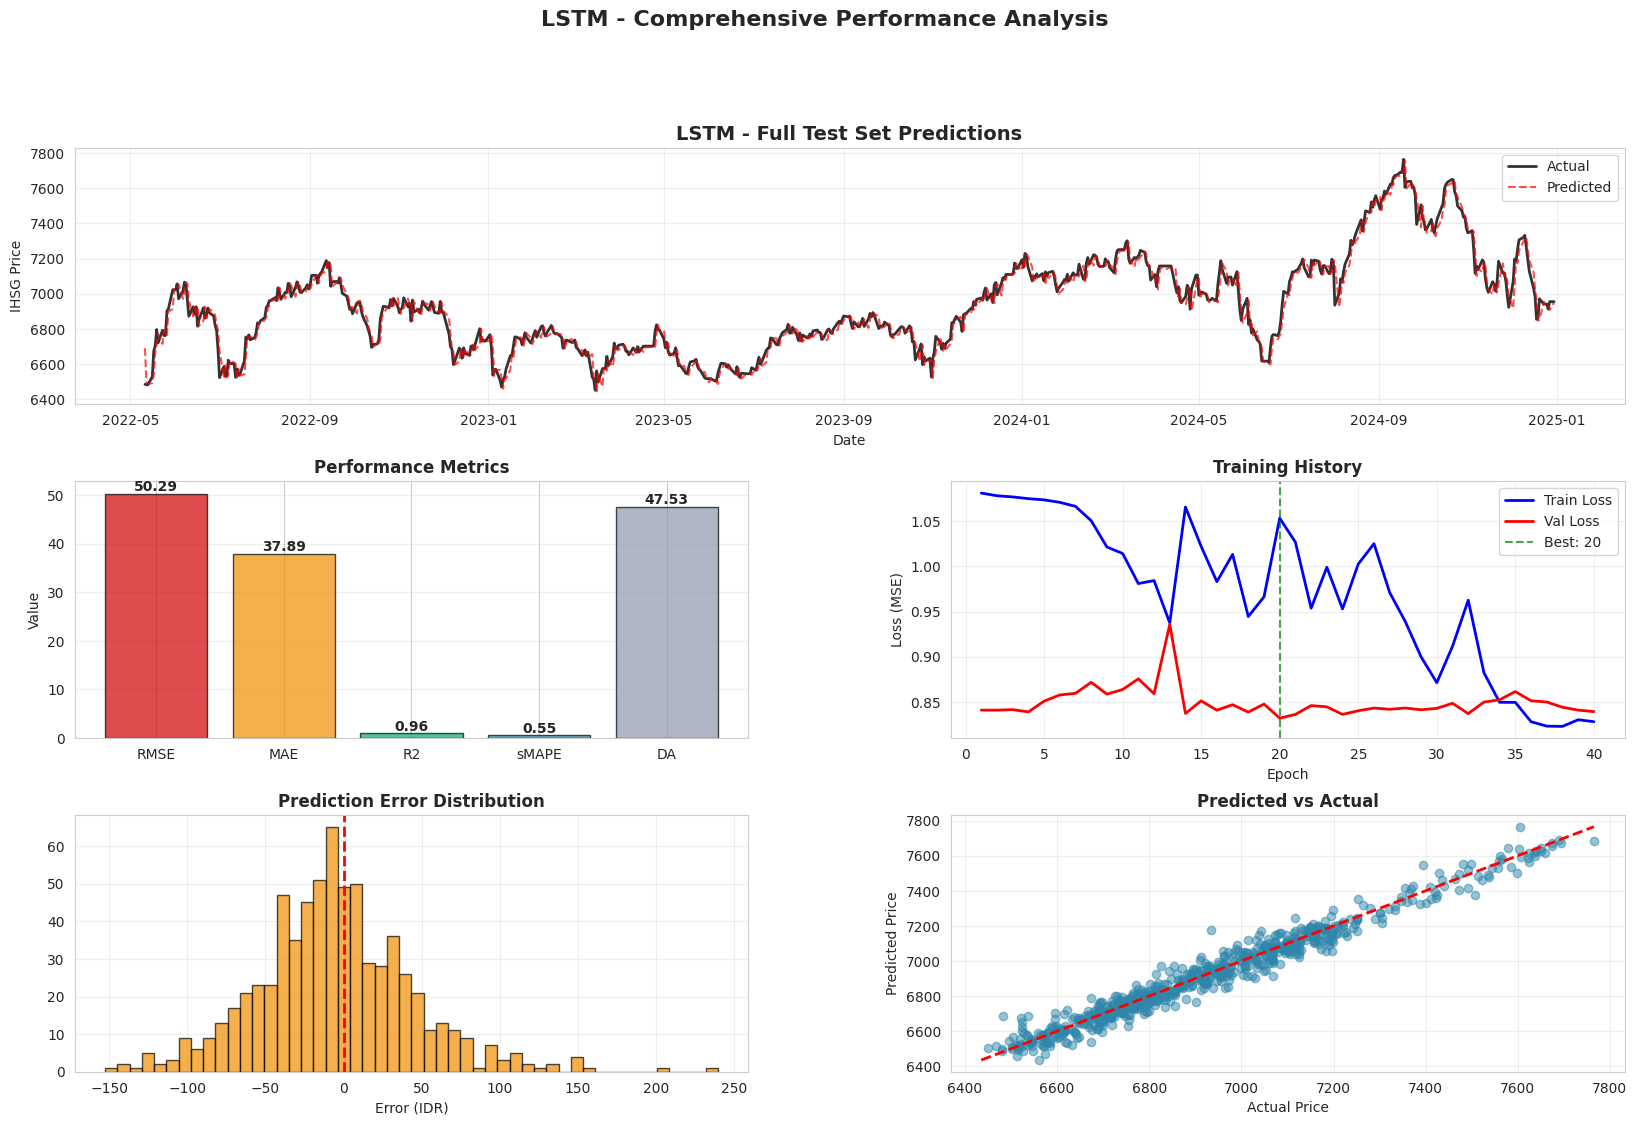

  ✓ Saved: exports-27-oktober-2025/visualizations/lstm_performance.png


In [4]:
# ===================================================================
# SECTION 5: LSTM MODEL
# ===================================================================

print("\n" + "="*70)
print("[SECTION 5] LSTM MODEL")
print("="*70)

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, 
                           dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.dropout(out[:, -1, :])
        return self.fc(out)
    
use_predefined_params = True

if use_predefined_params:
    predefined_params_lstm = {
        'hidden_size': 64, 
        'num_layers': 2, 
        'dropout': 0.12146846558851326, 
        'lr': 0.003801462494535381, 
        'batch_size': 64
    }
    best_params_lstm = predefined_params_lstm
    print("✓ Using predefined LSTM parameters.")
else:
    print("\n[Hyperparameter Tuning - 20 Trials]")

    def objective_lstm(trial):
        params = {
            'hidden_size': trial.suggest_categorical('hidden_size', [64, 128, 256]),
            'num_layers': trial.suggest_int('num_layers', 1, 3),
            'dropout': trial.suggest_float('dropout', 0.1, 0.3),
            'lr': trial.suggest_float('lr', 1e-4, 1e-2, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128])
        }
        
        tscv = TimeSeriesSplit(n_splits=3)
        fold_scores = []
        
        for train_idx, val_idx in tscv.split(X_train_seq):
            X_fold_train = X_train_seq[train_idx]
            y_fold_train = y_train_seq[train_idx]
            X_fold_val = X_train_seq[val_idx]
            y_fold_val = y_train_seq[val_idx]
            
            train_dataset = TimeSeriesDataset(X_fold_train, y_fold_train.reshape(-1, 1))
            val_dataset = TimeSeriesDataset(X_fold_val, y_fold_val.reshape(-1, 1))
            
            train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=False)
            val_loader = DataLoader(val_dataset, batch_size=params['batch_size'], shuffle=False)
            
            model = LSTMModel(X_train_scaled.shape[1], params['hidden_size'], 
                            params['num_layers'], params['dropout']).to(config.DEVICE)
            
            criterion = nn.MSELoss()
            optimizer = Adam(model.parameters(), lr=params['lr'])
            
            _, history = train_model(model, train_loader, val_loader, criterion, 
                                    optimizer, epochs=50, patience=10, device=config.DEVICE)
            
            fold_scores.append(min(history['val_loss']))
        
        return np.mean(fold_scores)

    study_lstm = optuna.create_study(direction='minimize')
    study_lstm.optimize(objective_lstm, n_trials=20, show_progress_bar=True)
    best_params_lstm = study_lstm.best_params

print(f"✓ Best params: {best_params_lstm}")

# Final training
val_size = int(len(X_train_seq) * 0.15)
X_val = X_train_seq[-val_size:]
y_val = y_train_seq[-val_size:]
X_train_final = X_train_seq[:-val_size]
y_train_final = y_train_seq[:-val_size]

train_dataset = TimeSeriesDataset(X_train_final, y_train_final.reshape(-1, 1))
val_dataset = TimeSeriesDataset(X_val, y_val.reshape(-1, 1))

train_loader = DataLoader(train_dataset, batch_size=best_params_lstm['batch_size'], shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=best_params_lstm['batch_size'], shuffle=False)

lstm_model = LSTMModel(X_train_scaled.shape[1], best_params_lstm['hidden_size'],
                      best_params_lstm['num_layers'], best_params_lstm['dropout']).to(config.DEVICE)

criterion = nn.MSELoss()
optimizer = Adam(lstm_model.parameters(), lr=best_params_lstm['lr'])

lstm_model, history = train_model(lstm_model, train_loader, val_loader, criterion,
                                 optimizer, epochs=200, patience=20, device=config.DEVICE)

torch.save(lstm_model.state_dict(), f"{config.OUTPUT_DIR}/models/lstm.pt")
trained_models['LSTM'] = lstm_model

# Evaluation
lstm_pred_test, lstm_actual_test = evaluate_model(lstm_model, X_test_seq, y_test_seq,
                                                   scaler_y, config.DEVICE, last_actual_price_train)

metrics = calculate_metrics(lstm_actual_test, lstm_pred_test)
metrics.update(calculate_economic_metrics(lstm_actual_test, lstm_pred_test))
metrics['Model'] = 'LSTM'

all_results.append(metrics)
all_predictions['LSTM'] = {
    'predictions': lstm_pred_test,
    'actuals': lstm_actual_test,
    'dates': test_dates_seq,
    'history': history
}

# Store for ensemble
lstm_model.eval()
with torch.no_grad():
    X_train_tensor = torch.from_numpy(X_train_seq).to(config.DTYPE).to(config.DEVICE)
    lstm_pred_train_scaled = lstm_model(X_train_tensor).cpu().numpy().flatten()
    
    X_test_tensor = torch.from_numpy(X_test_seq).to(config.DTYPE).to(config.DEVICE)
    lstm_pred_test_scaled = lstm_model(X_test_tensor).cpu().numpy().flatten()

base_model_predictions['LSTM'] = {
    'train_pred_scaled': lstm_pred_train_scaled,
    'test_pred_scaled': lstm_pred_test_scaled,
    'train_actual_scaled': y_train_seq,
    'test_actual_scaled': y_test_seq
}

print("\n[Metrics]")
for k, v in metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")

plot_individual_model('LSTM', lstm_pred_test, lstm_actual_test, test_dates_seq, 
                     metrics, history, f'{config.OUTPUT_DIR}/visualizations/lstm_performance.png')



[SECTION 6] SIMPLIFIED TCN MODEL
✓ Using predefined TCN parameters.
✓ Best params: {'base_channels': 64, 'num_levels': 3, 'dropout': 0.2832558059711251, 'lr': 0.00401564921756082, 'batch_size': 128}
  Epoch 10/200: Train=0.947931, Val=0.896969
  Epoch 20/200: Train=0.879527, Val=1.223645
  Early stopping at epoch 21

[Metrics]
  RMSE: 54.1791
  MAE: 41.3898
  R2: 0.9589
  sMAPE: 0.5965
  Directional_Accuracy: 47.3837
  Cumulative_Return_%: -30.2717
  Sharpe_Ratio: -2.4439
  Win_Rate_%: 42.5352
  Max_Drawdown_%: -35.1739


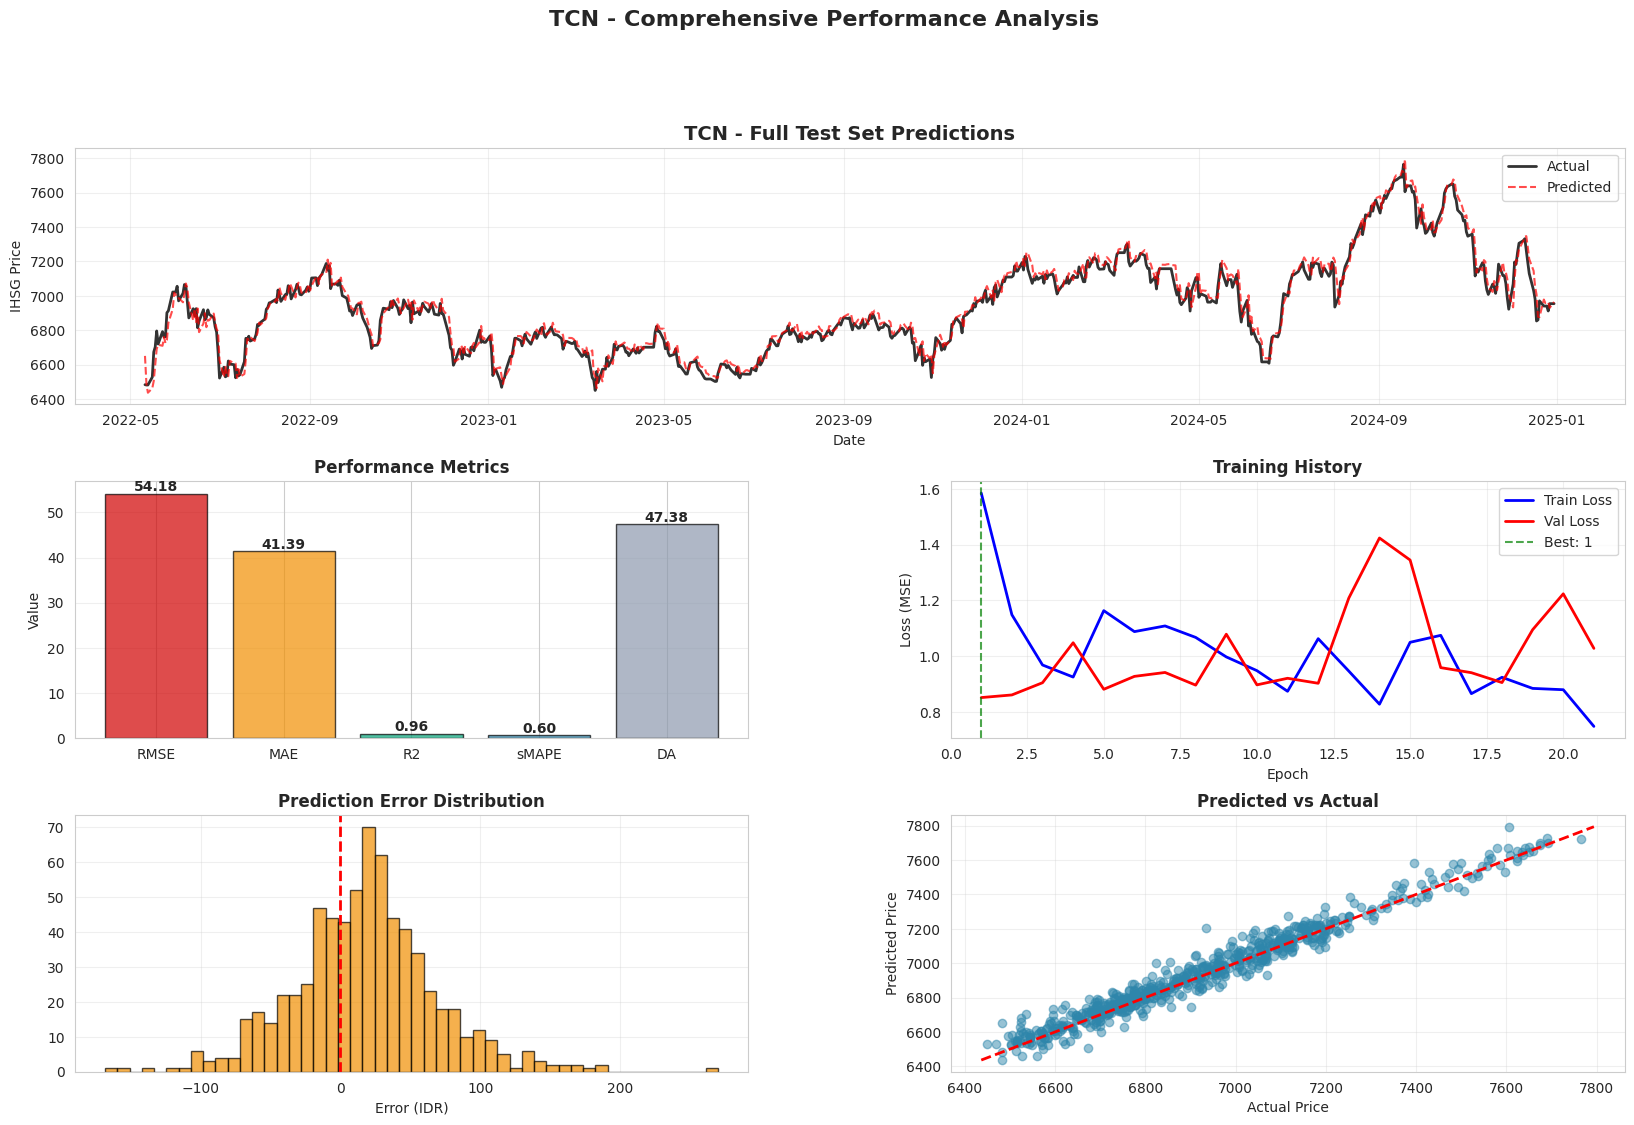

  ✓ Saved: exports-27-oktober-2025/visualizations/tcn_performance.png


In [5]:
# ===================================================================
# SECTION 6: SIMPLIFIED TCN MODEL
# ===================================================================

print("\n" + "="*70)
print("[SECTION 6] SIMPLIFIED TCN MODEL")
print("="*70)

class SimplifiedTCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation
        
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, 
                              padding=padding, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        
        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.chomp_size = padding
    
    def forward(self, x):
        out = self.conv1(x)
        if self.chomp_size > 0:
            out = out[:, :, :-self.chomp_size]
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        
        res = x if self.downsample is None else self.downsample(x)
        if out.size(2) != res.size(2):
            res = res[:, :, :out.size(2)]
        
        return self.relu(out + res)

class SimplifiedTCN(nn.Module):
    def __init__(self, input_size, num_channels=[64, 128], kernel_size=3, dropout=0.2):
        super().__init__()
        layers = []
        for i in range(len(num_channels)):
            dilation = 2 ** i
            in_ch = input_size if i == 0 else num_channels[i-1]
            out_ch = num_channels[i]
            layers.append(SimplifiedTCNBlock(in_ch, out_ch, kernel_size, dilation, dropout))
        
        self.network = nn.Sequential(*layers)
        self.fc = nn.Linear(num_channels[-1], 1)
    
    def forward(self, x):
        x = x.transpose(1, 2)
        out = self.network(x)
        out = out[:, :, -1]
        return self.fc(out)

use_predefined_params = True

if use_predefined_params:
    predefined_params_tcn = {
        'base_channels': 64, 
        'num_levels': 3, 
        'dropout': 0.2832558059711251, 
        'lr': 0.00401564921756082, 
        'batch_size': 128
    }
    best_params_tcn = predefined_params_tcn
    print("✓ Using predefined TCN parameters.")
else:
    print("\n[Hyperparameter Tuning - 20 Trials]")

    def objective_tcn(trial):
        base_channels = trial.suggest_categorical('base_channels', [32, 64])
        num_levels = trial.suggest_int('num_levels', 2, 3)
        
        params = {
            'num_channels': [base_channels * (i+1) for i in range(num_levels)],
            'kernel_size': 3,
            'dropout': trial.suggest_float('dropout', 0.1, 0.3),
            'lr': trial.suggest_float('lr', 5e-4, 5e-3, log=True),
            'batch_size': trial.suggest_categorical('batch_size', [64, 128, 256])
        }
        
        tscv = TimeSeriesSplit(n_splits=3)
        fold_scores = []
        
        for train_idx, val_idx in tscv.split(X_train_seq):
            X_fold_train = X_train_seq[train_idx]
            y_fold_train = y_train_seq[train_idx]
            X_fold_val = X_train_seq[val_idx]
            y_fold_val = y_train_seq[val_idx]
            
            train_dataset = TimeSeriesDataset(X_fold_train, y_fold_train.reshape(-1, 1))
            val_dataset = TimeSeriesDataset(X_fold_val, y_fold_val.reshape(-1, 1))
            
            train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], 
                                    shuffle=False, num_workers=config.NUM_THREADS)
            val_loader = DataLoader(val_dataset, batch_size=params['batch_size'], 
                                shuffle=False, num_workers=config.NUM_THREADS)
            
            model = SimplifiedTCN(X_train_scaled.shape[1], params['num_channels'],
                                params['kernel_size'], params['dropout']).to(config.DEVICE)
            
            criterion = nn.MSELoss()
            optimizer = Adam(model.parameters(), lr=params['lr'])
            
            _, history = train_model(model, train_loader, val_loader, criterion,
                                    optimizer, epochs=30, patience=8, device=config.DEVICE)
            
            fold_scores.append(min(history['val_loss']))
        
        return np.mean(fold_scores)

    study_tcn = optuna.create_study(direction='minimize')
    study_tcn.optimize(objective_tcn, n_trials=20, show_progress_bar=True)
    best_params_tcn = study_tcn.best_params


print(f"✓ Best params: {best_params_tcn}")

num_levels = best_params_tcn['num_levels']
base_channels = best_params_tcn['base_channels']
best_params_tcn['num_channels'] = [base_channels * (i+1) for i in range(num_levels)]
best_params_tcn['kernel_size'] = 3
# Final training
train_dataset = TimeSeriesDataset(X_train_final, y_train_final.reshape(-1, 1))
val_dataset = TimeSeriesDataset(X_val, y_val.reshape(-1, 1))

train_loader = DataLoader(train_dataset, batch_size=best_params_tcn['batch_size'], shuffle=False)
val_loader = DataLoader(val_dataset, batch_size=best_params_tcn['batch_size'], shuffle=False)

tcn_model = SimplifiedTCN(X_train_scaled.shape[1], best_params_tcn['num_channels'],
                         best_params_tcn['kernel_size'], best_params_tcn['dropout']).to(config.DEVICE)

criterion = nn.MSELoss()
optimizer = Adam(tcn_model.parameters(), lr=best_params_tcn['lr'])

tcn_model, history = train_model(tcn_model, train_loader, val_loader, criterion,
                                optimizer, epochs=200, patience=20, device=config.DEVICE)

torch.save(tcn_model.state_dict(), f"{config.OUTPUT_DIR}/models/tcn.pt")
trained_models['TCN'] = tcn_model

# Evaluation
tcn_pred_test, tcn_actual_test = evaluate_model(tcn_model, X_test_seq, y_test_seq,
                                                scaler_y, config.DEVICE, last_actual_price_train)

metrics = calculate_metrics(tcn_actual_test, tcn_pred_test)
metrics.update(calculate_economic_metrics(tcn_actual_test, tcn_pred_test))
metrics['Model'] = 'TCN'

all_results.append(metrics)
all_predictions['TCN'] = {
    'predictions': tcn_pred_test,
    'actuals': tcn_actual_test,
    'dates': test_dates_seq,
    'history': history
}

# Store for ensemble
tcn_model.eval()
with torch.no_grad():
    X_train_tensor = torch.from_numpy(X_train_seq).to(config.DTYPE).to(config.DEVICE)
    tcn_pred_train_scaled = tcn_model(X_train_tensor).cpu().numpy().flatten()
    
    X_test_tensor = torch.from_numpy(X_test_seq).to(config.DTYPE).to(config.DEVICE)
    tcn_pred_test_scaled = tcn_model(X_test_tensor).cpu().numpy().flatten()

base_model_predictions['TCN'] = {
    'train_pred_scaled': tcn_pred_train_scaled,
    'test_pred_scaled': tcn_pred_test_scaled,
    'train_actual_scaled': y_train_seq,
    'test_actual_scaled': y_test_seq
}

print("\n[Metrics]")
for k, v in metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")

plot_individual_model('TCN', tcn_pred_test, tcn_actual_test, test_dates_seq,
                     metrics, history, f'{config.OUTPUT_DIR}/visualizations/tcn_performance.png')


In [6]:
# %%
# ===================================================================
# SECTION 7: TABNET STANDALONE MODEL (FIXED)
# ===================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import joblib, json
import torch
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
from pytorch_tabnet.tab_model import TabNetRegressor
import optuna

# Assuming the following variables are defined from previous sections:
# config, X_train_seq, y_train_seq, X_test_seq, y_test_seq, feature_cols,
# scaler_y, last_actual_price_train, test_dates_seq,
# all_results, all_predictions, trained_models, base_model_predictions,
# calculate_metrics, calculate_economic_metrics

print("\n" + "="*70)
print("[SECTION 7] TABNET STANDALONE MODEL")
print("="*70)

def extract_temporal_features(X_seq):
    """Extract more meaningful statistical features"""
    features_list = [
        X_seq[:, -1, :],                      # Last timestep (t)
        X_seq[:, -2, :] if X_seq.shape[1] >= 2 else X_seq[:, -1, :], # t-1
        X_seq[:, -5, :] if X_seq.shape[1] >= 5 else X_seq[:, -1, :], # t-5
        np.mean(X_seq, axis=1),               # Mean
        np.std(X_seq, axis=1),                # Std
        np.min(X_seq, axis=1),                # Min
        np.max(X_seq, axis=1),                # Max
        X_seq[:, -1, :] - X_seq[:, 0, :],     # Change (last - first)
        np.percentile(X_seq, 25, axis=1),     # Q1
        np.percentile(X_seq, 75, axis=1),     # Q3
        np.median(X_seq, axis=1),             # Median
        # Trend features (ensure correct reshaping)
        np.array([np.polyfit(range(X_seq.shape[1]), X_seq[i, :, j], 1)[0]
                  for i in range(X_seq.shape[0])
                  for j in range(X_seq.shape[2])]).reshape(X_seq.shape[0], X_seq.shape[2]),
    ]
    return np.concatenate(features_list, axis=1)

print("\n[Extracting temporal features from sequences]")
# Ensure X_train_seq and X_test_seq are defined numpy arrays
X_train_flat = extract_temporal_features(X_train_seq)
X_test_flat = extract_temporal_features(X_test_seq)

print(f"  Sequence shape: {X_train_seq.shape}")
print(f"  Extracted shape: {X_train_flat.shape}")

# Categorical features
categorical_idxs = []
categorical_dims = []
# Ensure feature_cols is a defined list of strings
if 'feature_cols' in globals() and isinstance(feature_cols, list):
    for feat_name in ['DayOfWeek', 'Month', 'Quarter']:
        if feat_name in feature_cols:
            try:
                idx = feature_cols.index(feat_name)
                 # Adjust index based on the structure created by extract_temporal_features
                 # Since the last original feature is at index [:, -1, :], we need to find its corresponding index
                 # in the flattened structure.
                 # Let's assume the base features are the first set in the flattened array.
                base_feature_idx = idx # Index within the original feature set
                # We need to find where this feature appears in the flattened array.
                # Since extract_temporal_features concatenates features, we need to map the original index.
                # For simplicity, we'll assume the categorical features are used directly
                # in the *first* block (X_seq[:, -1, :]) of the concatenated features.
                # If they appear in other blocks (like mean, std etc.), this needs adjustment.
                # Let's assume they only matter for the 'last timestep' features.
                flat_idx = base_feature_idx # Index in the first block of the flattened array
                categorical_idxs.append(flat_idx)

                if feat_name == 'DayOfWeek':
                    categorical_dims.append(7)
                elif feat_name == 'Month':
                    categorical_dims.append(12)
                elif feat_name == 'Quarter':
                    categorical_dims.append(4)
            except ValueError:
                print(f"Warning: Categorical feature '{feat_name}' not found in feature_cols.")
else:
     print("Warning: 'feature_cols' not defined or not a list. Skipping categorical features for TabNet.")


print(f"  Categorical indices identified: {categorical_idxs}")
print(f"  Categorical dimensions: {categorical_dims}")


# Split validation
val_size = int(len(X_train_flat) * 0.15)
X_train_tabnet = X_train_flat[:-val_size]
X_val_tabnet = X_train_flat[-val_size:]
y_train_tabnet = y_train_seq[:-val_size]
y_val_tabnet = y_train_seq[-val_size:]

# --- ADDED TOGGLE ---
use_predefined_params = True # Set to False to run Optuna tuning
# --------------------

if use_predefined_params:
    predefined_params_tabnet = {
        'batch_size': 512,
        'n_d': 64,
        'n_a': 64,
        'n_steps': 8,
        'gamma': 1.0514945702018803,
        'lambda_sparse': 1.777830652544828e-06,
        'mask_type': 'sparsemax',
        'lr': 0.0156645728697659,
        'cat_emb_dim': 1
    }
    # Ensure all necessary keys for final_params are present
    best_params_tabnet = predefined_params_tabnet
    print("✓ Using predefined TabNet parameters.")
else:
    print("\n[Hyperparameter Tuning - Optuna]") # Reduced trials for faster execution if needed
    optuna.logging.set_verbosity(optuna.logging.WARNING) # Reduce optuna logging verbosity

    def objective_tabnet(trial):
        batch_size_opt = trial.suggest_categorical('batch_size', [64, 128, 256, 512])
        # Ensure virtual_batch_size is at least 1 and doesn't exceed batch_size
        virtual_batch_size_opt = max(1, min(batch_size_opt // 4, 128)) # Also cap virtual batch size

        params = {
            'n_d': trial.suggest_categorical('n_d', [32, 64, 128]), # Simplified choices
            'n_a': trial.suggest_categorical('n_a', [32, 64, 128]), # Simplified choices
            'n_steps': trial.suggest_categorical('n_steps', [4, 6, 8]), # Simplified choices
            'gamma': trial.suggest_float('gamma', 1.0, 2.0), # Narrowed range
            'lambda_sparse': trial.suggest_float('lambda_sparse', 1e-6, 1e-3, log=True), # Adjusted range
            'mask_type': trial.suggest_categorical('mask_type', ['sparsemax', 'entmax']), # Added entmax
            'optimizer_fn': torch.optim.AdamW, # Changed to AdamW
            'optimizer_params': dict(lr=trial.suggest_float('lr', 5e-4, 2e-2, log=True)), # Adjusted range
            'scheduler_params': {"step_size": 20, "gamma": 0.9}, # Faster decay
            'scheduler_fn': torch.optim.lr_scheduler.StepLR,
            'seed': config.SEED,
            'verbose': 0 # Suppress verbose logging during tuning
        }

        if len(categorical_idxs) > 0:
            params['cat_idxs'] = categorical_idxs
            params['cat_dims'] = categorical_dims
            # Ensure cat_emb_dim matches number of categorical features if needed, or is fixed
            params['cat_emb_dim'] = trial.suggest_int("cat_emb_dim", 1, min(5, len(categorical_idxs) if categorical_idxs else 1)) # Cap embedding dim


        tscv = TimeSeriesSplit(n_splits=2) # Use 2 splits for faster tuning
        fold_scores = []

        for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_flat)):
            X_fold_train = X_train_flat[train_idx]
            y_fold_train = y_train_seq[train_idx]
            X_fold_val = X_train_flat[val_idx]
            y_fold_val = y_train_seq[val_idx]

            model = TabNetRegressor(**params)

            try:
                model.fit(
                    X_fold_train, y_fold_train.reshape(-1, 1),
                    eval_set=[(X_fold_val, y_fold_val.reshape(-1, 1))],
                    max_epochs=50, # Reduced epochs for tuning
                    patience=10,   # Reduced patience for tuning
                    batch_size=batch_size_opt,
                    virtual_batch_size=virtual_batch_size_opt,
                    num_workers = 0, # Set num_workers to 0 for Optuna compatibility if issues arise
                    drop_last=False, # Important for smaller datasets/folds
                    eval_metric=['rmse']
                )

                val_pred = model.predict(X_fold_val)
                val_score = mean_squared_error(y_fold_val.reshape(-1, 1), val_pred)
                fold_scores.append(val_score)
            except Exception as e:
                 print(f"Error during Optuna trial fold {fold+1}: {e}")
                 # Penalize failed trials heavily
                 # Check if trial object exists before pruning
                 if trial:
                     # Pruning might not work if error is too early, return a high loss instead
                     return float('inf') # Return a very high loss for failed trials


        # Check if fold_scores is empty before calculating mean
        if not fold_scores:
             print("Warning: No successful folds in Optuna trial. Returning high loss.")
             return float('inf')


        mean_score = np.mean(fold_scores)
        # Handle potential NaN scores
        if np.isnan(mean_score):
             print("Warning: NaN score encountered in Optuna trial. Returning high loss.")
             return float('inf')


        return mean_score


    study_tabnet = optuna.create_study(direction='minimize')
    # Use fewer trials if needed for speed, e.g., n_trials=20
    study_tabnet.optimize(objective_tabnet, n_trials=30, show_progress_bar=True) # Reduced trials

    best_params_tabnet = study_tabnet.best_params
    # Add back keys needed for final_params if missing from Optuna search space
    if 'lr' not in best_params_tabnet: # Example if lr wasn't optimized directly
        best_params_tabnet['lr'] = study_tabnet.best_params.get('optimizer_params', {}).get('lr', 0.01) # Default or extract
    if 'cat_emb_dim' not in best_params_tabnet and len(categorical_idxs) > 0:
        best_params_tabnet['cat_emb_dim'] = 1 # Default if not tuned

# --- End of if/else block ---

# Prepare final parameters based on best_params_tabnet (either predefined or from Optuna)
batch_size = best_params_tabnet['batch_size']
virtual_batch_size = max(1, batch_size // 4) # Ensure virtual_batch_size >= 1

final_params = {
    'n_d': best_params_tabnet['n_d'],
    'n_a': best_params_tabnet['n_a'],
    'n_steps': best_params_tabnet['n_steps'],
    'gamma': best_params_tabnet['gamma'],
    'lambda_sparse': best_params_tabnet['lambda_sparse'],
    'mask_type': best_params_tabnet.get('mask_type', 'sparsemax'), # Use .get with default
    'optimizer_fn': torch.optim.AdamW, # Consistently use AdamW
    'optimizer_params': dict(lr=best_params_tabnet['lr']),
    'scheduler_params': {"step_size": 30, "gamma": 0.9}, # Adjusted scheduler
    'scheduler_fn': torch.optim.lr_scheduler.StepLR,
    'seed': config.SEED,
    'verbose': 1 # Show training progress for the final model
}

if len(categorical_idxs) > 0:
    final_params['cat_idxs'] = categorical_idxs
    final_params['cat_dims'] = categorical_dims
    final_params['cat_emb_dim'] = best_params_tabnet.get('cat_emb_dim', 1) # Use .get with default

print(f"✓ Final TabNet params being used: {final_params}") # Print the actual params used

# Final training
print("\n[Training Final TabNet Model]")
tabnet_model = TabNetRegressor(**final_params)

# Ensure data shapes are correct
y_train_tabnet_reshaped = y_train_tabnet.reshape(-1, 1)
y_val_tabnet_reshaped = y_val_tabnet.reshape(-1, 1)

# Check for NaNs or Infs before training
if np.isnan(X_train_tabnet).any() or np.isinf(X_train_tabnet).any():
    print("Warning: NaNs or Infs detected in X_train_tabnet. Attempting to clean.")
    X_train_tabnet = np.nan_to_num(X_train_tabnet)
if np.isnan(y_train_tabnet_reshaped).any() or np.isinf(y_train_tabnet_reshaped).any():
     print("Warning: NaNs or Infs detected in y_train_tabnet. Attempting to clean.")
     y_train_tabnet_reshaped = np.nan_to_num(y_train_tabnet_reshaped)
if np.isnan(X_val_tabnet).any() or np.isinf(X_val_tabnet).any():
     print("Warning: NaNs or Infs detected in X_val_tabnet. Attempting to clean.")
     X_val_tabnet = np.nan_to_num(X_val_tabnet)
if np.isnan(y_val_tabnet_reshaped).any() or np.isinf(y_val_tabnet_reshaped).any():
     print("Warning: NaNs or Infs detected in y_val_tabnet. Attempting to clean.")
     y_val_tabnet_reshaped = np.nan_to_num(y_val_tabnet_reshaped)


try:
    tabnet_model.fit(
        X_train_tabnet, y_train_tabnet_reshaped,
        eval_set=[(X_val_tabnet, y_val_tabnet_reshaped)],
        max_epochs=200, # Reduced epochs for potentially faster final training
        patience=25,    # Slightly reduced patience
        batch_size=batch_size,
        virtual_batch_size=virtual_batch_size,
        num_workers=0, # Set explicitly to 0 if issues persist
        drop_last=False, # Avoid dropping last batch
        eval_metric=['rmse']
    )
except Exception as e:
    print(f"ERROR during final TabNet training: {e}")
    # Optional: Add fallback or raise the error
    raise e


# --- Rest of the Section 7 code ---

# Get predictions in SCALED space (returns)
tabnet_pred_test_scaled = tabnet_model.predict(X_test_flat).flatten()
tabnet_pred_train_scaled = tabnet_model.predict(X_train_flat).flatten()

# Inverse transform to get actual returns
tabnet_pred_returns = scaler_y.inverse_transform(tabnet_pred_test_scaled.reshape(-1, 1)).flatten()
tabnet_actual_returns = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Reconstruct prices from returns
base_prices = [last_actual_price_train]
# Ensure actual_returns is 1D array
tabnet_actual_returns_1d = tabnet_actual_returns.flatten()
for ret in tabnet_actual_returns_1d:
     # Add safety check for extreme values if needed
     next_price = base_prices[-1] * (1 + ret)
     if np.isfinite(next_price):
         base_prices.append(next_price)
     else:
         print(f"Warning: Non-finite base price calculation encountered (ret={ret}). Using previous price.")
         base_prices.append(base_prices[-1]) # Use previous price if calculation fails


tabnet_pred_test = np.zeros_like(tabnet_pred_returns)
tabnet_actual_test = np.zeros_like(tabnet_actual_returns)

# Make sure base_prices has enough elements
num_predictions = len(tabnet_pred_returns)
if len(base_prices) < num_predictions + 1:
    print(f"Warning: base_prices length ({len(base_prices)}) insufficient for predictions ({num_predictions}). Truncating predictions.")
    num_predictions = len(base_prices) - 1
    tabnet_pred_returns = tabnet_pred_returns[:num_predictions]
    tabnet_actual_returns = tabnet_actual_returns[:num_predictions] # Ensure actuals also match
    tabnet_pred_test = np.zeros(num_predictions)
    tabnet_actual_test = np.zeros(num_predictions)
    # Also adjust test_dates_seq if necessary
    if 'test_dates_seq' in globals() and len(test_dates_seq) > num_predictions:
         test_dates_seq = test_dates_seq[:num_predictions]



for i in range(num_predictions):
     # Add safety checks for finite values
     pred_price = base_prices[i] * (1 + tabnet_pred_returns[i])
     act_price = base_prices[i] * (1 + tabnet_actual_returns[i])
     tabnet_pred_test[i] = pred_price if np.isfinite(pred_price) else base_prices[i] # Fallback
     tabnet_actual_test[i] = act_price if np.isfinite(act_price) else base_prices[i] # Fallback


# --- Save model ---
try:
    model_save_path = f"{config.OUTPUT_DIR}/models/tabnet.zip" # Save as zip
    tabnet_model.save_model(model_save_path)
    print(f"✓ TabNet model saved to {model_save_path}")
    trained_models['TabNet'] = tabnet_model # Store the trained model object
except Exception as e:
    print(f"Error saving TabNet model: {e}")


# --- Evaluation ---
# Ensure actual and prediction arrays are finite before calculating metrics
tabnet_actual_test = np.nan_to_num(tabnet_actual_test)
tabnet_pred_test = np.nan_to_num(tabnet_pred_test)

metrics = calculate_metrics(tabnet_actual_test, tabnet_pred_test)
metrics.update(calculate_economic_metrics(tabnet_actual_test, tabnet_pred_test))
metrics['Model'] = 'TabNet'

all_results.append(metrics)
# Ensure test_dates_seq length matches predictions/actuals length after potential truncation
if 'test_dates_seq' in globals() and len(test_dates_seq) != len(tabnet_pred_test):
     print(f"Adjusting test_dates_seq length from {len(test_dates_seq)} to {len(tabnet_pred_test)}")
     test_dates_seq = test_dates_seq[:len(tabnet_pred_test)]


all_predictions['TabNet'] = {
    'predictions': tabnet_pred_test,
    'actuals': tabnet_actual_test,
    'dates': test_dates_seq,
    'history': tabnet_model.history # Store training history
}

# Store for ensemble
base_model_predictions['TabNet'] = {
    'train_pred_scaled': tabnet_pred_train_scaled,
    'test_pred_scaled': tabnet_pred_test_scaled,
    'train_actual_scaled': y_train_seq,
    'test_actual_scaled': y_test_seq[:len(tabnet_pred_test_scaled)] # Match length if test set was truncated
}

print("\n[Metrics]")
for k, v in metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")

# --- Plotting ---
# Ensure plotting functions handle potential errors or missing history
try:
    # Custom plot for TabNet (using model.history)
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(3, 2, hspace=0.4, wspace=0.3) # Increased hspace

    # Plot 1: Predictions vs Actual
    ax1 = fig.add_subplot(gs[0, :])
    if len(test_dates_seq) == len(tabnet_actual_test) == len(tabnet_pred_test):
        ax1.plot(test_dates_seq, tabnet_actual_test, label='Actual', color='black', linewidth=2, alpha=0.8)
        ax1.plot(test_dates_seq, tabnet_pred_test, label='Predicted', color='red', linewidth=1.5, linestyle='--', alpha=0.7)
        ax1.set_title('TabNet - Test Set Predictions', fontsize=14, fontweight='bold')
        ax1.set_xlabel('Date')
        ax1.set_ylabel('IHSG Price')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
    else:
         ax1.text(0.5, 0.5, 'Error: Data length mismatch for plotting predictions.', ha='center', va='center')
         ax1.set_title('TabNet - Test Set Predictions (Error)', fontsize=14, fontweight='bold')


    # Plot 2: Performance Metrics
    ax2 = fig.add_subplot(gs[1, 0])
    metric_names = ['RMSE', 'MAE', 'R2', 'sMAPE', 'DA']
    # Use .get() with default values in case a metric calculation failed
    metric_values = [metrics.get('RMSE', np.nan), metrics.get('MAE', np.nan), metrics.get('R2', np.nan),
                     metrics.get('sMAPE', np.nan), metrics.get('Directional_Accuracy', np.nan)]
    colors = ['#D00000', '#F18F01', '#06A77D', '#2E86AB', '#8D99AE']
    # Filter out NaN values before plotting bars
    valid_metrics = {name: val for name, val in zip(metric_names, metric_values) if pd.notna(val)}
    if valid_metrics:
        bars = ax2.bar(valid_metrics.keys(), valid_metrics.values(), color=colors[:len(valid_metrics)], alpha=0.7, edgecolor='black')
        ax2.set_title('Performance Metrics', fontweight='bold')
        ax2.set_ylabel('Value')
        ax2.grid(axis='y', alpha=0.3)
        for bar, val in zip(bars, valid_metrics.values()):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                     f'{val:.2f}', ha='center', va='bottom', fontweight='bold')
    else:
        ax2.text(0.5, 0.5, 'Metrics calculation failed.', ha='center', va='center')
        ax2.set_title('Performance Metrics (Error)', fontweight='bold')


    # Plot 3: Training History (Loss)
    ax3 = fig.add_subplot(gs[1, 1])
    if tabnet_model.history and 'loss' in tabnet_model.history and 'val_0_rmse' in tabnet_model.history:
        epochs = range(1, len(tabnet_model.history['loss']) + 1)
        ax3.plot(epochs, tabnet_model.history['loss'], label='Train Loss (MSE)', color='blue', linewidth=2)
        # TabNet history often stores eval metrics like 'val_0_rmse'. Plotting RMSE on loss axis might need scaling or separate axis.
        # Let's plot RMSE, assuming it's comparable enough for trend visualization.
        ax3.plot(epochs, tabnet_model.history['val_0_rmse'], label='Val RMSE', color='red', linewidth=2)
        best_epoch = np.argmin(tabnet_model.history['val_0_rmse']) + 1
        ax3.axvline(best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Val Epoch: {best_epoch}')
        ax3.set_title('Training History', fontweight='bold')
        ax3.set_xlabel('Epoch')
        ax3.set_ylabel('Loss / Metric')
        ax3.legend()
        ax3.grid(True, alpha=0.3)
        # Consider using log scale if losses vary greatly: ax3.set_yscale('log')
    else:
        ax3.text(0.5, 0.5, 'Training history not available\nor keys missing.', ha='center', va='center')
        ax3.set_title('Training History (Unavailable)', fontweight='bold')
        ax3.axis('off')

    # Plot 4: Error Distribution
    ax4 = fig.add_subplot(gs[2, 0])
    if len(tabnet_pred_test) == len(tabnet_actual_test):
         errors = tabnet_pred_test - tabnet_actual_test
         ax4.hist(errors, bins=50, color='#F18F01', alpha=0.7, edgecolor='black')
         ax4.axvline(0, color='red', linestyle='--', linewidth=2)
         ax4.set_title('Prediction Error Distribution', fontweight='bold')
         ax4.set_xlabel('Error (Predicted - Actual)')
         ax4.grid(True, alpha=0.3)
    else:
        ax4.text(0.5, 0.5, 'Error: Data length mismatch for error distribution.', ha='center', va='center')
        ax4.set_title('Prediction Error Distribution (Error)', fontweight='bold')


    # Plot 5: Scatter Plot
    ax5 = fig.add_subplot(gs[2, 1])
    if len(tabnet_actual_test) == len(tabnet_pred_test):
         ax5.scatter(tabnet_actual_test, tabnet_pred_test, alpha=0.5, color='#2E86AB')
         min_val = min(tabnet_actual_test.min(), tabnet_pred_test.min())
         max_val = max(tabnet_actual_test.max(), tabnet_pred_test.max())
         # Add buffer to min/max for plot limits
         buffer = (max_val - min_val) * 0.05
         plot_min = min_val - buffer
         plot_max = max_val + buffer
         ax5.plot([plot_min, plot_max], [plot_min, plot_max], 'r--', linewidth=2) # Diagonal line
         ax5.set_xlim(plot_min, plot_max)
         ax5.set_ylim(plot_min, plot_max)
         ax5.set_title('Predicted vs Actual', fontweight='bold')
         ax5.set_xlabel('Actual Price')
         ax5.set_ylabel('Predicted Price')
         ax5.grid(True, alpha=0.3)
         ax5.set_aspect('equal', adjustable='box') # Make axes equal scale
    else:
        ax5.text(0.5, 0.5, 'Error: Data length mismatch for scatter plot.', ha='center', va='center')
        ax5.set_title('Predicted vs Actual (Error)', fontweight='bold')


    plt.suptitle('TabNet - Comprehensive Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
    plot_save_path = f'{config.OUTPUT_DIR}/visualizations/tabnet_performance.png'
    plt.savefig(plot_save_path, dpi=600, bbox_inches='tight')
    plt.show() # Comment out plt.show() if running in a script
    plt.close()
    print(f"  ✓ Saved: {plot_save_path}")

except Exception as e:
    print(f"Error during TabNet plotting: {e}")
    plt.close() # Ensure plot is closed even if error occurs



[SECTION 7] TABNET STANDALONE MODEL

[Extracting temporal features from sequences]
  Sequence shape: (3024, 90, 51)
  Extracted shape: (3024, 612)
  Categorical indices identified: [48, 49, 50]
  Categorical dimensions: [7, 12, 4]
✓ Using predefined TabNet parameters.
✓ Final TabNet params being used: {'n_d': 64, 'n_a': 64, 'n_steps': 8, 'gamma': 1.0514945702018803, 'lambda_sparse': 1.777830652544828e-06, 'mask_type': 'sparsemax', 'optimizer_fn': <class 'torch.optim.adamw.AdamW'>, 'optimizer_params': {'lr': 0.0156645728697659}, 'scheduler_params': {'step_size': 30, 'gamma': 0.9}, 'scheduler_fn': <class 'torch.optim.lr_scheduler.StepLR'>, 'seed': 42, 'verbose': 1, 'cat_idxs': [48, 49, 50], 'cat_dims': [7, 12, 4], 'cat_emb_dim': 1}

[Training Final TabNet Model]
epoch 0  | loss: 10.33531| val_0_rmse: 1.02904 |  0:00:01s
epoch 1  | loss: 8.21069 | val_0_rmse: 0.95975 |  0:00:03s
epoch 2  | loss: 5.66078 | val_0_rmse: 0.94778 |  0:00:04s
epoch 3  | loss: 4.02878 | val_0_rmse: 0.98296 |  0


[SECTION 8] TABNET-LSTM HYBRID MODEL
✓ Using predefined TabNet-LSTM parameters.
✓ Final Hybrid params being used: {'n_d': 64, 'n_a': 32, 'n_steps': 3, 'lstm_hidden': 64, 'lstm_layers': 3, 'dropout': 0.16962676277003047, 'lr': 0.00013192646440317416, 'batch_size': 32}

[Training Final TabNet-LSTM Model]
  Epoch 10/150: Train=0.925619, Val=0.928980
  Epoch 20/150: Train=0.749179, Val=1.235812
  Early stopping at epoch 21
✓ TabNet-LSTM model state dict saved to exports-27-oktober-2025/models/tabnet_lstm.pt

[Metrics]
  RMSE: 63.5850
  MAE: 48.4968
  R2: 0.9434
  sMAPE: 0.6974
  Directional_Accuracy: 47.9651
  Cumulative_Return_%: -29.4326
  Sharpe_Ratio: -2.3402
  Win_Rate_%: 44.2577
  Max_Drawdown_%: -34.6026


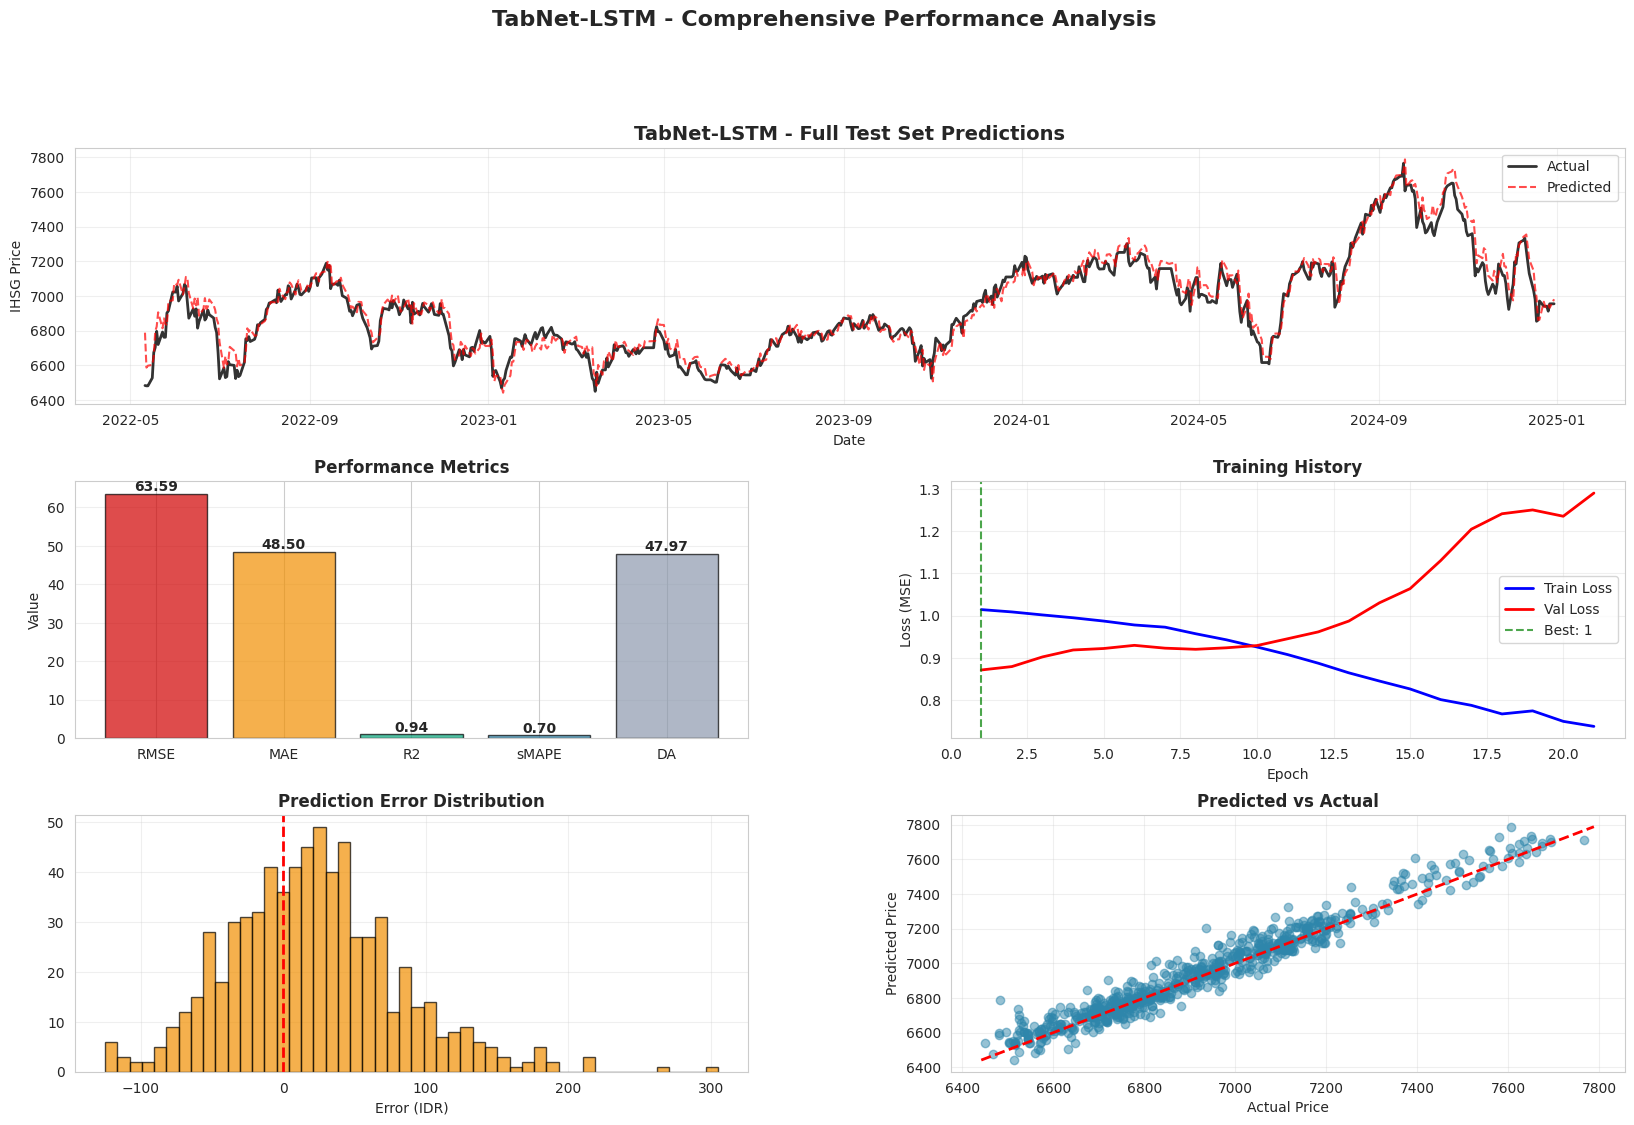

  ✓ Saved: exports-27-oktober-2025/visualizations/tabnet_lstm_performance.png


In [7]:
# %%
# ===================================================================
# SECTION 8: TABNET-LSTM HYBRID MODEL
# ===================================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torch.optim import Adam
from sklearn.model_selection import TimeSeriesSplit
import optuna
import matplotlib.pyplot as plt


# Assuming the following variables are defined from previous sections:
# config, X_train_scaled, X_train_seq, y_train_seq, X_test_seq, y_test_seq,
# scaler_y, last_actual_price_train, test_dates_seq,
# X_train_final, y_train_final, X_val, y_val, TimeSeriesDataset,
# train_model, evaluate_model, calculate_metrics, calculate_economic_metrics, plot_individual_model,
# all_results, all_predictions, trained_models

print("\n" + "="*70)
print("[SECTION 8] TABNET-LSTM HYBRID MODEL")
print("="*70)

class TabNetLSTM(nn.Module):
    def __init__(self, input_size, tabnet_params, lstm_hidden, lstm_layers, dropout=0.2):
        super().__init__()

        # Ensure tabnet_params contains 'n_d' and 'n_a'
        if 'n_d' not in tabnet_params or 'n_a' not in tabnet_params:
             raise ValueError("tabnet_params must contain 'n_d' and 'n_a'")


        tabnet_output_size = tabnet_params['n_d'] + tabnet_params['n_a']

        # Batch Normalization applied to each feature vector at each time step
        # Input shape expected: (Batch, Features)
        self.initial_bn = nn.BatchNorm1d(input_size)

        # Feature Transformer (Simplified TabNet-like block applied per time step)
        self.feature_transformer = nn.Sequential(
            nn.Linear(input_size, tabnet_output_size * 2),
            nn.BatchNorm1d(tabnet_output_size * 2),
            nn.GLU(dim=1), # Gated Linear Unit used in TabNet
        )

        # Attention mechanism (simplified) - creates weights for original features
        self.attention_weights = nn.Linear(tabnet_output_size, input_size)

        # LSTM layer
        self.lstm = nn.LSTM(tabnet_output_size, lstm_hidden, lstm_layers,
                            batch_first=True, dropout=dropout if lstm_layers > 1 else 0)

        # Final layers
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(lstm_hidden, 1) # Output layer

        self.last_attention_mask = None # To store attention mask for interpretability

    def forward(self, x):
        batch_size, seq_len, n_features = x.shape

        tabnet_embeddings = []
        all_masks = [] # Store masks for each step if needed, though we only use the last here

        for t in range(seq_len):
            x_t = x[:, t, :] # Get features for the current time step (Batch, Features)

            # Apply Batch Norm
            x_t_norm = self.initial_bn(x_t)

            # Apply Feature Transformer
            embedding = self.feature_transformer(x_t_norm) # (Batch, tabnet_output_size)

            # Calculate attention weights (optional for interpretation, done only at last step here)
            if t == seq_len - 1:
                attention_logits = self.attention_weights(embedding)
                # Apply Softmax or Sparsemax if needed for interpretation
                self.last_attention_mask = torch.softmax(attention_logits, dim=1)
                all_masks.append(self.last_attention_mask) # Store the last mask

            tabnet_embeddings.append(embedding)

        # Stack embeddings along the sequence dimension
        tabnet_sequence = torch.stack(tabnet_embeddings, dim=1) # (Batch, SeqLen, tabnet_output_size)

        # Pass sequence through LSTM
        lstm_out, _ = self.lstm(tabnet_sequence) # lstm_out shape: (Batch, SeqLen, lstm_hidden)

        # Get the output from the last time step
        out = lstm_out[:, -1, :] # (Batch, lstm_hidden)
        out = self.dropout(out)

        # Final prediction
        return self.fc(out) # (Batch, 1)

    def get_mask(self):
        # Returns the attention mask from the *last* time step's feature transformation
        return self.last_attention_mask


# --- ADDED TOGGLE ---
use_predefined_params = True # Set to False to run Optuna tuning
# --------------------

if use_predefined_params:
    predefined_params_hybrid = {
        'n_d': 64,
        'n_a': 32,
        'n_steps': 3, # This might map to internal TabNet steps if used, but here it's separate
        'lstm_hidden': 64,
        'lstm_layers': 3,
        'dropout': 0.16962676277003047,
        'lr': 0.00013192646440317416,
        'batch_size': 32
    }
    best_params_hybrid = predefined_params_hybrid
    print("✓ Using predefined TabNet-LSTM parameters.")
else:
    print("\n[Hyperparameter Tuning - Optuna]") # Reduced trials
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective_tabnet_lstm(trial):
        # Define search space consistent with predefined_params_hybrid structure
        params = {
            'n_d': trial.suggest_categorical('n_d', [32, 64, 128]),
            'n_a': trial.suggest_categorical('n_a', [32, 64, 128]),
            'n_steps': trial.suggest_int('n_steps', 3, 5), # Simplified range for n_steps (less critical here)
            'lstm_hidden': trial.suggest_categorical('lstm_hidden', [32, 64, 128]),
            'lstm_layers': trial.suggest_int('lstm_layers', 1, 3),
            'dropout': trial.suggest_float('dropout', 0.1, 0.4), # Wider dropout range
            'lr': trial.suggest_float('lr', 1e-4, 5e-3, log=True), # Adjusted LR range
            'batch_size': trial.suggest_categorical('batch_size', [32, 64]) # Smaller batch sizes
        }
        # Separate tabnet specific params for model init
        tabnet_params_trial = {
             'n_d': params['n_d'],
             'n_a': params['n_a'],
             # n_steps from params isn't directly used in TabNetLSTM structure here,
             # but we keep it in params dict for consistency with predefined structure
        }


        tscv = TimeSeriesSplit(n_splits=2) # 2 splits for faster tuning
        fold_scores = []

        # Ensure X_train_seq is defined and is a numpy array
        if 'X_train_seq' not in globals() or not isinstance(X_train_seq, np.ndarray):
             print("Error: X_train_seq is not defined or not a numpy array.")
             return float('inf') # Return high loss if data is missing

        for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train_seq)):
            # Check if indices are valid
            if len(train_idx) == 0 or len(val_idx) == 0:
                 print(f"Warning: Empty train or validation set in fold {fold+1}. Skipping.")
                 continue

            X_fold_train = X_train_seq[train_idx]
            y_fold_train = y_train_seq[train_idx]
            X_fold_val = X_train_seq[val_idx]
            y_fold_val = y_train_seq[val_idx]

            train_dataset = TimeSeriesDataset(X_fold_train, y_fold_train.reshape(-1, 1))
            val_dataset = TimeSeriesDataset(X_fold_val, y_fold_val.reshape(-1, 1))

            train_loader = DataLoader(train_dataset, batch_size=params['batch_size'], shuffle=False, num_workers=0)
            val_loader = DataLoader(val_dataset, batch_size=params['batch_size'], shuffle=False, num_workers=0)

            # Ensure input_size is derived correctly
            input_size = X_train_scaled.shape[1] if 'X_train_scaled' in globals() else X_fold_train.shape[2]


            model = TabNetLSTM(input_size, tabnet_params_trial,
                               params['lstm_hidden'], params['lstm_layers'],
                               params['dropout']).to(config.DEVICE)

            criterion = nn.MSELoss()
            optimizer = Adam(model.parameters(), lr=params['lr'])

            try:
                # Use fewer epochs/patience for tuning
                _, history = train_model(model, train_loader, val_loader, criterion,
                                         optimizer, epochs=30, patience=8, device=config.DEVICE) # Reduced epochs/patience

                # Check if history is valid and contains 'val_loss'
                if history and 'val_loss' in history and history['val_loss']:
                     fold_scores.append(min(history['val_loss']))
                else:
                    print(f"Warning: Invalid history or empty val_loss in fold {fold+1}. Skipping score.")
                    # Optionally append a high score or handle as needed
                    fold_scores.append(float('inf'))

            except Exception as e:
                print(f"Error during Optuna trial (Hybrid) fold {fold+1}: {e}")
                # Append a high score for failed folds
                fold_scores.append(float('inf'))


        # Calculate mean score, handling cases where folds failed
        valid_scores = [s for s in fold_scores if np.isfinite(s)]
        if not valid_scores:
            print("Warning: No successful folds in Optuna trial (Hybrid). Returning high loss.")
            return float('inf')

        mean_score = np.mean(valid_scores)
        if np.isnan(mean_score):
             print("Warning: NaN score encountered in Optuna trial (Hybrid). Returning high loss.")
             return float('inf')


        # Store the flat parameters dictionary in the trial's user attributes
        trial.set_user_attr("flat_params", params)

        return mean_score


    study_tabnet_lstm = optuna.create_study(direction='minimize')
    study_tabnet_lstm.optimize(objective_tabnet_lstm, n_trials=30, show_progress_bar=True) # Reduced trials

    # Retrieve the best flat parameter dictionary
    if study_tabnet_lstm.best_trial:
         best_params_hybrid = study_tabnet_lstm.best_trial.user_attrs.get("flat_params", study_tabnet_lstm.best_params)
    else:
         print("Warning: Optuna study completed without a best trial. Using default parameters.")
         # Fallback to predefined or some default if tuning failed completely
         best_params_hybrid = predefined_params_hybrid # Or define other defaults


# --- End of if/else block ---


# Prepare tabnet_params for model initialization from the potentially nested best_params_hybrid
tabnet_params = {
    'n_d': best_params_hybrid['n_d'],
    'n_a': best_params_hybrid['n_a'],
    # 'n_steps' is in best_params_hybrid but not directly used by TabNetLSTM class here
}

print(f"✓ Final Hybrid params being used: {best_params_hybrid}")

# Final training
train_dataset = TimeSeriesDataset(X_train_final, y_train_final.reshape(-1, 1))
val_dataset = TimeSeriesDataset(X_val, y_val.reshape(-1, 1))

# Use num_workers=0 if experiencing issues, especially on Windows or with certain libraries
train_loader = DataLoader(train_dataset, batch_size=best_params_hybrid['batch_size'], shuffle=False, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=best_params_hybrid['batch_size'], shuffle=False, num_workers=0)

# Determine input size dynamically
input_size = X_train_scaled.shape[1] if 'X_train_scaled' in globals() else X_train_final.shape[2]

tabnet_lstm_model = TabNetLSTM(
    input_size, tabnet_params,
    best_params_hybrid['lstm_hidden'], best_params_hybrid['lstm_layers'],
    best_params_hybrid['dropout']
).to(config.DEVICE)

criterion = nn.MSELoss()
optimizer = Adam(tabnet_lstm_model.parameters(), lr=best_params_hybrid['lr'])

print("\n[Training Final TabNet-LSTM Model]")
# Ensure training function exists and handles potential errors
if 'train_model' in globals():
     try:
        tabnet_lstm_model, history = train_model(tabnet_lstm_model, train_loader, val_loader,
                                                 criterion, optimizer, epochs=150, patience=20, # Adjusted epochs/patience
                                                 device=config.DEVICE)
     except Exception as e:
         print(f"ERROR during final TabNet-LSTM training: {e}")
         # Handle error appropriately, maybe save a checkpoint or raise
         history = None # Indicate training failed
         # Depending on the severity, you might want to stop execution
         # raise e
else:
     print("Error: 'train_model' function not defined.")
     history = None # Set history to None if training function is missing


# --- Save model ---
if history: # Only save if training was likely successful
    try:
        model_save_path = f"{config.OUTPUT_DIR}/models/tabnet_lstm.pt"
        torch.save(tabnet_lstm_model.state_dict(), model_save_path)
        print(f"✓ TabNet-LSTM model state dict saved to {model_save_path}")
        trained_models['TabNet-LSTM'] = tabnet_lstm_model
    except Exception as e:
        print(f"Error saving TabNet-LSTM model state dict: {e}")
else:
    print("Skipping model saving due to training failure or missing history.")


# --- Evaluation ---
# Ensure evaluation function exists
if 'evaluate_model' in globals() and history: # Only evaluate if trained
    try:
        tabnet_lstm_pred_test, tabnet_lstm_actual_test = evaluate_model(
            tabnet_lstm_model, X_test_seq, y_test_seq, scaler_y, config.DEVICE, last_actual_price_train
        )

        # Ensure results are finite
        tabnet_lstm_pred_test = np.nan_to_num(tabnet_lstm_pred_test)
        tabnet_lstm_actual_test = np.nan_to_num(tabnet_lstm_actual_test)


        metrics = calculate_metrics(tabnet_lstm_actual_test, tabnet_lstm_pred_test)
        metrics.update(calculate_economic_metrics(tabnet_lstm_actual_test, tabnet_lstm_pred_test))
        metrics['Model'] = 'TabNet-LSTM'

        all_results.append(metrics)
        # Ensure test_dates_seq length matches predictions/actuals
        if 'test_dates_seq' in globals() and len(test_dates_seq) != len(tabnet_lstm_pred_test):
             print(f"Adjusting test_dates_seq length from {len(test_dates_seq)} to {len(tabnet_lstm_pred_test)} for TabNet-LSTM.")
             test_dates_seq = test_dates_seq[:len(tabnet_lstm_pred_test)]


        all_predictions['TabNet-LSTM'] = {
            'predictions': tabnet_lstm_pred_test,
            'actuals': tabnet_lstm_actual_test,
            'dates': test_dates_seq,
            'history': history
        }

        print("\n[Metrics]")
        for k, v in metrics.items():
            if k != 'Model':
                print(f"  {k}: {v:.4f}")

        # --- Plotting ---
        if 'plot_individual_model' in globals():
             try:
                # Ensure date array length matches prediction array length
                plot_dates = test_dates_seq[:len(tabnet_lstm_pred_test)]
                plot_save_path = f'{config.OUTPUT_DIR}/visualizations/tabnet_lstm_performance.png'

                plot_individual_model('TabNet-LSTM', tabnet_lstm_pred_test, tabnet_lstm_actual_test,
                                      plot_dates, metrics, history, plot_save_path)
             except Exception as e:
                  print(f"Error during TabNet-LSTM plotting: {e}")
                  plt.close() # Close plot if error occurs during plotting
        else:
             print("Skipping plotting: 'plot_individual_model' function not defined.")

    except Exception as e:
        print(f"Error during TabNet-LSTM evaluation: {e}")
else:
    print("Skipping evaluation and plotting for TabNet-LSTM due to training issues or missing functions.")


In [8]:
# ===================================================================
# SECTION 9: RANDOMFOREST BENCHMARK
# ===================================================================

print("\n" + "="*70)
print("[SECTION 9] RANDOMFOREST BENCHMARK")
print("="*70)

X_train_flat_rf = X_train_seq.reshape(len(X_train_seq), -1)
X_test_flat_rf = X_test_seq.reshape(len(X_test_seq), -1)

rf_model = RandomForestRegressor(n_estimators=500, max_depth=15, min_samples_split=5,
                                 min_samples_leaf=2, random_state=config.SEED, n_jobs=-1)

print("[Training RandomForest]")
rf_model.fit(X_train_flat_rf, y_train_seq)

rf_pred_scaled = rf_model.predict(X_test_flat_rf)
rf_pred_returns = scaler_y.inverse_transform(rf_pred_scaled.reshape(-1, 1)).flatten()
rf_actual_returns = scaler_y.inverse_transform(y_test_seq.reshape(-1, 1)).flatten()

# Reconstruct prices
base_prices = [last_actual_price_train]
for ret in rf_actual_returns:
    base_prices.append(base_prices[-1] * (1 + ret))

rf_pred_test = np.zeros_like(rf_pred_returns)
rf_actual_test = np.zeros_like(rf_actual_returns)

for i in range(len(rf_pred_returns)):
    rf_pred_test[i] = base_prices[i] * (1 + rf_pred_returns[i])
    rf_actual_test[i] = base_prices[i] * (1 + rf_actual_returns[i])

joblib.dump(rf_model, f"{config.OUTPUT_DIR}/models/randomforest.pkl")
trained_models['RandomForest'] = rf_model

metrics = calculate_metrics(rf_actual_test, rf_pred_test)
metrics.update(calculate_economic_metrics(rf_actual_test, rf_pred_test))
metrics['Model'] = 'RandomForest'

all_results.append(metrics)
all_predictions['RandomForest'] = {
    'predictions': rf_pred_test,
    'actuals': rf_actual_test,
    'dates': test_dates_seq,
    'history': None
}

print("\n[Metrics]")
for k, v in metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")

# Custom plot for RF
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(test_dates_seq, rf_actual_test, label='Actual', color='black', linewidth=2, alpha=0.8)
ax1.plot(test_dates_seq, rf_pred_test, label='Predicted', color='red', linewidth=1.5, linestyle='--', alpha=0.7)
ax1.set_title('RandomForest - Full Test Set Predictions', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('IHSG Price')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
metric_names = ['RMSE', 'MAE', 'R2', 'sMAPE', 'DA']
metric_values = [metrics['RMSE'], metrics['MAE'], metrics['R2'], 
                 metrics['sMAPE'], metrics['Directional_Accuracy']]
colors = ['#D00000', '#F18F01', '#06A77D', '#2E86AB', '#8D99AE']
bars = ax2.bar(metric_names, metric_values, color=colors, alpha=0.7, edgecolor='black')
ax2.set_title('Performance Metrics', fontweight='bold')
ax2.set_ylabel('Value')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, metric_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

ax3 = fig.add_subplot(gs[1, 1])
ax3.text(0.5, 0.5, 'No epoch-based training\n(RandomForest uses ensemble)', 
         ha='center', va='center', transform=ax3.transAxes, fontsize=12)
ax3.set_title('Training History', fontweight='bold')
ax3.axis('off')

ax4 = fig.add_subplot(gs[2, 0])
errors = rf_pred_test - rf_actual_test
ax4.hist(errors, bins=50, color='#F18F01', alpha=0.7, edgecolor='black')
ax4.axvline(0, color='red', linestyle='--', linewidth=2)
ax4.set_title('Prediction Error Distribution', fontweight='bold')
ax4.set_xlabel('Error (IDR)')
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(rf_actual_test, rf_pred_test, alpha=0.5, color='#2E86AB')
min_val, max_val = min(rf_actual_test.min(), rf_pred_test.min()), max(rf_actual_test.max(), rf_pred_test.max())
ax5.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
ax5.set_title('Predicted vs Actual', fontweight='bold')
ax5.set_xlabel('Actual Price')
ax5.set_ylabel('Predicted Price')
ax5.grid(True, alpha=0.3)

plt.suptitle('RandomForest - Comprehensive Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/randomforest_performance.png', dpi=600, bbox_inches='tight')
plt.close()
print(f"  ✓ Saved: {config.OUTPUT_DIR}/visualizations/randomforest_performance.png")


[SECTION 9] RANDOMFOREST BENCHMARK
[Training RandomForest]

[Metrics]
  RMSE: 51.6935
  MAE: 38.6753
  R2: 0.9626
  sMAPE: 0.5576
  Directional_Accuracy: 47.9651
  Cumulative_Return_%: -30.8155
  Sharpe_Ratio: -2.3984
  Win_Rate_%: 42.9708
  Max_Drawdown_%: -36.5363
  ✓ Saved: exports-27-oktober-2025/visualizations/randomforest_performance.png


In [9]:
# ===================================================================
# SECTION 10: META-LEARNER ENSEMBLE (2 VARIANTS)
# ===================================================================

print("\n" + "="*70)
print("[SECTION 10] META-LEARNER ENSEMBLE")
print("="*70)

def train_meta_learner_with_tuning(X_meta_train, y_train, X_meta_val, y_val, model_type='ElasticNet'):
    """Train meta-learner with Optuna tuning"""
    
    def objective(trial):
        if model_type == 'ElasticNet':
            alpha = trial.suggest_float('alpha', 0.001, 100.0, log=True)
            l1_ratio = trial.suggest_float('l1_ratio', 0.1, 0.9)
            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, random_state=config.SEED, max_iter=5000)
        else:  # Ridge
            alpha = trial.suggest_float('alpha', 0.001, 1000.0, log=True)
            model = Ridge(alpha=alpha, random_state=config.SEED)
        
        model.fit(X_meta_train, y_train)
        val_pred = model.predict(X_meta_val)
        val_score = mean_squared_error(y_val, val_pred)
        
        return val_score
    
    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=20, show_progress_bar=True)
    
    best_params = study.best_params
    
    if model_type == 'ElasticNet':
        best_model = ElasticNet(alpha=best_params['alpha'], l1_ratio=best_params['l1_ratio'],
                               random_state=config.SEED, max_iter=5000)
    else:
        best_model = Ridge(alpha=best_params['alpha'], random_state=config.SEED)
    
    best_model.fit(X_meta_train, y_train)
    
    return best_model, best_params, study.best_value

# Variant 1: TabNet + LSTM
print("\n[VARIANT 1: TabNet + LSTM Ensemble]")

X_meta_train_v1 = np.column_stack([
    base_model_predictions['TabNet']['train_pred_scaled'],
    base_model_predictions['LSTM']['train_pred_scaled']
])

X_meta_test_v1 = np.column_stack([
    base_model_predictions['TabNet']['test_pred_scaled'],
    base_model_predictions['LSTM']['test_pred_scaled']
])

# Add interaction features
avg_train = np.mean(X_meta_train_v1, axis=1, keepdims=True)
diff_train = (X_meta_train_v1[:, 0] - X_meta_train_v1[:, 1]).reshape(-1, 1)
interaction_train = (X_meta_train_v1[:, 0] * X_meta_train_v1[:, 1]).reshape(-1, 1)
X_meta_train_v1 = np.concatenate([X_meta_train_v1, avg_train, diff_train, interaction_train, np.abs(diff_train)], axis=1)

avg_test = np.mean(X_meta_test_v1, axis=1, keepdims=True)
diff_test = (X_meta_test_v1[:, 0] - X_meta_test_v1[:, 1]).reshape(-1, 1)
interaction_test = (X_meta_test_v1[:, 0] * X_meta_test_v1[:, 1]).reshape(-1, 1)
X_meta_test_v1 = np.concatenate([X_meta_test_v1, avg_test, diff_test, interaction_test, np.abs(diff_test)], axis=1)

y_meta_train = base_model_predictions['TabNet']['train_actual_scaled']
y_meta_test = base_model_predictions['TabNet']['test_actual_scaled']

val_size_meta = int(len(X_meta_train_v1) * 0.15)
X_meta_train_v1_final = X_meta_train_v1[:-val_size_meta]
X_meta_val_v1 = X_meta_train_v1[-val_size_meta:]
y_meta_train_final = y_meta_train[:-val_size_meta]
y_meta_val = y_meta_train[-val_size_meta:]

print("\n  Training ElasticNet meta-learner (20 trials)")
elasticnet_v1, elasticnet_params_v1, elasticnet_score_v1 = train_meta_learner_with_tuning(
    X_meta_train_v1_final, y_meta_train_final, X_meta_val_v1, y_meta_val, 'ElasticNet'
)

print("\n  Training Ridge meta-learner (20 trials)")
ridge_v1, ridge_params_v1, ridge_score_v1 = train_meta_learner_with_tuning(
    X_meta_train_v1_final, y_meta_train_final, X_meta_val_v1, y_meta_val, 'Ridge'
)

print(f"\n  ElasticNet Val MSE: {elasticnet_score_v1:.6f} | Params: {elasticnet_params_v1}")
print(f"  Ridge Val MSE: {ridge_score_v1:.6f} | Params: {ridge_params_v1}")

if elasticnet_score_v1 < ridge_score_v1:
    best_meta_v1 = elasticnet_v1
    best_meta_name_v1 = 'ElasticNet'
    print(f"  ✓ Selected: ElasticNet")
else:
    best_meta_v1 = ridge_v1
    best_meta_name_v1 = 'Ridge'
    print(f"  ✓ Selected: Ridge")

# Predictions
ensemble_v1_pred_scaled = best_meta_v1.predict(X_meta_test_v1)
ensemble_v1_pred_returns = scaler_y.inverse_transform(ensemble_v1_pred_scaled.reshape(-1, 1)).flatten()
ensemble_v1_actual_returns = scaler_y.inverse_transform(y_meta_test.reshape(-1, 1)).flatten()

# Reconstruct prices
base_prices = [last_actual_price_train]
for ret in ensemble_v1_actual_returns:
    base_prices.append(base_prices[-1] * (1 + ret))

ensemble_v1_pred_test = np.zeros_like(ensemble_v1_pred_returns)
ensemble_v1_actual_test = np.zeros_like(ensemble_v1_actual_returns)

for i in range(len(ensemble_v1_pred_returns)):
    ensemble_v1_pred_test[i] = base_prices[i] * (1 + ensemble_v1_pred_returns[i])
    ensemble_v1_actual_test[i] = base_prices[i] * (1 + ensemble_v1_actual_returns[i])

joblib.dump(best_meta_v1, f"{config.OUTPUT_DIR}/models/ensemble_v1_{best_meta_name_v1}.pkl")

metrics = calculate_metrics(ensemble_v1_actual_test, ensemble_v1_pred_test)
metrics.update(calculate_economic_metrics(ensemble_v1_actual_test, ensemble_v1_pred_test))
metrics['Model'] = f'Ensemble-V1-{best_meta_name_v1}'

all_results.append(metrics)
all_predictions[f'Ensemble-V1-{best_meta_name_v1}'] = {
    'predictions': ensemble_v1_pred_test,
    'actuals': ensemble_v1_actual_test,
    'dates': test_dates_seq,
    'history': None
}

print("\n[Variant 1 Metrics]")
for k, v in metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")

# Variant 2: TabNet + LSTM + TCN
print("\n[VARIANT 2: TabNet + LSTM + TCN Ensemble]")

X_meta_train_v2 = np.column_stack([
    base_model_predictions['TabNet']['train_pred_scaled'],
    base_model_predictions['LSTM']['train_pred_scaled'],
    base_model_predictions['TCN']['train_pred_scaled']
])

X_meta_test_v2 = np.column_stack([
    base_model_predictions['TabNet']['test_pred_scaled'],
    base_model_predictions['LSTM']['test_pred_scaled'],
    base_model_predictions['TCN']['test_pred_scaled']
])

# Add avg feature
avg_train_v2 = np.mean(X_meta_train_v2, axis=1, keepdims=True)
X_meta_train_v2 = np.concatenate([X_meta_train_v2, avg_train_v2], axis=1)

avg_test_v2 = np.mean(X_meta_test_v2, axis=1, keepdims=True)
X_meta_test_v2 = np.concatenate([X_meta_test_v2, avg_test_v2], axis=1)

X_meta_train_v2_final = X_meta_train_v2[:-val_size_meta]
X_meta_val_v2 = X_meta_train_v2[-val_size_meta:]

print("\n  Training ElasticNet meta-learner (20 trials)")
elasticnet_v2, elasticnet_params_v2, elasticnet_score_v2 = train_meta_learner_with_tuning(
    X_meta_train_v2_final, y_meta_train_final, X_meta_val_v2, y_meta_val, 'ElasticNet'
)

print("\n  Training Ridge meta-learner (20 trials)")
ridge_v2, ridge_params_v2, ridge_score_v2 = train_meta_learner_with_tuning(
    X_meta_train_v2_final, y_meta_train_final, X_meta_val_v2, y_meta_val, 'Ridge'
)

print(f"\n  ElasticNet Val MSE: {elasticnet_score_v2:.6f} | Params: {elasticnet_params_v2}")
print(f"  Ridge Val MSE: {ridge_score_v2:.6f} | Params: {ridge_params_v2}")

if elasticnet_score_v2 < ridge_score_v2:
    best_meta_v2 = elasticnet_v2
    best_meta_name_v2 = 'ElasticNet'
    print(f"  ✓ Selected: ElasticNet")
else:
    best_meta_v2 = ridge_v2
    best_meta_name_v2 = 'Ridge'
    print(f"  ✓ Selected: Ridge")

# Predictions
ensemble_v2_pred_scaled = best_meta_v2.predict(X_meta_test_v2)
ensemble_v2_pred_returns = scaler_y.inverse_transform(ensemble_v2_pred_scaled.reshape(-1, 1)).flatten()

# Reconstruct prices (reuse base_prices from V1)
ensemble_v2_pred_test = np.zeros_like(ensemble_v2_pred_returns)
for i in range(len(ensemble_v2_pred_returns)):
    ensemble_v2_pred_test[i] = base_prices[i] * (1 + ensemble_v2_pred_returns[i])

ensemble_v2_actual_test = ensemble_v1_actual_test  # Same actuals

joblib.dump(best_meta_v2, f"{config.OUTPUT_DIR}/models/ensemble_v2_{best_meta_name_v2}.pkl")

metrics = calculate_metrics(ensemble_v2_actual_test, ensemble_v2_pred_test)
metrics.update(calculate_economic_metrics(ensemble_v2_actual_test, ensemble_v2_pred_test))
metrics['Model'] = f'Ensemble-V2-{best_meta_name_v2}'

all_results.append(metrics)
all_predictions[f'Ensemble-V2-{best_meta_name_v2}'] = {
    'predictions': ensemble_v2_pred_test,
    'actuals': ensemble_v2_actual_test,
    'dates': test_dates_seq,
    'history': None
}

print("\n[Variant 2 Metrics]")
for k, v in metrics.items():
    if k != 'Model':
        print(f"  {k}: {v:.4f}")

# Save meta-learner configs
meta_config = {
    'variant_1': {
        'base_models': ['TabNet', 'LSTM'],
        'meta_learner': best_meta_name_v1,
        'params': elasticnet_params_v1 if best_meta_name_v1 == 'ElasticNet' else ridge_params_v1,
        'val_score': elasticnet_score_v1 if best_meta_name_v1 == 'ElasticNet' else ridge_score_v1
    },
    'variant_2': {
        'base_models': ['TabNet', 'LSTM', 'TCN'],
        'meta_learner': best_meta_name_v2,
        'params': elasticnet_params_v2 if best_meta_name_v2 == 'ElasticNet' else ridge_params_v2,
        'val_score': elasticnet_score_v2 if best_meta_name_v2 == 'ElasticNet' else ridge_score_v2
    }
}

joblib.dump(meta_config, f"{config.OUTPUT_DIR}/meta_learner/meta_config.pkl")

# Plot Variant 1
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(test_dates_seq, ensemble_v1_actual_test, label='Actual', color='black', linewidth=2, alpha=0.8)
ax1.plot(test_dates_seq, ensemble_v1_pred_test, label='Predicted', color='red', linewidth=1.5, linestyle='--', alpha=0.7)
ax1.set_title(f'Ensemble V1 ({best_meta_name_v1}) - Full Test Set Predictions', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('IHSG Price')
ax1.legend()
ax1.grid(True, alpha=0.3)

metrics_v1 = all_results[-2]
ax2 = fig.add_subplot(gs[1, 0])
metric_names = ['RMSE', 'MAE', 'R2', 'sMAPE', 'DA']
metric_values = [metrics_v1['RMSE'], metrics_v1['MAE'], metrics_v1['R2'], 
                 metrics_v1['sMAPE'], metrics_v1['Directional_Accuracy']]
colors = ['#D00000', '#F18F01', '#06A77D', '#2E86AB', '#8D99AE']
bars = ax2.bar(metric_names, metric_values, color=colors, alpha=0.7, edgecolor='black')
ax2.set_title('Performance Metrics', fontweight='bold')
ax2.set_ylabel('Value')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, metric_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

ax3 = fig.add_subplot(gs[1, 1])
base_models_text = 'TabNet + LSTM\n'
if best_meta_name_v1 == 'ElasticNet':
    params_text = f"α={elasticnet_params_v1['alpha']:.4f}\nl1_ratio={elasticnet_params_v1['l1_ratio']:.3f}"
else:
    params_text = f"α={ridge_params_v1['alpha']:.4f}"
ax3.text(0.5, 0.5, f'Meta-Learner: {best_meta_name_v1}\n\n{base_models_text}{params_text}', 
         ha='center', va='center', transform=ax3.transAxes, fontsize=12)
ax3.set_title('Ensemble Configuration', fontweight='bold')
ax3.axis('off')

ax4 = fig.add_subplot(gs[2, 0])
errors = ensemble_v1_pred_test - ensemble_v1_actual_test
ax4.hist(errors, bins=50, color='#F18F01', alpha=0.7, edgecolor='black')
ax4.axvline(0, color='red', linestyle='--', linewidth=2)
ax4.set_title('Prediction Error Distribution', fontweight='bold')
ax4.set_xlabel('Error (IDR)')
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(ensemble_v1_actual_test, ensemble_v1_pred_test, alpha=0.5, color='#2E86AB')
min_val, max_val = min(ensemble_v1_actual_test.min(), ensemble_v1_pred_test.min()), max(ensemble_v1_actual_test.max(), ensemble_v1_pred_test.max())
ax5.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
ax5.set_title('Predicted vs Actual', fontweight='bold')
ax5.set_xlabel('Actual Price')
ax5.set_ylabel('Predicted Price')
ax5.grid(True, alpha=0.3)

plt.suptitle(f'Ensemble V1 ({best_meta_name_v1}) - Comprehensive Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/ensemble_v1_performance.png', dpi=600, bbox_inches='tight')
plt.close()
print(f"  ✓ Saved: ensemble_v1_performance.png")

# Plot Variant 2
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(test_dates_seq, ensemble_v2_actual_test, label='Actual', color='black', linewidth=2, alpha=0.8)
ax1.plot(test_dates_seq, ensemble_v2_pred_test, label='Predicted', color='red', linewidth=1.5, linestyle='--', alpha=0.7)
ax1.set_title(f'Ensemble V2 ({best_meta_name_v2}) - Full Test Set Predictions', fontsize=14, fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('IHSG Price')
ax1.legend()
ax1.grid(True, alpha=0.3)

metrics_v2 = all_results[-1]
ax2 = fig.add_subplot(gs[1, 0])
metric_values = [metrics_v2['RMSE'], metrics_v2['MAE'], metrics_v2['R2'], 
                 metrics_v2['sMAPE'], metrics_v2['Directional_Accuracy']]
bars = ax2.bar(metric_names, metric_values, color=colors, alpha=0.7, edgecolor='black')
ax2.set_title('Performance Metrics', fontweight='bold')
ax2.set_ylabel('Value')
ax2.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, metric_values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{val:.2f}', ha='center', va='bottom', fontweight='bold')

ax3 = fig.add_subplot(gs[1, 1])
base_models_text = 'TabNet + LSTM + TCN\n'
if best_meta_name_v2 == 'ElasticNet':
    params_text = f"α={elasticnet_params_v2['alpha']:.4f}\nl1_ratio={elasticnet_params_v2['l1_ratio']:.3f}"
else:
    params_text = f"α={ridge_params_v2['alpha']:.4f}"
ax3.text(0.5, 0.5, f'Meta-Learner: {best_meta_name_v2}\n\n{base_models_text}{params_text}', 
         ha='center', va='center', transform=ax3.transAxes, fontsize=12)
ax3.set_title('Ensemble Configuration', fontweight='bold')
ax3.axis('off')

ax4 = fig.add_subplot(gs[2, 0])
errors = ensemble_v2_pred_test - ensemble_v2_actual_test
ax4.hist(errors, bins=50, color='#F18F01', alpha=0.7, edgecolor='black')
ax4.axvline(0, color='red', linestyle='--', linewidth=2)
ax4.set_title('Prediction Error Distribution', fontweight='bold')
ax4.set_xlabel('Error (IDR)')
ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[2, 1])
ax5.scatter(ensemble_v2_actual_test, ensemble_v2_pred_test, alpha=0.5, color='#2E86AB')
min_val, max_val = min(ensemble_v2_actual_test.min(), ensemble_v2_pred_test.min()), max(ensemble_v2_actual_test.max(), ensemble_v2_pred_test.max())
ax5.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
ax5.set_title('Predicted vs Actual', fontweight='bold')
ax5.set_xlabel('Actual Price')
ax5.set_ylabel('Predicted Price')
ax5.grid(True, alpha=0.3)

plt.suptitle(f'Ensemble V2 ({best_meta_name_v2}) - Comprehensive Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/ensemble_v2_performance.png', dpi=600, bbox_inches='tight')
plt.close()
print(f"  ✓ Saved: ensemble_v2_performance.png")


[I 2025-10-27 11:48:10,487] A new study created in memory with name: no-name-a0cf33fd-7fcf-43f3-a038-1e98fb2f5652



[SECTION 10] META-LEARNER ENSEMBLE

[VARIANT 1: TabNet + LSTM Ensemble]

  Training ElasticNet meta-learner (20 trials)


Best trial: 1. Best value: 0.898795:  60%|██████    | 12/20 [00:00<00:00, 99.10it/s]

[I 2025-10-27 11:48:10,500] Trial 0 finished with value: 0.9015305042266846 and parameters: {'alpha': 0.11990978025554654, 'l1_ratio': 0.21847184370123715}. Best is trial 0 with value: 0.9015305042266846.
[I 2025-10-27 11:48:10,510] Trial 1 finished with value: 0.8987953662872314 and parameters: {'alpha': 26.26404818118075, 'l1_ratio': 0.7501225969237569}. Best is trial 1 with value: 0.8987953662872314.
[I 2025-10-27 11:48:10,520] Trial 2 finished with value: 0.903628945350647 and parameters: {'alpha': 0.04813058355516234, 'l1_ratio': 0.8925047669455153}. Best is trial 1 with value: 0.8987953662872314.
[I 2025-10-27 11:48:10,529] Trial 3 finished with value: 0.8987953662872314 and parameters: {'alpha': 3.197981617724761, 'l1_ratio': 0.7519800029827496}. Best is trial 1 with value: 0.8987953662872314.
[I 2025-10-27 11:48:10,538] Trial 4 finished with value: 0.8987953662872314 and parameters: {'alpha': 1.9509349491131847, 'l1_ratio': 0.2739725409841245}. Best is trial 1 with value: 0.898

Best trial: 14. Best value: 0.898689:  75%|███████▌  | 15/20 [00:00<00:00, 99.10it/s]

...

Best trial: 13. Best value: 0.936819:  70%|███████   | 14/20 [00:00<00:00, 107.19it/s]

[I 2025-10-27 11:48:11,391] Trial 14 finished with value: 0.9870909452438354 and parameters: {'alpha': 88.76889066721706}. Best is trial 13 with value: 0.9368189573287964.


[I 2025-10-27 11:48:11,405] Trial 15 finished with value: 0.9808475375175476 and parameters: {'alpha': 2.3722715273223973}. Best is trial 13 with value: 0.9368189573287964.
[I 2025-10-27 11:48:11,417] Trial 16 finished with value: 0.9840577244758606 and parameters: {'alpha': 151.51308668154348}. Best is trial 13 with value: 0.9368189573287964.
[I 2025-10-27 11:48:11,429] Trial 17 finished with value: 0.982638955116272 and parameters: {'alpha': 10.140716121539358}. Best is trial 13 with value: 0.9368189573287964.
[I 2025-10-27 11:48:11,442] Trial 18 finished with value: 0.9783437252044678 and parameters: {'alpha': 227.29673341721164}. Best is trial 13 with value: 0.9368189573287964.
[I 2025-10-27 11:48:11,453] Trial 19 finished with value: 0.9842514991760254 and parameters: {'alpha': 20.123469848675068}. Best is trial 13 with value: 0.9368189573287964.


Best trial: 13. Best value: 0.936819: 100%|██████████| 20/20 [00:00<00:00, 94.48it/s] 



  ElasticNet Val MSE: 0.898795 | Params: {'alpha': 16.585021438791202, 'l1_ratio': 0.8336074507242967}
  Ridge Val MSE: 0.936819 | Params: {'alpha': 990.3575363458498}
  ✓ Selected: ElasticNet

[Variant 2 Metrics]
  RMSE: 49.9318
  MAE: 36.9521
  R2: 0.9651
  sMAPE: 0.5329
  Directional_Accuracy: 48.5465
  Cumulative_Return_%: -32.3147
  Sharpe_Ratio: -2.6194
  Win_Rate_%: 41.6431
  Max_Drawdown_%: -36.6872
  ✓ Saved: ensemble_v1_performance.png
  ✓ Saved: ensemble_v2_performance.png


In [10]:
# ===================================================================
# SECTION 11: STATISTICAL SIGNIFICANCE TESTS
# ===================================================================

print("\n" + "="*70)
print("[SECTION 11] STATISTICAL SIGNIFICANCE TESTS")
print("="*70)

def diebold_mariano_test(errors1, errors2, h=1):
    """Diebold-Mariano test for forecast accuracy comparison"""
    d = errors1**2 - errors2**2
    mean_d = np.mean(d)
    
    def autocovariance(x, lag):
        c = np.dot(x[lag:], x[:-lag] if lag > 0 else x) / len(x)
        return c
    
    gamma_0 = autocovariance(d - mean_d, 0)
    gamma_sum = sum([autocovariance(d - mean_d, lag) for lag in range(1, h)])
    var_d = (gamma_0 + 2 * gamma_sum) / len(d)
    
    dm_stat = mean_d / np.sqrt(var_d) if var_d > 0 else 0
    p_value = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    
    return dm_stat, p_value

def get_prediction_errors(model_name):
    """Extract prediction errors"""
    if model_name not in all_predictions:
        return None
    
    actuals = all_predictions[model_name]['actuals']
    predictions = all_predictions[model_name]['predictions']
    
    errors = actuals - predictions
    return {
        'errors': errors,
        'squared_errors': errors ** 2,
        'absolute_errors': np.abs(errors),
        'actuals': actuals,
        'predictions': predictions
    }

def perform_comprehensive_tests(model1_name, model2_name):
    """Perform all three statistical tests"""
    
    errors1 = get_prediction_errors(model1_name)
    errors2 = get_prediction_errors(model2_name)
    
    if errors1 is None or errors2 is None:
        return None
    
    min_len = min(len(errors1['squared_errors']), len(errors2['squared_errors']))
    se1 = errors1['squared_errors'][:min_len]
    se2 = errors2['squared_errors'][:min_len]
    ae1 = errors1['absolute_errors'][:min_len]
    ae2 = errors1['absolute_errors'][:min_len]
    e1 = errors1['errors'][:min_len]
    e2 = errors2['errors'][:min_len]
    
    results = {
        'Model_1': model1_name,
        'Model_2': model2_name,
        'N_Samples': min_len
    }
    
    # Paired t-test
    try:
        t_stat, p_value = ttest_rel(se1, se2)
        results['t_statistic'] = t_stat
        results['t_test_p_value'] = p_value
        results['t_test_significant'] = 'Yes' if p_value < 0.05 else 'No'
    except:
        results['t_statistic'] = np.nan
        results['t_test_p_value'] = np.nan
        results['t_test_significant'] = 'N/A'
    
    # Wilcoxon signed-rank test
    try:
        wilcoxon_stat, wilcoxon_p = wilcoxon(se1, se2)
        results['wilcoxon_statistic'] = wilcoxon_stat
        results['wilcoxon_p_value'] = wilcoxon_p
        results['wilcoxon_significant'] = 'Yes' if wilcoxon_p < 0.05 else 'No'
    except:
        results['wilcoxon_statistic'] = np.nan
        results['wilcoxon_p_value'] = np.nan
        results['wilcoxon_significant'] = 'N/A'
    
    # Diebold-Mariano test
    try:
        dm_stat, dm_p = diebold_mariano_test(e1, e2, h=1)
        results['dm_statistic'] = dm_stat
        results['dm_p_value'] = dm_p
        results['dm_significant'] = 'Yes' if dm_p < 0.05 else 'No'
    except:
        results['dm_statistic'] = np.nan
        results['dm_p_value'] = np.nan
        results['dm_significant'] = 'N/A'
    
    # Effect size
    mean_diff = np.mean(se1 - se2)
    pooled_std = np.sqrt((np.var(se1) + np.var(se2)) / 2)
    cohens_d = mean_diff / pooled_std if pooled_std > 0 else 0
    
    results['Cohens_d'] = cohens_d
    results['Effect_Size'] = (
        'Large' if abs(cohens_d) >= 0.8 else
        'Medium' if abs(cohens_d) >= 0.5 else
        'Small' if abs(cohens_d) >= 0.2 else
        'Negligible'
    )
    
    results['RMSE_1'] = np.sqrt(np.mean(se1))
    results['RMSE_2'] = np.sqrt(np.mean(se2))
    results['Improvement_%'] = ((results['RMSE_2'] - results['RMSE_1']) / results['RMSE_2'] * 100) if results['RMSE_2'] > 0 else 0
    
    return results

# Key comparisons
models_list = list(all_predictions.keys())
key_comparisons = [
    ('TabNet', 'LSTM'),
    ('TabNet', 'TCN'),
    ('TabNet', 'RandomForest'),
    ('TabNet-LSTM', 'TabNet'),
    ('TabNet-LSTM', 'LSTM'),
    ('TabNet-LSTM', 'RandomForest'),
]

# Add ensemble comparisons
for model in models_list:
    if 'Ensemble' in model:
        key_comparisons.append((model, 'TabNet'))
        key_comparisons.append((model, 'TabNet-LSTM'))

statistical_results = []

for model1, model2 in key_comparisons:
    if model1 in all_predictions and model2 in all_predictions:
        result = perform_comprehensive_tests(model1, model2)
        if result:
            statistical_results.append(result)
            
            print(f"\n{model1} vs {model2}:")
            print(f"  RMSE: {result['RMSE_1']:.4f} vs {result['RMSE_2']:.4f} ({result['Improvement_%']:+.2f}%)")
            print(f"  t-test: p={result['t_test_p_value']:.4f} ({result['t_test_significant']})")
            print(f"  Wilcoxon: p={result['wilcoxon_p_value']:.4f} ({result['wilcoxon_significant']})")
            print(f"  DM: p={result['dm_p_value']:.4f} ({result['dm_significant']})")
            print(f"  Effect: {result['Effect_Size']} (d={result['Cohens_d']:.3f})")

statistical_df = pd.DataFrame(statistical_results)
statistical_df.to_csv(f'{config.OUTPUT_DIR}/data/statistical_tests_comprehensive.csv', index=False)
print(f"\n✓ Saved: statistical_tests_comprehensive.csv")



[SECTION 11] STATISTICAL SIGNIFICANCE TESTS

TabNet vs LSTM:
  RMSE: 50.0300 vs 50.2859 (+0.51%)
  t-test: p=0.5495 (No)
  Wilcoxon: p=0.1531 (No)
  DM: p=0.5490 (No)
  Effect: Negligible (d=-0.005)

TabNet vs TCN:
  RMSE: 50.0300 vs 54.1791 (+7.66%)
  t-test: p=0.0000 (Yes)
  Wilcoxon: p=0.0000 (Yes)
  DM: p=0.0000 (Yes)
  Effect: Negligible (d=-0.084)

TabNet vs RandomForest:
  RMSE: 50.0300 vs 51.6935 (+3.22%)
  t-test: p=0.0516 (No)
  Wilcoxon: p=0.0094 (Yes)
  DM: p=0.0510 (No)
  Effect: Negligible (d=-0.035)

TabNet-LSTM vs TabNet:
  RMSE: 63.5850 vs 50.0300 (-27.09%)
  t-test: p=0.0000 (Yes)
  Wilcoxon: p=0.0000 (Yes)
  DM: p=0.0000 (Yes)
  Effect: Small (d=0.243)

TabNet-LSTM vs LSTM:
  RMSE: 63.5850 vs 50.2859 (-26.45%)
  t-test: p=0.0000 (Yes)
  Wilcoxon: p=0.0000 (Yes)
  DM: p=0.0000 (Yes)
  Effect: Small (d=0.242)

TabNet-LSTM vs RandomForest:
  RMSE: 63.5850 vs 51.6935 (-23.00%)
  t-test: p=0.0000 (Yes)
  Wilcoxon: p=0.0000 (Yes)
  DM: p=0.0000 (Yes)
  Effect: Small (d=0.

In [11]:
# ===================================================================
# SECTION 12: TABNET INTERPRETABILITY ANALYSIS
# ===================================================================

print("\n" + "="*70)
print("[SECTION 12] TABNET INTERPRETABILITY ANALYSIS")
print("="*70)

def extract_tabnet_attention_masks(model, X_data, feature_names):
    """Extract attention masks from TabNet-based model"""
    model.eval()
    
    all_masks = []
    batch_size = 256
    
    with torch.no_grad():
        for i in range(0, len(X_data), batch_size):
            batch = X_data[i:i+batch_size]
            X_batch = torch.from_numpy(batch).to(config.DTYPE).to(config.DEVICE)
            
            _ = model(X_batch)
            
            if hasattr(model, 'get_mask'):
                masks = model.get_mask()
                if masks is not None:
                    all_masks.append(masks.cpu().numpy())
    
    if len(all_masks) == 0:
        return None
    
    all_masks = np.concatenate(all_masks, axis=0)
    avg_mask = np.mean(all_masks, axis=0)
    std_mask = np.std(all_masks, axis=0)
    
    feature_importance = pd.DataFrame({
        'Feature': feature_names,
        'Importance': avg_mask,
        'Std': std_mask,
        'CV': std_mask / (avg_mask + 1e-8)
    }).sort_values('Importance', ascending=False)
    
    return {
        'all_masks': all_masks,
        'avg_mask': avg_mask,
        'std_mask': std_mask,
        'feature_importance': feature_importance
    }

# Extract masks from TabNet Standalone
print("\n[Extracting TabNet Standalone masks]")

# For TabNet standalone, we need to process flattened features
# Create mapping from flattened features back to original features
n_original_features = len(feature_cols)
flat_feature_names = []
for i, feat in enumerate(feature_cols):
    flat_feature_names.extend([
        f'{feat}_last', f'{feat}_mean', f'{feat}_std', f'{feat}_min', f'{feat}_max'
    ])

# Extract feature importance from TabNet model
tabnet_importance_raw = tabnet_model.feature_importances_

# Aggregate back to original features (sum over 5 statistics)
original_feature_importance = np.zeros(n_original_features)
for i in range(n_original_features):
    start_idx = i * 5
    end_idx = start_idx + 5
    if end_idx <= len(tabnet_importance_raw):
        original_feature_importance[i] = np.sum(tabnet_importance_raw[start_idx:end_idx])

tabnet_standalone_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': original_feature_importance / original_feature_importance.sum(),
    'Std': 0.0,
    'CV': 0.0
}).sort_values('Importance', ascending=False)

print("  ✓ TabNet Standalone importance extracted")
print(tabnet_standalone_importance.head(20).to_string(index=False))

# Extract masks from TabNet-LSTM
print("\n[Extracting TabNet-LSTM masks]")
tabnet_lstm_masks = extract_tabnet_attention_masks(
    trained_models['TabNet-LSTM'], X_test_seq, feature_cols
)

if tabnet_lstm_masks:
    print("  ✓ TabNet-LSTM masks extracted")
    print(tabnet_lstm_masks['feature_importance'].head(20).to_string(index=False))

# Visualize TabNet Standalone Importance
fig, ax = plt.subplots(figsize=(12, 10))
top_20 = tabnet_standalone_importance.head(20)
y_pos = np.arange(len(top_20))
ax.barh(y_pos, top_20['Importance'], color='#2E86AB', alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(top_20['Feature'], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Feature Importance', fontweight='bold')
ax.set_title('TabNet Standalone - Top 20 Feature Importance', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/tabnet_standalone_importance.png', dpi=600, bbox_inches='tight')
plt.close()
print("  ✓ Saved: tabnet_standalone_importance.png")

tabnet_standalone_importance.to_csv(f'{config.OUTPUT_DIR}/data/tabnet_standalone_importance.csv', index=False)

# Visualize TabNet-LSTM Importance
if tabnet_lstm_masks:
    fig, ax = plt.subplots(figsize=(12, 10))
    top_20 = tabnet_lstm_masks['feature_importance'].head(20)
    y_pos = np.arange(len(top_20))
    ax.barh(y_pos, top_20['Importance'], 
            xerr=top_20['Std'], 
            color='#D00000', alpha=0.8,
            ecolor='gray', capsize=5)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_20['Feature'], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Attention Weight', fontweight='bold')
    ax.set_title('TabNet-LSTM - Top 20 Feature Importance', fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{config.OUTPUT_DIR}/visualizations/tabnet_lstm_importance.png', dpi=600, bbox_inches='tight')
    plt.close()
    print("  ✓ Saved: tabnet_lstm_importance.png")
    
    tabnet_lstm_masks['feature_importance'].to_csv(f'{config.OUTPUT_DIR}/data/tabnet_lstm_importance.csv', index=False)



[SECTION 12] TABNET INTERPRETABILITY ANALYSIS

[Extracting TabNet Standalone masks]
  ✓ TabNet Standalone importance extracted
            Feature  Importance  Std  CV
S&P 500_return_lag1    0.200504  0.0 0.0
   Gold_return_lag5    0.150890  0.0 0.0
    VIX_return_lag1    0.142792  0.0 0.0
          DayOfWeek    0.103500  0.0 0.0
    VIX_return_lag5    0.066314  0.0 0.0
     GBP/USD_return    0.060082  0.0 0.0
             EMA_12    0.056267  0.0 0.0
               MACD    0.046109  0.0 0.0
               ^VIX    0.038572  0.0 0.0
           Fed Rate    0.023997  0.0 0.0
           GBPUSD=X    0.023453  0.0 0.0
   Gold_return_lag1    0.019779  0.0 0.0
                RSI    0.019295  0.0 0.0
              ^GSPC    0.013693  0.0 0.0
               ^HSI    0.011288  0.0 0.0
              JPY=X    0.006705  0.0 0.0
              ^JKSE    0.004874  0.0 0.0
     USD/JPY_return    0.003755  0.0 0.0
               NG=F    0.002662  0.0 0.0
        Coal_return    0.002232  0.0 0.0

[Extractin

In [12]:
# ===================================================================
# SECTION 13: TABNET FIDELITY TESTS (STANDALONE ONLY) - FIXED
# ===================================================================

print("\n" + "="*70)
print("[SECTION 13] TABNET FIDELITY TESTS (STANDALONE)")
print("="*70)

print("\nRunning 4 fidelity tests on TabNet Standalone model...")

# Test 1: Mask-Based Feature Removal
print("\n[TEST 1: Mask-Based Feature Removal]")

def fidelity_test_feature_removal(importance_df, X_train_flat, y_train, X_test_flat, y_test, 
                                   removal_percentiles=[10, 25, 50]):
    """Remove low-importance features and measure impact"""
    
    results = []
    
    # Baseline
    rf_baseline = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=config.SEED, n_jobs=-1)
    rf_baseline.fit(X_train_flat, y_train)
    baseline_pred = rf_baseline.predict(X_test_flat)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
    
    results.append({
        'Removal_Percentile': 0,
        'Features_Removed': 0,
        'Features_Kept': X_train_flat.shape[1],
        'RMSE': baseline_rmse,
        'Degradation_%': 0.0
    })
    
    print(f"  Baseline RMSE: {baseline_rmse:.6f}")
    
    # FIXED: Properly expand importance to match actual feature dimensions
    n_features_flat = X_train_flat.shape[1]
    n_original_features = len(importance_df)
    
    # Create feature importance array matching the flattened feature space
    feature_importance_expanded = np.zeros(n_features_flat)
    
    # Fill in importance for the first n_original_features * 5 features
    for i in range(min(n_original_features, n_features_flat // 5)):
        start_idx = i * 5
        end_idx = min(start_idx + 5, n_features_flat)
        feature_importance_expanded[start_idx:end_idx] = importance_df['Importance'].iloc[i]
    
    # For any remaining features (engineered ones), assign minimal importance
    if n_features_flat > n_original_features * 5:
        feature_importance_expanded[n_original_features * 5:] = importance_df['Importance'].min() * 0.1
    
    for percentile in removal_percentiles:
        threshold = np.percentile(feature_importance_expanded, percentile)
        features_to_keep = feature_importance_expanded > threshold
        
        n_removed = np.sum(~features_to_keep)
        n_kept = np.sum(features_to_keep)
        
        # Mask features
        X_train_masked = X_train_flat.copy()
        X_test_masked = X_test_flat.copy()
        X_train_masked[:, ~features_to_keep] = 0
        X_test_masked[:, ~features_to_keep] = 0
        
        # Train and evaluate
        rf_masked = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=config.SEED, n_jobs=-1)
        rf_masked.fit(X_train_masked, y_train)
        masked_pred = rf_masked.predict(X_test_masked)
        masked_rmse = np.sqrt(mean_squared_error(y_test, masked_pred))
        
        degradation = ((masked_rmse - baseline_rmse) / baseline_rmse) * 100
        
        results.append({
            'Removal_Percentile': percentile,
            'Features_Removed': n_removed,
            'Features_Kept': n_kept,
            'RMSE': masked_rmse,
            'Degradation_%': degradation
        })
        
        print(f"  Remove bottom {percentile}%: RMSE={masked_rmse:.6f}, Degradation={degradation:+.2f}%")
    
    return pd.DataFrame(results)

fidelity_test1 = fidelity_test_feature_removal(
    tabnet_standalone_importance, X_train_flat, y_train_seq, X_test_flat, y_test_seq
)

fidelity_test1.to_csv(f'{config.OUTPUT_DIR}/data/fidelity_test1_removal.csv', index=False)

# Test 2: Top-K Feature Sufficiency
print("\n[TEST 2: Top-K Feature Sufficiency]")

def fidelity_test_topk_sufficiency(importance_df, X_train_flat, y_train, X_test_flat, y_test,
                                    k_values=[5, 10, 15, 20, 30]):
    """Test if top-K features retain predictive power"""
    
    results = []
    
    # Baseline
    rf_baseline = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=config.SEED, n_jobs=-1)
    rf_baseline.fit(X_train_flat, y_train)
    baseline_pred = rf_baseline.predict(X_test_flat)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
    
    results.append({
        'K_Features': X_train_flat.shape[1],
        'RMSE': baseline_rmse,
        'Retention_%': 100.0
    })
    
    print(f"  Baseline RMSE: {baseline_rmse:.6f}")
    
    n_features_original = len(importance_df)
    
    for k in k_values:
        if k >= n_features_original:
            continue
        
        # Get top-K original features
        top_k_features = importance_df.head(k)['Feature'].values
        top_k_indices = [feature_cols.index(f) for f in top_k_features if f in feature_cols]
        
        # Expand to flattened indices (5 stats per feature)
        flat_indices = []
        for idx in top_k_indices:
            flat_indices.extend(range(idx*5, idx*5+5))
        
        # FIXED: Only keep indices within bounds
        flat_indices = [i for i in flat_indices if i < X_train_flat.shape[1]]
        
        if len(flat_indices) == 0:
            continue
        
        # Keep only top-K features
        X_train_topk = X_train_flat[:, flat_indices]
        X_test_topk = X_test_flat[:, flat_indices]
        
        # Train and evaluate
        rf_topk = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=config.SEED, n_jobs=-1)
        rf_topk.fit(X_train_topk, y_train)
        topk_pred = rf_topk.predict(X_test_topk)
        topk_rmse = np.sqrt(mean_squared_error(y_test, topk_pred))
        
        retention = (baseline_rmse / topk_rmse) * 100 if topk_rmse > 0 else 100
        
        results.append({
            'K_Features': k,
            'RMSE': topk_rmse,
            'Retention_%': retention
        })
        
        print(f"  Top-{k}: RMSE={topk_rmse:.6f}, Retention={retention:.2f}%")
    
    return pd.DataFrame(results)

fidelity_test2 = fidelity_test_topk_sufficiency(
    tabnet_standalone_importance, X_train_flat, y_train_seq, X_test_flat, y_test_seq
)

fidelity_test2.to_csv(f'{config.OUTPUT_DIR}/data/fidelity_test2_topk.csv', index=False)

# Test 3: Ranking Correlation with Permutation Importance
print("\n[TEST 3: Ranking Correlation with Permutation Importance]")

def compute_permutation_importance_fast(X_train, y_train, X_test, y_test, n_features_original, n_repeats=3):
    """Fast permutation importance using RandomForest - aggregated to original features"""
    
    rf = RandomForestRegressor(n_estimators=50, max_depth=8, random_state=config.SEED, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    baseline_pred = rf.predict(X_test)
    baseline_mse = mean_squared_error(y_test, baseline_pred)
    
    # Compute importance at original feature level (not flattened)
    importances = []
    
    for feat_idx in range(n_features_original):
        # Permute all 5 stats for this feature together
        start_idx = feat_idx * 5
        end_idx = min(start_idx + 5, X_test.shape[1])
        
        if start_idx >= X_test.shape[1]:
            importances.append(0.0)
            continue
        
        mse_increases = []
        
        for _ in range(n_repeats):
            X_permuted = X_test.copy()
            # Permute all stats for this feature
            for col_idx in range(start_idx, end_idx):
                np.random.shuffle(X_permuted[:, col_idx])
            
            permuted_pred = rf.predict(X_permuted)
            permuted_mse = mean_squared_error(y_test, permuted_pred)
            mse_increases.append(permuted_mse - baseline_mse)
        
        importances.append(np.mean(mse_increases))
    
    importances = np.array(importances)
    if importances.max() > 0:
        importances = importances / importances.max()
    
    return importances

# Compute permutation importance
print("  Computing permutation importance (this may take a few minutes)...")

n_features_original = len(tabnet_standalone_importance)

perm_importance_values = compute_permutation_importance_fast(
    X_train_flat[:3000], y_train_seq[:3000], 
    X_test_flat, y_test_seq,
    n_features_original, n_repeats=3
)

perm_importance_df = pd.DataFrame({
    'Feature': tabnet_standalone_importance['Feature'].values[:len(perm_importance_values)],
    'Permutation_Importance': perm_importance_values
}).sort_values('Permutation_Importance', ascending=False)

# Merge and compare
merged = tabnet_standalone_importance[['Feature', 'Importance']].merge(
    perm_importance_df, on='Feature', how='inner'
)

from scipy.stats import spearmanr
spearman_corr, spearman_p = spearmanr(merged['Importance'], merged['Permutation_Importance'])

print(f"\n  Spearman Correlation: {spearman_corr:.4f} (p={spearman_p:.4f})")

if spearman_corr >= 0.7:
    print("  ✓✓ EXCELLENT FIDELITY: Strong correlation")
elif spearman_corr >= 0.5:
    print("  ✓ GOOD FIDELITY: Moderate-strong correlation")
else:
    print("  ~ MODERATE FIDELITY: Weak-moderate correlation")

fidelity_test3 = merged
fidelity_test3['Spearman_Correlation'] = spearman_corr
fidelity_test3['Spearman_p_value'] = spearman_p
fidelity_test3.to_csv(f'{config.OUTPUT_DIR}/data/fidelity_test3_ranking.csv', index=False)

# Test 4: Prediction Degradation Curve
print("\n[TEST 4: Prediction Degradation Curve]")

def fidelity_test_degradation_curve(importance_df, X_train_flat, y_train, X_test_flat, y_test, n_steps=20):
    """Analyze degradation as features are progressively removed"""
    
    n_features_flat = X_train_flat.shape[1]
    n_original_features = len(importance_df)
    
    # FIXED: Create properly sized importance array
    feature_importance_expanded = np.zeros(n_features_flat)
    
    for i in range(min(n_original_features, n_features_flat // 5)):
        start_idx = i * 5
        end_idx = min(start_idx + 5, n_features_flat)
        feature_importance_expanded[start_idx:end_idx] = importance_df['Importance'].iloc[i]
    
    if n_features_flat > n_original_features * 5:
        feature_importance_expanded[n_original_features * 5:] = importance_df['Importance'].min() * 0.1
    
    # Get feature indices sorted by importance (lowest first)
    sorted_indices = np.argsort(feature_importance_expanded)
    
    results = []
    
    # Baseline
    rf_baseline = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=config.SEED, n_jobs=-1)
    rf_baseline.fit(X_train_flat, y_train)
    baseline_pred = rf_baseline.predict(X_test_flat)
    baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
    
    step_size = max(1, n_features_flat // n_steps)
    
    for i in range(0, n_features_flat, step_size):
        n_removed = min(i, n_features_flat)
        features_to_remove = sorted_indices[:n_removed]
        
        # Mask features
        X_train_masked = X_train_flat.copy()
        X_test_masked = X_test_flat.copy()
        X_train_masked[:, features_to_remove] = 0
        X_test_masked[:, features_to_remove] = 0
        
        # Train and evaluate
        rf_masked = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=config.SEED, n_jobs=-1)
        rf_masked.fit(X_train_masked, y_train)
        masked_pred = rf_masked.predict(X_test_masked)
        masked_rmse = np.sqrt(mean_squared_error(y_test, masked_pred))
        
        degradation = ((masked_rmse - baseline_rmse) / baseline_rmse) * 100
        
        results.append({
            'Features_Removed': n_removed,
            'Percentage_Removed': (n_removed / n_features_flat) * 100,
            'RMSE': masked_rmse,
            'Degradation_%': degradation
        })
    
    return pd.DataFrame(results)

print("  Computing degradation curve...")
fidelity_test4 = fidelity_test_degradation_curve(
    tabnet_standalone_importance, X_train_flat, y_train_seq, X_test_flat, y_test_seq
)

fidelity_test4.to_csv(f'{config.OUTPUT_DIR}/data/fidelity_test4_degradation.csv', index=False)

# Visualize degradation curve
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

ax1 = axes[0]
ax1.plot(fidelity_test4['Features_Removed'], fidelity_test4['RMSE'], 
         marker='o', linewidth=2, markersize=6, color='#D00000')
ax1.axhline(fidelity_test4['RMSE'].iloc[0], color='green', linestyle='--', linewidth=2, alpha=0.7)
ax1.set_xlabel('Features Removed (Lowest Importance First)', fontweight='bold')
ax1.set_ylabel('RMSE', fontweight='bold')
ax1.set_title('Prediction Degradation Curve', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(fidelity_test4['Percentage_Removed'], fidelity_test4['Degradation_%'],
         marker='s', linewidth=2, markersize=6, color='#F18F01')
ax2.axhline(0, color='green', linestyle='--', linewidth=2, alpha=0.7)
ax2.fill_between(fidelity_test4['Percentage_Removed'], 0, fidelity_test4['Degradation_%'],
                  alpha=0.3, color='#F18F01')
ax2.set_xlabel('Percentage Removed (%)', fontweight='bold')
ax2.set_ylabel('RMSE Degradation (%)', fontweight='bold')
ax2.set_title('Degradation Rate', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.suptitle('TabNet Standalone - Fidelity Test 4: Degradation Curve', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/fidelity_test4_degradation.png', dpi=600, bbox_inches='tight')
plt.close()
print("  ✓ Saved: fidelity_test4_degradation.png")

# Comprehensive Fidelity Summary
print("\n[FIDELITY TESTS SUMMARY]")

test1_50 = fidelity_test1[fidelity_test1['Removal_Percentile']==50]
test2_10 = fidelity_test2[fidelity_test2['K_Features']==10]

if len(test1_50) > 0:
    print(f"  Test 1 (50% removal): {test1_50['Degradation_%'].values[0]:.2f}% degradation")
    test1_val = test1_50['Degradation_%'].values[0]
else:
    print(f"  Test 1 (50% removal): N/A")
    test1_val = np.nan

if len(test2_10) > 0:
    print(f"  Test 2 (Top-10 retention): {test2_10['Retention_%'].values[0]:.2f}% retention")
    test2_val = test2_10['Retention_%'].values[0]
else:
    print(f"  Test 2 (Top-10 retention): N/A")
    test2_val = np.nan

print(f"  Test 3 (Ranking correlation): ρ={spearman_corr:.3f}")
print(f"  Test 4 (Degradation curve): See visualization")

fidelity_summary = {
    'Test_1_Degradation_50%': test1_val,
    'Test_2_Top10_Retention': test2_val,
    'Test_3_Spearman_Correlation': spearman_corr,
    'Test_3_p_value': spearman_p
}

pd.DataFrame([fidelity_summary]).to_csv(f'{config.OUTPUT_DIR}/data/fidelity_summary.csv', index=False)

print("\n✓ All fidelity tests complete")

# ===================================================================
# SECTION 14: CONSOLIDATED MODEL COMPARISON VISUALIZATION
# ===================================================================

print("\n" + "="*70)
print("[SECTION 14] CONSOLIDATED MODEL COMPARISON")
print("="*70)

results_df = pd.DataFrame(all_results)
results_df.to_csv(f'{config.OUTPUT_DIR}/data/model_comparison_all.csv', index=False)

print("\nModel Performance Summary:")
print(results_df[['Model', 'RMSE', 'MAE', 'R2', 'sMAPE', 'Directional_Accuracy']].to_string(index=False))

# All models in one plot
print("\n[Creating consolidated comparison plot]")

n_models = len(all_predictions)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 6*n_rows))
axes = axes.flatten() if n_models > 1 else [axes]

for idx, (model_name, pred_data) in enumerate(all_predictions.items()):
    ax = axes[idx]
    
    actuals = pred_data['actuals']
    predictions = pred_data['predictions']
    dates = pred_data['dates']
    
    ax.plot(dates, actuals, label='Actual', color='black', linewidth=2, alpha=0.8)
    ax.plot(dates, predictions, label='Predicted', color='red', linewidth=1.5, linestyle='--', alpha=0.7)
    
    # Get metrics
    model_metrics = results_df[results_df['Model'] == model_name].iloc[0]
    
    title_text = f"{model_name}\n"
    title_text += f"RMSE: {model_metrics['RMSE']:.2f} | MAE: {model_metrics['MAE']:.2f}\n"
    title_text += f"R²: {model_metrics['R2']:.3f} | sMAPE: {model_metrics['sMAPE']:.2f}"
    
    ax.set_title(title_text, fontweight='bold', fontsize=10)
    ax.set_xlabel('Date', fontsize=9)
    ax.set_ylabel('IHSG Price', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=8)

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.suptitle('All Models Comparison - Full Test Set Predictions', fontsize=18, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/all_models_comparison.png', dpi=600, bbox_inches='tight')
plt.close()
print("  ✓ Saved: all_models_comparison.png")

# Performance metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

metrics_to_plot = ['RMSE', 'MAE', 'R2', 'sMAPE']
colors_map = {
    'LSTM': '#2E86AB',
    'TCN': '#F18F01',
    'TabNet': '#D00000',
    'TabNet-LSTM': '#06A77D',
    'RandomForest': '#8D99AE'
}

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i // 2, i % 2]
    
    models = results_df['Model'].values
    values = results_df[metric].values
    
    colors = [colors_map.get(m.split('-')[0], '#8D99AE') for m in models]
    
    bars = ax.bar(range(len(models)), values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel(metric, fontweight='bold', fontsize=11)
    ax.set_title(f'{metric} Comparison Across Models', fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    
    # Highlight best
    if metric in ['RMSE', 'MAE', 'sMAPE']:
        best_idx = np.argmin(values)
    else:
        best_idx = np.argmax(values)
    bars[best_idx].set_edgecolor('gold')
    bars[best_idx].set_linewidth(3)
    
    # Add value labels
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{val:.2f}' if metric != 'R2' else f'{val:.3f}',
               ha='center', va='bottom', fontweight='bold', fontsize=9)

plt.suptitle('Model Performance Metrics Comparison', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/metrics_comparison_bar.png', dpi=600, bbox_inches='tight')
plt.close()
print("  ✓ Saved: metrics_comparison_bar.png")

# Economic metrics comparison
if 'Sharpe_Ratio' in results_df.columns:
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    
    econ_metrics = ['Sharpe_Ratio', 'Cumulative_Return_%', 'Win_Rate_%', 'Max_Drawdown_%']
    
    for i, metric in enumerate(econ_metrics):
        ax = axes[i // 2, i % 2]
        
        models = results_df['Model'].values
        values = results_df[metric].values
        
        colors = [colors_map.get(m.split('-')[0], '#8D99AE') for m in models]
        
        bars = ax.bar(range(len(models)), values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
        ax.set_xticks(range(len(models)))
        ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
        ax.set_ylabel(metric, fontweight='bold', fontsize=11)
        ax.set_title(f'{metric} Comparison', fontweight='bold', fontsize=12)
        ax.grid(axis='y', alpha=0.3)
        
        # Highlight best
        if 'Drawdown' in metric:
            best_idx = np.argmax(values)  # Less negative is better
        else:
            best_idx = np.argmax(values)
        bars[best_idx].set_edgecolor('gold')
        bars[best_idx].set_linewidth(3)
        
        for bar, val in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.2f}',
                   ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    plt.suptitle('Economic Performance Metrics Comparison', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{config.OUTPUT_DIR}/visualizations/economic_metrics_comparison.png', dpi=600, bbox_inches='tight')
    plt.close()
    print("  ✓ Saved: economic_metrics_comparison.png")

# ===================================================================
# SECTION 15: FINAL SUMMARY & RESEARCH QUESTIONS
# ===================================================================

print("\n" + "="*70)
print("[SECTION 15] FINAL SUMMARY & CONCLUSIONS")
print("="*70)

# Best model identification
best_model_rmse = results_df.loc[results_df['RMSE'].idxmin()]
best_model_mae = results_df.loc[results_df['MAE'].idxmin()]
best_model_r2 = results_df.loc[results_df['R2'].idxmax()]

print("\n[Best Models by Metric]")
print(f"  Best RMSE: {best_model_rmse['Model']} ({best_model_rmse['RMSE']:.4f})")
print(f"  Best MAE: {best_model_mae['Model']} ({best_model_mae['MAE']:.4f})")
print(f"  Best R²: {best_model_r2['Model']} ({best_model_r2['R2']:.4f})")

if 'Sharpe_Ratio' in results_df.columns:
    best_model_sharpe = results_df.loc[results_df['Sharpe_Ratio'].idxmax()]
    print(f"  Best Sharpe: {best_model_sharpe['Model']} ({best_model_sharpe['Sharpe_Ratio']:.4f})")

# Statistical significance summary
print("\n[Statistical Significance Summary]")
sig_results = statistical_df[statistical_df['t_test_significant'] == 'Yes']
print(f"  Significant improvements (t-test): {len(sig_results)}/{len(statistical_df)}")

sig_wilcoxon = statistical_df[statistical_df['wilcoxon_significant'] == 'Yes']
print(f"  Significant improvements (Wilcoxon): {len(sig_wilcoxon)}/{len(statistical_df)}")

sig_dm = statistical_df[statistical_df['dm_significant'] == 'Yes']
print(f"  Significant improvements (DM test): {len(sig_dm)}/{len(statistical_df)}")

# Interpretability summary
print("\n[TabNet Interpretability Summary]")
print(f"  Top 5 Important Features (Standalone):")
for i, row in tabnet_standalone_importance.head(5).iterrows():
    print(f"    {i+1}. {row['Feature']}: {row['Importance']:.4f}")

# Fidelity summary
print("\n[TabNet Fidelity Tests Summary]")
print(f"  Test 1 (Feature Removal at 50%): {fidelity_summary['Test_1_Degradation_50%']:.2f}% degradation")
if fidelity_summary['Test_1_Degradation_50%'] < 15:
    print("    ✓ HIGH FIDELITY")
elif fidelity_summary['Test_1_Degradation_50%'] < 30:
    print("    ~ MODERATE FIDELITY")
else:
    print("    ✗ LOW FIDELITY")

print(f"  Test 2 (Top-10 Sufficiency): {fidelity_summary['Test_2_Top10_Retention']:.2f}% retention")
if fidelity_summary['Test_2_Top10_Retention'] >= 85:
    print("    ✓ HIGH FIDELITY")
elif fidelity_summary['Test_2_Top10_Retention'] >= 70:
    print("    ~ MODERATE FIDELITY")
else:
    print("    ✗ LOW FIDELITY")

print(f"  Test 3 (Ranking Correlation): ρ={fidelity_summary['Test_3_Spearman_Correlation']:.3f} (p={fidelity_summary['Test_3_p_value']:.4f})")
if fidelity_summary['Test_3_Spearman_Correlation'] >= 0.7:
    print("    ✓ HIGH FIDELITY")
elif fidelity_summary['Test_3_Spearman_Correlation'] >= 0.5:
    print("    ~ MODERATE FIDELITY")
else:
    print("    ✗ LOW FIDELITY")

# Research Questions
print("\n" + "="*70)
print("RESEARCH QUESTIONS - ANSWERS")
print("="*70)

print("\n[THESIS: TabNet Predictive Performance & Interpretability]")

# RQ1: TabNet Performance
tabnet_results = results_df[results_df['Model'] == 'TabNet'].iloc[0]
tabnet_rank = results_df['RMSE'].rank().loc[results_df['Model'] == 'TabNet'].values[0]

print(f"\nRQ1: How does TabNet perform for IHSG forecasting?")
print(f"  RMSE: {tabnet_results['RMSE']:.4f}")
print(f"  MAE: {tabnet_results['MAE']:.4f}")
print(f"  R²: {tabnet_results['R2']:.4f}")
print(f"  Rank: {int(tabnet_rank)}/{len(results_df)}")

if tabnet_rank <= 2:
    print("  ✓ EXCELLENT: Top-tier performance")
elif tabnet_rank <= len(results_df)//2:
    print("  ✓ GOOD: Above-average performance")
else:
    print("  ~ MODERATE: Below-average performance")

# RQ2: TabNet Interpretability
print(f"\nRQ2: Is TabNet's interpretability valid and reliable?")
print(f"  Feature importance extracted: ✓")
print(f"  Fidelity validated: ", end="")

fidelity_scores = [
    1 if fidelity_summary['Test_1_Degradation_50%'] < 15 else 0.5 if fidelity_summary['Test_1_Degradation_50%'] < 30 else 0,
    1 if fidelity_summary['Test_2_Top10_Retention'] >= 85 else 0.5 if fidelity_summary['Test_2_Top10_Retention'] >= 70 else 0,
    1 if fidelity_summary['Test_3_Spearman_Correlation'] >= 0.7 else 0.5 if fidelity_summary['Test_3_Spearman_Correlation'] >= 0.5 else 0
]

avg_fidelity = np.mean(fidelity_scores)
if avg_fidelity >= 0.8:
    print("✓ HIGH FIDELITY (validated)")
elif avg_fidelity >= 0.5:
    print("~ MODERATE FIDELITY (partially validated)")
else:
    print("✗ LOW FIDELITY (not validated)")

print("\n[PAPER: Ensemble Performance]")

# RQ3: Ensemble vs Single Models
ensemble_models = [m for m in results_df['Model'].values if 'Ensemble' in m]
if ensemble_models:
    best_ensemble = results_df[results_df['Model'].isin(ensemble_models)].loc[
        results_df[results_df['Model'].isin(ensemble_models)]['RMSE'].idxmin()
    ]
    
    print(f"\nRQ3: Does ensemble outperform single models?")
    print(f"  Best Ensemble: {best_ensemble['Model']}")
    print(f"  RMSE: {best_ensemble['RMSE']:.4f} (Rank: {int(results_df['RMSE'].rank().loc[best_ensemble.name])})")
    
    # Compare to best single model
    single_models = results_df[~results_df['Model'].isin(ensemble_models)]
    best_single = single_models.loc[single_models['RMSE'].idxmin()]
    
    improvement = ((best_single['RMSE'] - best_ensemble['RMSE']) / best_single['RMSE']) * 100
    print(f"  vs Best Single ({best_single['Model']}): {improvement:+.2f}% improvement")
    
    if improvement > 5:
        print("  ✓ STRONG IMPROVEMENT")
    elif improvement > 0:
        print("  ✓ MODERATE IMPROVEMENT")
    else:
        print("  ✗ NO IMPROVEMENT")

# RQ4: TabNet-LSTM vs LSTM
tabnet_lstm_results = results_df[results_df['Model'] == 'TabNet-LSTM'].iloc[0]
lstm_results = results_df[results_df['Model'] == 'LSTM'].iloc[0]

improvement_hybrid = ((lstm_results['RMSE'] - tabnet_lstm_results['RMSE']) / lstm_results['RMSE']) * 100

print(f"\nRQ4: Does TabNet-LSTM outperform LSTM?")
print(f"  TabNet-LSTM RMSE: {tabnet_lstm_results['RMSE']:.4f}")
print(f"  LSTM RMSE: {lstm_results['RMSE']:.4f}")
print(f"  Improvement: {improvement_hybrid:+.2f}%")

# Check statistical significance
hybrid_vs_lstm_test = statistical_df[
    (statistical_df['Model_1'] == 'TabNet-LSTM') & 
    (statistical_df['Model_2'] == 'LSTM')
]

if len(hybrid_vs_lstm_test) > 0:
    is_sig = hybrid_vs_lstm_test.iloc[0]['t_test_significant'] == 'Yes'
    print(f"  Statistical significance: {'✓ YES' if is_sig else '✗ NO'}")

if improvement_hybrid > 0 and len(hybrid_vs_lstm_test) > 0 and is_sig:
    print("  ✓✓ CONFIRMED: Significant improvement")
elif improvement_hybrid > 0:
    print("  ✓ PARTIAL: Improvement but not statistically significant")
else:
    print("  ✗ NOT CONFIRMED")

# Final summary
print("\n" + "="*70)
print("EXECUTION COMPLETE")
print("="*70)

print(f"\nExecution completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

print("\n[Files Generated]")
print("  Data:")
print("    - 01_preprocessed_data.csv")
print("    - model_comparison_all.csv")
print("    - statistical_tests_comprehensive.csv")
print("    - tabnet_standalone_importance.csv")
print("    - tabnet_lstm_importance.csv")
print("    - fidelity_test1_removal.csv")
print("    - fidelity_test2_topk.csv")
print("    - fidelity_test3_ranking.csv")
print("    - fidelity_test4_degradation.csv")
print("    - fidelity_summary.csv")

print("\n  Models:")
print("    - All trained models saved (.pt, .pkl)")
print("    - Scalers saved (scaler_X.pkl, scaler_y.pkl)")
print("    - Config saved (config.json, feature_columns.json)")

print("\n  Visualizations (600 DPI):")
print("    - Individual model performance plots (8 plots)")
print("    - all_models_comparison.png")
print("    - metrics_comparison_bar.png")
print("    - economic_metrics_comparison.png")
print("    - tabnet_standalone_importance.png")
print("    - tabnet_lstm_importance.png")
print("    - fidelity_test4_degradation.png")
print("    - EDA plots (comprehensive_eda.png)")

print("\n[Key Findings]")
print(f"  Best Model (RMSE): {best_model_rmse['Model']}")
print(f"  Best Model (R²): {best_model_r2['Model']}")
print(f"  TabNet Fidelity: {'✓ Validated' if avg_fidelity >= 0.8 else '~ Partially Validated' if avg_fidelity >= 0.5 else '✗ Not Validated'}")
print(f"  Statistical Tests: {len(sig_results)} significant comparisons")

print("\n" + "="*70)
print("Ready for thesis and paper writing!")
print("="*70)


[SECTION 13] TABNET FIDELITY TESTS (STANDALONE)

Running 4 fidelity tests on TabNet Standalone model...

[TEST 1: Mask-Based Feature Removal]
  Baseline RMSE: 0.686495
  Remove bottom 10%: RMSE=0.686955, Degradation=+0.07%
  Remove bottom 25%: RMSE=0.686955, Degradation=+0.07%
  Remove bottom 50%: RMSE=0.686955, Degradation=+0.07%

[TEST 2: Top-K Feature Sufficiency]
  Baseline RMSE: 0.686495
  Top-5: RMSE=0.773497, Retention=88.75%
  Top-10: RMSE=0.707252, Retention=97.07%
  Top-15: RMSE=0.693896, Retention=98.93%
  Top-20: RMSE=0.687236, Retention=99.89%
  Top-30: RMSE=0.686559, Retention=99.99%

[TEST 3: Ranking Correlation with Permutation Importance]
  Computing permutation importance (this may take a few minutes)...

  Spearman Correlation: -0.1186 (p=0.4071)
  ~ MODERATE FIDELITY: Weak-moderate correlation

[TEST 4: Prediction Degradation Curve]
  Computing degradation curve...
  ✓ Saved: fidelity_test4_degradation.png

[FIDELITY TESTS SUMMARY]
  Test 1 (50% removal): 0.07% deg

In [13]:
# %%
# ===================================================================
# SECTION 16: FINAL MODEL SUMMARIES
# ===================================================================

print("\n" + "="*70)
print("[SECTION 16] FINAL MODEL SUMMARIES")
print("="*70)

from torchsummary import summary

def count_trainable_parameters(model):
    """A helper function to count trainable parameters for models where torchsummary might fail."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# Check if the 'trained_models' dictionary exists to avoid errors
if 'trained_models' in locals():
    for model_name, model in trained_models.items():
        print("\n" + "#"*50)
        print(f"## Model Summary: {model_name}")
        print("#"*50)

        # Handle standard PyTorch models (LSTM, TCN, TabNet-LSTM)
        if isinstance(model, (LSTMModel, SimplifiedTCN, TabNetLSTM)):
            # Input shape for sequential models is (sequence_length, num_features)
            try:
                input_shape = (config.TIMESTEPS, X_train_scaled.shape[1])
                summary(model, input_shape)
            except Exception as e:
                print(f"  Could not generate torchsummary: {e}")
                params_count = count_trainable_parameters(model)
                print(f"  Total Trainable Params: {params_count:,}")

        # Handle the pytorch-tabnet wrapper
        elif isinstance(model, TabNetRegressor):
            print("  (Using simple parameter count for TabNet wrapper)")
            try:
                # The actual PyTorch model is stored in the .network attribute
                params_count = count_trainable_parameters(model.network)
                print(f"  Total Trainable Params: {params_count:,}")
            except Exception as e:
                print(f"  Could not count parameters: {e}")

        # Handle scikit-learn models
        elif isinstance(model, RandomForestRegressor):
            print("  Model Type: Scikit-learn Ensemble of Trees")
            print("  Trainable Parameters: Not applicable in the same way as neural networks.")
            print(f"  Estimators (Trees): {model.n_estimators}")
            print(f"  Max Depth: {model.max_depth}")

    # Summary for the meta-learners
    print("\n" + "#"*50)
    print("## Model Summary: Ensemble Meta-Learners")
    print("#"*50)
    print("  Model Type: Scikit-learn Linear Models (e.g., ElasticNet, Ridge)")
    print("  Trainable Parameters: Not applicable (fits coefficients, not deep learning parameters).")
    
else:
    print("Could not find the 'trained_models' dictionary. Please ensure models are trained and stored.")

print("\n" + "="*70)
print("END OF PIPELINE")
print("="*70)


[SECTION 16] FINAL MODEL SUMMARIES

##################################################
## Model Summary: LSTM
##################################################
  Could not generate torchsummary: 'tuple' object has no attribute 'size'
  Total Trainable Params: 63,297

##################################################
## Model Summary: TCN
##################################################
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1               [-1, 64, 92]           9,856
       BatchNorm1d-2               [-1, 64, 90]             128
              ReLU-3               [-1, 64, 90]               0
           Dropout-4               [-1, 64, 90]               0
            Conv1d-5               [-1, 64, 90]           3,328
              ReLU-6               [-1, 64, 90]               0
SimplifiedTCNBlock-7               [-1, 64, 90]               0
            Conv1d-8         

In [14]:
# ===================================================================
# STACKED MODEL COMPARISON - ALL MODELS IN ONE PLOT (WITH TOGGLE)
# ===================================================================

print("\n[Creating stacked model comparison plot]")

# ===================================================================
# TOGGLE SETTINGS - CUSTOMIZE HERE
# ===================================================================
INCLUDE_ENSEMBLE = False  # Set to False to exclude ensemble models
INCLUDE_RANDOM_FOREST = True  # Set to False to exclude RandomForest

# Optional: Manually specify which models to include
# MODELS_TO_INCLUDE = ['LSTM', 'TCN', 'TabNet', 'TabNet-LSTM']  # Uncomment to use custom list
MODELS_TO_INCLUDE = None  # Set to None to use toggle settings above

print(f"  Include Ensemble Models: {INCLUDE_ENSEMBLE}")
print(f"  Include Random Forest: {INCLUDE_RANDOM_FOREST}")

# ===================================================================

# Filter models based on toggle settings
if MODELS_TO_INCLUDE is not None:
    # Use custom list
    filtered_predictions = {k: v for k, v in all_predictions.items() if k in MODELS_TO_INCLUDE}
    filtered_results = results_df[results_df['Model'].isin(MODELS_TO_INCLUDE)]
else:
    # Use toggle settings
    filtered_predictions = {}
    for model_name, pred_data in all_predictions.items():
        # Check ensemble
        if not INCLUDE_ENSEMBLE and 'Ensemble' in model_name:
            continue
        # Check random forest
        if not INCLUDE_RANDOM_FOREST and 'RandomForest' in model_name:
            continue
        
        filtered_predictions[model_name] = pred_data
    
    # Filter results DataFrame
    models_to_keep = list(filtered_predictions.keys())
    filtered_results = results_df[results_df['Model'].isin(models_to_keep)]

print(f"  Models included in plot: {len(filtered_predictions)}")
for model in filtered_predictions.keys():
    print(f"    - {model}")

# Color scheme for models
colors_map = {
    'LSTM': '#2E86AB',
    'TCN': '#F18F01',
    'TabNet': '#D00000',
    'TabNet-LSTM': '#06A77D',
    'RandomForest': '#8D99AE',
    'Ensemble-V1-ElasticNet': '#9B5DE5',
    'Ensemble-V2-ElasticNet': '#F15BB5'
}

# Line styles for variety
line_styles = {
    'LSTM': '-',
    'TCN': '-',
    'TabNet': '-',
    'TabNet-LSTM': '-',
    'RandomForest': '--',
    'Ensemble-V1-ElasticNet': '-.',
    'Ensemble-V2-ElasticNet': ':'
}

# Line widths (emphasize main models)
line_widths = {
    'LSTM': 2.5,
    'TCN': 2.5,
    'TabNet': 2.5,
    'TabNet-LSTM': 2.5,
    'RandomForest': 2.0,
    'Ensemble-V1-ElasticNet': 2.0,
    'Ensemble-V2-ElasticNet': 2.0
}

# Create figure with single plot
fig, ax = plt.subplots(1, 1, figsize=(24, 10))

# ===================================================================
# FULL TEST SET VIEW
# ===================================================================

# Plot actual values first (thick black line)
first_model = list(filtered_predictions.keys())[0]
dates = filtered_predictions[first_model]['dates']
actuals = filtered_predictions[first_model]['actuals']

ax.plot(dates, actuals, label='Actual', color='black', linewidth=2, alpha=0.7, zorder=100)

# Plot each model's predictions
for model_name, pred_data in filtered_predictions.items():
    predictions = pred_data['predictions']
    dates = pred_data['dates']
    
    # Get metrics for legend
    model_metrics = filtered_results[filtered_results['Model'] == model_name].iloc[0]
    rmse = model_metrics['RMSE']
    r2 = model_metrics['R2']
    
    # Get color and line style
    base_model = model_name.split('-')[0]
    color = colors_map.get(base_model, colors_map.get(model_name, '#8D99AE'))
    linestyle = line_styles.get(model_name, '-')
    linewidth = line_widths.get(model_name, 2.0)
    
    # Plot with label including metrics
    label = f"{model_name} (RMSE: {rmse:.2f}, R²: {r2:.3f})"
    ax.plot(dates, predictions, label=label, color=color, linewidth=linewidth, 
             linestyle=linestyle, alpha=0.75)

ax.set_xlabel('Date', fontsize=14, fontweight='bold')
ax.set_ylabel('IHSG Price', fontsize=14, fontweight='bold')
ax.set_title('All Models Comparison - Test Set', fontsize=16, fontweight='bold')
ax.legend(loc='upper left', fontsize=11, framealpha=0.95, edgecolor='black')
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='both', labelsize=11)
ax.tick_params(axis='x', rotation=45)

# Dynamic title based on what's included
title_suffix = " (Excluding Ensembles)" if not INCLUDE_ENSEMBLE else ""
if not INCLUDE_RANDOM_FOREST:
    title_suffix += " (Excluding RandomForest)" if title_suffix else " (Excluding RandomForest)"

plt.suptitle(f'Stacked Model Comparison - All Predictions{title_suffix}', 
             fontsize=20, fontweight='bold', y=0.995)
plt.tight_layout()

# Dynamic filename
filename_suffix = "_no_ensemble" if not INCLUDE_ENSEMBLE else ""
filename_suffix += "_no_rf" if not INCLUDE_RANDOM_FOREST else ""

plt.savefig(f'{config.OUTPUT_DIR}/visualizations/stacked_all_models_comparison{filename_suffix}.png', 
            dpi=600, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: stacked_all_models_comparison{filename_suffix}.png")

# ===================================================================
# ADDITIONAL: ERROR DISTRIBUTION COMPARISON
# ===================================================================

print("\n[Creating error distribution comparison]")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Calculate errors for each model
errors_dict = {}
for model_name, pred_data in filtered_predictions.items():
    errors = pred_data['actuals'] - pred_data['predictions']
    errors_dict[model_name] = errors

# SUBPLOT 1: Error over time
ax1 = axes[0]

for model_name, errors in errors_dict.items():
    dates = filtered_predictions[model_name]['dates']
    
    base_model = model_name.split('-')[0]
    color = colors_map.get(base_model, colors_map.get(model_name, '#8D99AE'))
    linestyle = line_styles.get(model_name, '-')
    linewidth = line_widths.get(model_name, 2.0) - 0.5  # Slightly thinner for error plot
    
    ax1.plot(dates, errors, label=model_name, color=color, linewidth=linewidth, 
             linestyle=linestyle, alpha=0.7)

ax1.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Prediction Error (Actual - Predicted)', fontsize=12, fontweight='bold')
ax1.set_title('Prediction Errors Over Time', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10, framealpha=0.95)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# SUBPLOT 2: Error distribution (box plot)
ax2 = axes[1]

error_data = [errors_dict[model] for model in filtered_predictions.keys()]
model_labels = list(filtered_predictions.keys())

bp = ax2.boxplot(error_data, labels=model_labels, patch_artist=True, 
                 showmeans=True, meanline=True, widths=0.6)

# Color boxes
for patch, model_name in zip(bp['boxes'], model_labels):
    base_model = model_name.split('-')[0]
    color = colors_map.get(base_model, colors_map.get(model_name, '#8D99AE'))
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

ax2.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax2.set_xlabel('Model', fontsize=12, fontweight='bold')
ax2.set_ylabel('Prediction Error', fontsize=12, fontweight='bold')
ax2.set_title('Error Distribution Across Models', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
ax2.tick_params(axis='x', rotation=45, labelsize=10)

plt.suptitle(f'Prediction Error Analysis{title_suffix}', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/error_distribution_comparison{filename_suffix}.png', 
            dpi=600, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: error_distribution_comparison{filename_suffix}.png")

# ===================================================================
# PERFORMANCE RANKING TABLE
# ===================================================================

print("\n[Creating performance ranking table]")

# Create a comprehensive ranking
ranking_df = filtered_results.copy()

# Add ranks for each metric
ranking_df['RMSE_Rank'] = ranking_df['RMSE'].rank()
ranking_df['MAE_Rank'] = ranking_df['MAE'].rank()
ranking_df['R2_Rank'] = ranking_df['R2'].rank(ascending=False)
ranking_df['sMAPE_Rank'] = ranking_df['sMAPE'].rank()

# Calculate average rank
ranking_df['Average_Rank'] = ranking_df[['RMSE_Rank', 'MAE_Rank', 'R2_Rank', 'sMAPE_Rank']].mean(axis=1)
ranking_df = ranking_df.sort_values('Average_Rank')

# Save ranking
ranking_df.to_csv(f'{config.OUTPUT_DIR}/data/model_ranking{filename_suffix}.csv', index=False)

print(f"\n[Model Performance Ranking{title_suffix}]")
print("="*80)
for idx, row in ranking_df.iterrows():
    rank_num = list(ranking_df.index).index(idx) + 1
    print(f"{rank_num:2d}. {row['Model']:25s} | Avg Rank: {row['Average_Rank']:.2f}")
    print(f"    RMSE: {row['RMSE']:6.2f} (#{int(row['RMSE_Rank'])})  |  "
          f"MAE: {row['MAE']:6.2f} (#{int(row['MAE_Rank'])})  |  "
          f"R²: {row['R2']:6.3f} (#{int(row['R2_Rank'])})")
print("="*80)

# ===================================================================
# BEST MODEL IDENTIFICATION (FROM FILTERED SET)
# ===================================================================

print("\n[Best Models in Current Selection]")
best_rmse_model = ranking_df.loc[ranking_df['RMSE'].idxmin()]
best_r2_model = ranking_df.loc[ranking_df['R2'].idxmax()]
best_overall_model = ranking_df.iloc[0]  # First row after sorting by average rank

print(f"  Best RMSE: {best_rmse_model['Model']} ({best_rmse_model['RMSE']:.4f})")
print(f"  Best R²: {best_r2_model['Model']} ({best_r2_model['R2']:.4f})")
print(f"  Best Overall (Avg Rank): {best_overall_model['Model']} (Rank: {best_overall_model['Average_Rank']:.2f})")

# Save summary
summary_dict = {
    'Models_Included': len(filtered_predictions),
    'Include_Ensemble': INCLUDE_ENSEMBLE,
    'Include_RandomForest': INCLUDE_RANDOM_FOREST,
    'Best_RMSE_Model': best_rmse_model['Model'],
    'Best_RMSE_Value': best_rmse_model['RMSE'],
    'Best_R2_Model': best_r2_model['Model'],
    'Best_R2_Value': best_r2_model['R2'],
    'Best_Overall_Model': best_overall_model['Model'],
    'Best_Overall_Avg_Rank': best_overall_model['Average_Rank']
}

pd.DataFrame([summary_dict]).to_csv(
    f'{config.OUTPUT_DIR}/data/comparison_summary{filename_suffix}.csv', index=False
)

print("\n✓ Stacked comparison plots and rankings created")
print(f"✓ Models analyzed: {', '.join(filtered_predictions.keys())}")


[Creating stacked model comparison plot]
  Include Ensemble Models: False
  Include Random Forest: True
  Models included in plot: 5
    - LSTM
    - TCN
    - TabNet
    - TabNet-LSTM
    - RandomForest
  ✓ Saved: stacked_all_models_comparison_no_ensemble.png

[Creating error distribution comparison]
  ✓ Saved: error_distribution_comparison_no_ensemble.png

[Creating performance ranking table]

[Model Performance Ranking (Excluding Ensembles)]
 1. TabNet                    | Avg Rank: 1.00
    RMSE:  50.03 (#1)  |  MAE:  37.13 (#1)  |  R²:  0.965 (#1)
 2. LSTM                      | Avg Rank: 2.00
    RMSE:  50.29 (#2)  |  MAE:  37.89 (#2)  |  R²:  0.965 (#2)
 3. RandomForest              | Avg Rank: 3.00
    RMSE:  51.69 (#3)  |  MAE:  38.68 (#3)  |  R²:  0.963 (#3)
 4. TCN                       | Avg Rank: 4.00
    RMSE:  54.18 (#4)  |  MAE:  41.39 (#4)  |  R²:  0.959 (#4)
 5. TabNet-LSTM               | Avg Rank: 5.00
    RMSE:  63.59 (#5)  |  MAE:  48.50 (#5)  |  R²:  0.943 (#5)


In [17]:
# %%
# ===================================================================
# SECTION 17: TEST DATA ONLY - ALL MODELS COMPARISON
# ===================================================================

print("\n" + "="*70)
print("[SECTION 17] TEST DATA ONLY - ALL MODELS COMPARISON")
print("="*70)

# ===================================================================
# TOGGLE SETTINGS - CUSTOMIZE HERE
# ===================================================================
INCLUDE_ENSEMBLE = True  # Set to False to exclude ensemble models
INCLUDE_RANDOM_FOREST = True  # Set to False to exclude RandomForest

# Optional: Manually specify which models to include
# MODELS_TO_INCLUDE = ['LSTM', 'TCN', 'TabNet', 'TabNet-LSTM']  # Uncomment to use custom list
MODELS_TO_INCLUDE = None  # Set to None to use toggle settings above

print(f"  Include Ensemble Models: {INCLUDE_ENSEMBLE}")
print(f"  Include Random Forest: {INCLUDE_RANDOM_FOREST}")

# ===================================================================

# Filter models based on toggle settings
if MODELS_TO_INCLUDE is not None:
    filtered_predictions = {k: v for k, v in all_predictions.items() if k in MODELS_TO_INCLUDE}
    filtered_results = results_df[results_df['Model'].isin(MODELS_TO_INCLUDE)]
else:
    filtered_predictions = {}
    for model_name, pred_data in all_predictions.items():
        if not INCLUDE_ENSEMBLE and 'Ensemble' in model_name:
            continue
        if not INCLUDE_RANDOM_FOREST and 'RandomForest' in model_name:
            continue
        filtered_predictions[model_name] = pred_data
    
    models_to_keep = list(filtered_predictions.keys())
    filtered_results = results_df[results_df['Model'].isin(models_to_keep)]

print(f"  Models included in plot: {len(filtered_predictions)}")
for model in filtered_predictions.keys():
    print(f"    - {model}")

# Color scheme for models
colors_map = {
    'LSTM': '#2E86AB',
    'TCN': '#F18F01',
    'TabNet': '#D00000',
    'TabNet-LSTM': '#06A77D',
    'RandomForest': '#8D99AE',
    'Ensemble-V1-ElasticNet': '#9B5DE5',
    'Ensemble-V1-Ridge': '#9B5DE5',
    'Ensemble-V2-ElasticNet': '#F15BB5',
    'Ensemble-V2-Ridge': '#F15BB5'
}

# Line styles for variety
line_styles = {
    'LSTM': '-',
    'TCN': '-',
    'TabNet': '-',
    'TabNet-LSTM': '-',
    'RandomForest': '--',
    'Ensemble-V1-ElasticNet': '-.',
    'Ensemble-V1-Ridge': '-.',
    'Ensemble-V2-ElasticNet': ':',
    'Ensemble-V2-Ridge': ':'
}

# Line widths
line_widths = {
    'LSTM': 2.0,
    'TCN': 2.0,
    'TabNet': 2.5,  # Emphasize TabNet (thesis focus)
    'TabNet-LSTM': 2.5,  # Emphasize hybrid (paper focus)
    'RandomForest': 1.5,
    'Ensemble-V1-ElasticNet': 2.0,
    'Ensemble-V1-Ridge': 2.0,
    'Ensemble-V2-ElasticNet': 2.0,
    'Ensemble-V2-Ridge': 2.0
}

# Alpha values (transparency)
alphas = {
    'LSTM': 0.7,
    'TCN': 0.7,
    'TabNet': 0.85,
    'TabNet-LSTM': 0.85,
    'RandomForest': 0.6,
    'Ensemble-V1-ElasticNet': 0.75,
    'Ensemble-V1-Ridge': 0.75,
    'Ensemble-V2-ElasticNet': 0.75,
    'Ensemble-V2-Ridge': 0.75
}

# ===================================================================
# PLOT 1: SINGLE PLOT - ALL MODELS STACKED
# ===================================================================

print("\n[Creating single stacked plot - all models]")

fig, ax = plt.subplots(1, 1, figsize=(24, 12))

# Plot actual values first (thick black line)
first_model = list(filtered_predictions.keys())[0]
dates = filtered_predictions[first_model]['dates']
actuals = filtered_predictions[first_model]['actuals']

ax.plot(dates, actuals, label='Actual IHSG', color='black', linewidth=1.5, 
        alpha=0.9, zorder=100, marker='')

# Plot each model's predictions
legend_entries = []
for model_name, pred_data in filtered_predictions.items():
    predictions = pred_data['predictions']
    dates = pred_data['dates']
    
    # Get metrics for legend
    model_metrics = filtered_results[filtered_results['Model'] == model_name].iloc[0]
    rmse = model_metrics['RMSE']
    mae = model_metrics['MAE']
    r2 = model_metrics['R2']
    da = model_metrics['Directional_Accuracy']
    
    # Get styling
    base_model = model_name.split('-')[0]
    color = colors_map.get(model_name, colors_map.get(base_model, '#8D99AE'))
    linestyle = line_styles.get(model_name, '-')
    linewidth = line_widths.get(model_name, 2.0)
    alpha = alphas.get(model_name, 0.7)
    
    # Plot with label including metrics
    label = f"{model_name} | RMSE: {rmse:.2f} | R²: {r2:.3f} | DA: {da:.1f}%"
    ax.plot(dates, predictions, label=label, color=color, linewidth=linewidth, 
            linestyle=linestyle, alpha=alpha, marker='')
    
    legend_entries.append((model_name, rmse, r2))

ax.set_xlabel('Date', fontsize=16, fontweight='bold')
ax.set_ylabel('IHSG Price (IDR)', fontsize=16, fontweight='bold')
ax.set_title('All Models Prediction Comparison - Test Set Only (1-Day Horizon)', 
             fontsize=18, fontweight='bold', pad=20)

# Customize legend
ax.legend(loc='upper left', fontsize=12, framealpha=0.95, edgecolor='black', 
          fancybox=True, shadow=True, ncol=1)

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.tick_params(axis='both', labelsize=13)
ax.tick_params(axis='x', rotation=45)

# Add text box with summary statistics
textstr = f'Test Period: {dates[0].strftime("%Y-%m-%d")} to {dates[-1].strftime("%Y-%m-%d")}\n'
textstr += f'Total Test Points: {len(dates)}\n'
textstr += f'Models Compared: {len(filtered_predictions)}'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# Dynamic title based on what's included
title_suffix = "_no_ensemble" if not INCLUDE_ENSEMBLE else ""
title_suffix += "_no_rf" if not INCLUDE_RANDOM_FOREST else ""

plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/test_only_all_models_single{title_suffix}.png', 
            dpi=600, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: test_only_all_models_single{title_suffix}.png")

# ===================================================================
# PLOT 2: ZOOMED VIEW - FIRST 100 DAYS
# ===================================================================

print("\n[Creating zoomed plot - first 100 days]")

zoom_days = min(100, len(dates))

fig, ax = plt.subplots(1, 1, figsize=(24, 12))

# Plot actual values
ax.plot(dates[:zoom_days], actuals[:zoom_days], label='Actual IHSG', 
        color='black', linewidth=3.5, alpha=0.9, zorder=100, marker='o', 
        markersize=4, markevery=5)

# Plot each model's predictions
for model_name, pred_data in filtered_predictions.items():
    predictions = pred_data['predictions']
    dates_model = pred_data['dates']
    
    model_metrics = filtered_results[filtered_results['Model'] == model_name].iloc[0]
    rmse = model_metrics['RMSE']
    r2 = model_metrics['R2']
    
    base_model = model_name.split('-')[0]
    color = colors_map.get(model_name, colors_map.get(base_model, '#8D99AE'))
    linestyle = line_styles.get(model_name, '-')
    linewidth = line_widths.get(model_name, 2.0)
    alpha = alphas.get(model_name, 0.7)
    
    label = f"{model_name} | RMSE: {rmse:.2f} | R²: {r2:.3f}"
    ax.plot(dates_model[:zoom_days], predictions[:zoom_days], label=label, 
            color=color, linewidth=linewidth, linestyle=linestyle, alpha=alpha,
            marker='s', markersize=3, markevery=5)

ax.set_xlabel('Date', fontsize=16, fontweight='bold')
ax.set_ylabel('IHSG Price (IDR)', fontsize=16, fontweight='bold')
ax.set_title(f'All Models Prediction Comparison - First {zoom_days} Days (Zoomed View)', 
             fontsize=18, fontweight='bold', pad=20)

ax.legend(loc='best', fontsize=11, framealpha=0.95, edgecolor='black', 
          fancybox=True, shadow=True)
ax.grid(True, alpha=0.4, linestyle='--', linewidth=0.8)
ax.tick_params(axis='both', labelsize=13)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/test_only_zoomed_100days{title_suffix}.png', 
            dpi=600, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: test_only_zoomed_100days{title_suffix}.png")

# ===================================================================
# PLOT 3: GRID VIEW - INDIVIDUAL MODEL COMPARISONS
# ===================================================================

print("\n[Creating grid plot - individual comparisons]")

n_models = len(filtered_predictions)
n_cols = 3
n_rows = int(np.ceil(n_models / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 6*n_rows))
axes = axes.flatten() if n_models > 1 else [axes]

for idx, (model_name, pred_data) in enumerate(filtered_predictions.items()):
    ax = axes[idx]
    
    actuals_model = pred_data['actuals']
    predictions = pred_data['predictions']
    dates_model = pred_data['dates']
    
    # Plot actual and predicted
    ax.plot(dates_model, actuals_model, label='Actual', color='black', 
            linewidth=2.5, alpha=0.8)
    
    base_model = model_name.split('-')[0]
    color = colors_map.get(model_name, colors_map.get(base_model, '#D00000'))
    
    ax.plot(dates_model, predictions, label='Predicted', color=color, 
            linewidth=2, linestyle='--', alpha=0.75)
    
    # Get metrics
    model_metrics = filtered_results[filtered_results['Model'] == model_name].iloc[0]
    
    title_text = f"{model_name}\n"
    title_text += f"RMSE: {model_metrics['RMSE']:.2f} | MAE: {model_metrics['MAE']:.2f} | "
    title_text += f"R²: {model_metrics['R2']:.3f}\n"
    title_text += f"DA: {model_metrics['Directional_Accuracy']:.1f}% | "
    title_text += f"sMAPE: {model_metrics['sMAPE']:.2f}%"
    
    ax.set_title(title_text, fontweight='bold', fontsize=11)
    ax.set_xlabel('Date', fontsize=10)
    ax.set_ylabel('IHSG Price', fontsize=10)
    ax.legend(fontsize=9, loc='best')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='both', labelsize=9)
    ax.tick_params(axis='x', rotation=45)

# Hide unused subplots
for idx in range(n_models, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Individual Model Predictions vs Actual - Test Set Only', 
             fontsize=20, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/test_only_grid_view{title_suffix}.png', 
            dpi=600, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: test_only_grid_view{title_suffix}.png")

# ===================================================================
# PLOT 4: RESIDUALS ANALYSIS
# ===================================================================

print("\n[Creating residuals analysis plot]")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Calculate residuals for each model
residuals_dict = {}
for model_name, pred_data in filtered_predictions.items():
    residuals = pred_data['actuals'] - pred_data['predictions']
    residuals_dict[model_name] = residuals

# SUBPLOT 1: Residuals over time
ax1 = axes[0, 0]
for model_name, residuals in residuals_dict.items():
    dates_model = filtered_predictions[model_name]['dates']
    
    base_model = model_name.split('-')[0]
    color = colors_map.get(model_name, colors_map.get(base_model, '#8D99AE'))
    linestyle = line_styles.get(model_name, '-')
    linewidth = line_widths.get(model_name, 2.0) - 0.5
    alpha = alphas.get(model_name, 0.7)
    
    ax1.plot(dates_model, residuals, label=model_name, color=color, 
             linewidth=linewidth, linestyle=linestyle, alpha=alpha)

ax1.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Residuals (Actual - Predicted)', fontsize=12, fontweight='bold')
ax1.set_title('Residuals Over Time', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=9, framealpha=0.95)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# SUBPLOT 2: Residuals distribution (histogram)
ax2 = axes[0, 1]
for model_name, residuals in residuals_dict.items():
    base_model = model_name.split('-')[0]
    color = colors_map.get(model_name, colors_map.get(base_model, '#8D99AE'))
    alpha = alphas.get(model_name, 0.7) * 0.6
    
    ax2.hist(residuals, bins=30, alpha=alpha, label=model_name, color=color, 
             edgecolor='black', linewidth=0.5)

ax2.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax2.set_xlabel('Residuals', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Residuals Distribution', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# SUBPLOT 3: Box plot of residuals
ax3 = axes[1, 0]
residual_data = [residuals_dict[model] for model in filtered_predictions.keys()]
model_labels = [m if len(m) <= 15 else m[:12]+'...' for m in filtered_predictions.keys()]

bp = ax3.boxplot(residual_data, labels=model_labels, patch_artist=True, 
                 showmeans=True, meanline=True, widths=0.6)

for patch, model_name in zip(bp['boxes'], filtered_predictions.keys()):
    base_model = model_name.split('-')[0]
    color = colors_map.get(model_name, colors_map.get(base_model, '#8D99AE'))
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

ax3.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax3.set_xlabel('Model', fontsize=12, fontweight='bold')
ax3.set_ylabel('Residuals', fontsize=12, fontweight='bold')
ax3.set_title('Residuals Box Plot', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='x', rotation=45, labelsize=9)

# SUBPLOT 4: Residuals statistics table
ax4 = axes[1, 1]
ax4.axis('off')

# Calculate statistics
stats_data = []
for model_name, residuals in residuals_dict.items():
    stats_data.append({
        'Model': model_name if len(model_name) <= 20 else model_name[:17]+'...',
        'Mean': np.mean(residuals),
        'Std': np.std(residuals),
        'Min': np.min(residuals),
        'Max': np.max(residuals),
        'MAE': np.mean(np.abs(residuals))
    })

stats_df = pd.DataFrame(stats_data)

# Create table
table_data = []
table_data.append(['Model', 'Mean', 'Std', 'Min', 'Max', 'MAE'])
for _, row in stats_df.iterrows():
    table_data.append([
        row['Model'],
        f"{row['Mean']:.2f}",
        f"{row['Std']:.2f}",
        f"{row['Min']:.2f}",
        f"{row['Max']:.2f}",
        f"{row['MAE']:.2f}"
    ])

table = ax4.table(cellText=table_data, cellLoc='center', loc='center',
                  colWidths=[0.25, 0.15, 0.15, 0.15, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header
for i in range(6):
    cell = table[(0, i)]
    cell.set_facecolor('#2E86AB')
    cell.set_text_props(weight='bold', color='white')

# Color rows alternately
for i in range(1, len(table_data)):
    for j in range(6):
        cell = table[(i, j)]
        if i % 2 == 0:
            cell.set_facecolor('#F0F0F0')

ax4.set_title('Residuals Statistics Summary', fontsize=14, fontweight='bold', pad=20)

plt.suptitle('Residuals Analysis - Test Set Only', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/test_only_residuals_analysis{title_suffix}.png', 
            dpi=600, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: test_only_residuals_analysis{title_suffix}.png")

# ===================================================================
# SAVE SUMMARY STATISTICS
# ===================================================================

print("\n[Saving test set summary statistics]")

summary_stats = []
for model_name, pred_data in filtered_predictions.items():
    actuals = pred_data['actuals']
    predictions = pred_data['predictions']
    residuals = actuals - predictions
    
    model_metrics = filtered_results[filtered_results['Model'] == model_name].iloc[0]
    
    summary_stats.append({
        'Model': model_name,
        'RMSE': model_metrics['RMSE'],
        'MAE': model_metrics['MAE'],
        'R2': model_metrics['R2'],
        'sMAPE': model_metrics['sMAPE'],
        'Directional_Accuracy': model_metrics['Directional_Accuracy'],
        'Residual_Mean': np.mean(residuals),
        'Residual_Std': np.std(residuals),
        'Residual_Min': np.min(residuals),
        'Residual_Max': np.max(residuals),
        'Actual_Mean': np.mean(actuals),
        'Predicted_Mean': np.mean(predictions),
        'Test_Points': len(actuals)
    })

summary_stats_df = pd.DataFrame(summary_stats)
summary_stats_df.to_csv(f'{config.OUTPUT_DIR}/data/test_set_summary_statistics{title_suffix}.csv', 
                        index=False)

print(f"  ✓ Saved: test_set_summary_statistics{title_suffix}.csv")

print("\n" + "="*70)
print("✓ All test-only visualizations created successfully!")
print("="*70)

print("\n[Generated Files]")
print(f"  1. test_only_all_models_single{title_suffix}.png - Stacked plot of all models")
print(f"  2. test_only_zoomed_100days{title_suffix}.png - Detailed view of first 100 days")
print(f"  3. test_only_grid_view{title_suffix}.png - Individual model comparisons in grid")
print(f"  4. test_only_residuals_analysis{title_suffix}.png - Comprehensive residuals analysis")
print(f"  5. test_set_summary_statistics{title_suffix}.csv - Statistical summary")

# %%


[SECTION 17] TEST DATA ONLY - ALL MODELS COMPARISON
  Include Ensemble Models: True
  Include Random Forest: True
  Models included in plot: 7
    - LSTM
    - TCN
    - TabNet
    - TabNet-LSTM
    - RandomForest
    - Ensemble-V1-ElasticNet
    - Ensemble-V2-ElasticNet

[Creating single stacked plot - all models]
  ✓ Saved: test_only_all_models_single.png

[Creating zoomed plot - first 100 days]
  ✓ Saved: test_only_zoomed_100days.png

[Creating grid plot - individual comparisons]
  ✓ Saved: test_only_grid_view.png

[Creating residuals analysis plot]
  ✓ Saved: test_only_residuals_analysis.png

[Saving test set summary statistics]
  ✓ Saved: test_set_summary_statistics.csv

✓ All test-only visualizations created successfully!

[Generated Files]
  1. test_only_all_models_single.png - Stacked plot of all models
  2. test_only_zoomed_100days.png - Detailed view of first 100 days
  3. test_only_grid_view.png - Individual model comparisons in grid
  4. test_only_residuals_analysis.png - 

In [16]:
# %%
# ===================================================================
# SECTION 18: LAST 1 YEAR TEST DATA - DETAILED COMPARISON
# ===================================================================

print("\n" + "="*70)
print("[SECTION 18] LAST 1 YEAR TEST DATA - DETAILED COMPARISON")
print("="*70)

# ===================================================================
# TOGGLE SETTINGS - CUSTOMIZE HERE
# ===================================================================
INCLUDE_ENSEMBLE = True  # Set to False to exclude ensemble models
INCLUDE_RANDOM_FOREST = True  # Set to False to exclude RandomForest

# Optional: Manually specify which models to include
# MODELS_TO_INCLUDE = ['LSTM', 'TCN', 'TabNet', 'TabNet-LSTM']  # Uncomment to use custom list
MODELS_TO_INCLUDE = None  # Set to None to use toggle settings above

print(f"  Include Ensemble Models: {INCLUDE_ENSEMBLE}")
print(f"  Include Random Forest: {INCLUDE_RANDOM_FOREST}")

# ===================================================================

# Filter models based on toggle settings
if MODELS_TO_INCLUDE is not None:
    filtered_predictions = {k: v for k, v in all_predictions.items() if k in MODELS_TO_INCLUDE}
    filtered_results = results_df[results_df['Model'].isin(MODELS_TO_INCLUDE)]
else:
    filtered_predictions = {}
    for model_name, pred_data in all_predictions.items():
        if not INCLUDE_ENSEMBLE and 'Ensemble' in model_name:
            continue
        if not INCLUDE_RANDOM_FOREST and 'RandomForest' in model_name:
            continue
        filtered_predictions[model_name] = pred_data
    
    models_to_keep = list(filtered_predictions.keys())
    filtered_results = results_df[results_df['Model'].isin(models_to_keep)]

print(f"  Models included in plot: {len(filtered_predictions)}")

# Color scheme for models
colors_map = {
    'LSTM': '#2E86AB',
    'TCN': '#F18F01',
    'TabNet': '#D00000',
    'TabNet-LSTM': '#06A77D',
    'RandomForest': '#8D99AE',
    'Ensemble-V1-ElasticNet': '#9B5DE5',
    'Ensemble-V1-Ridge': '#9B5DE5',
    'Ensemble-V2-ElasticNet': '#F15BB5',
    'Ensemble-V2-Ridge': '#F15BB5'
}

line_styles = {
    'LSTM': '-',
    'TCN': '-',
    'TabNet': '-',
    'TabNet-LSTM': '-',
    'RandomForest': '--',
    'Ensemble-V1-ElasticNet': '-.',
    'Ensemble-V1-Ridge': '-.',
    'Ensemble-V2-ElasticNet': ':',
    'Ensemble-V2-Ridge': ':'
}

line_widths = {
    'LSTM': 2.0,
    'TCN': 2.0,
    'TabNet': 2.5,
    'TabNet-LSTM': 2.5,
    'RandomForest': 1.5,
    'Ensemble-V1-ElasticNet': 2.0,
    'Ensemble-V1-Ridge': 2.0,
    'Ensemble-V2-ElasticNet': 2.0,
    'Ensemble-V2-Ridge': 2.0
}

alphas = {
    'LSTM': 0.7,
    'TCN': 0.7,
    'TabNet': 0.85,
    'TabNet-LSTM': 0.85,
    'RandomForest': 0.6,
    'Ensemble-V1-ElasticNet': 0.75,
    'Ensemble-V1-Ridge': 0.75,
    'Ensemble-V2-ElasticNet': 0.75,
    'Ensemble-V2-Ridge': 0.75
}

# ===================================================================
# EXTRACT LAST 1 YEAR DATA
# ===================================================================

print("\n[Extracting last 1 year of test data]")

# Get dates from first model
first_model = list(filtered_predictions.keys())[0]
all_dates = filtered_predictions[first_model]['dates']

# Calculate 1 year back from last date
last_date = all_dates[-1]
one_year_ago = last_date - pd.DateOffset(years=1)

# Find index where 1 year starts
year_start_idx = np.where(all_dates >= one_year_ago)[0]
if len(year_start_idx) == 0:
    year_start_idx = 0
    print(f"  Warning: Less than 1 year of test data available")
    print(f"  Using all {len(all_dates)} test points")
else:
    year_start_idx = year_start_idx[0]
    print(f"  Last 1 year: {all_dates[year_start_idx].strftime('%Y-%m-%d')} to {last_date.strftime('%Y-%m-%d')}")
    print(f"  Data points: {len(all_dates) - year_start_idx}")

# Extract last year data for all models
last_year_predictions = {}
for model_name, pred_data in filtered_predictions.items():
    last_year_predictions[model_name] = {
        'dates': pred_data['dates'][year_start_idx:],
        'actuals': pred_data['actuals'][year_start_idx:],
        'predictions': pred_data['predictions'][year_start_idx:]
    }

# Dynamic filename suffix
title_suffix = "_no_ensemble" if not INCLUDE_ENSEMBLE else ""
title_suffix += "_no_rf" if not INCLUDE_RANDOM_FOREST else ""

# ===================================================================
# PLOT 1: STACKED LINE PLOT - LAST 1 YEAR
# ===================================================================

print("\n[Creating stacked plot - last 1 year]")

fig, ax = plt.subplots(1, 1, figsize=(24, 12))

# Plot actual values
dates_year = last_year_predictions[first_model]['dates']
actuals_year = last_year_predictions[first_model]['actuals']

ax.plot(dates_year, actuals_year, label='Actual IHSG', color='black', 
        linewidth=3.5, alpha=0.9, zorder=100, marker='')

# Plot each model's predictions
for model_name, pred_data in last_year_predictions.items():
    predictions = pred_data['predictions']
    
    # Calculate metrics for last year only
    residuals = pred_data['actuals'] - predictions
    rmse_year = np.sqrt(mean_squared_error(pred_data['actuals'], predictions))
    mae_year = mean_absolute_error(pred_data['actuals'], predictions)
    r2_year = r2_score(pred_data['actuals'], predictions)
    
    # Directional accuracy for last year
    if len(predictions) > 1:
        true_direction = np.diff(pred_data['actuals']) > 0
        pred_direction = np.diff(predictions) > 0
        da_year = np.mean(true_direction == pred_direction) * 100
    else:
        da_year = 0.0
    
    # Get styling
    base_model = model_name.split('-')[0]
    color = colors_map.get(model_name, colors_map.get(base_model, '#8D99AE'))
    linestyle = line_styles.get(model_name, '-')
    linewidth = line_widths.get(model_name, 2.0)
    alpha = alphas.get(model_name, 0.7)
    
    # Label with year-specific metrics
    label = f"{model_name} | RMSE: {rmse_year:.2f} | R²: {r2_year:.3f} | DA: {da_year:.1f}%"
    ax.plot(dates_year, predictions, label=label, color=color, linewidth=linewidth, 
            linestyle=linestyle, alpha=alpha, marker='')

ax.set_xlabel('Date', fontsize=16, fontweight='bold')
ax.set_ylabel('IHSG Price (IDR)', fontsize=16, fontweight='bold')
ax.set_title('All Models Prediction Comparison - Last 1 Year of Test Data', 
             fontsize=18, fontweight='bold', pad=20)

ax.legend(loc='upper left', fontsize=11, framealpha=0.95, edgecolor='black', 
          fancybox=True, shadow=True, ncol=1)

ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.8)
ax.tick_params(axis='both', labelsize=13)
ax.tick_params(axis='x', rotation=45)

# Add text box with summary
textstr = f'Period: {dates_year[0].strftime("%Y-%m-%d")} to {dates_year[-1].strftime("%Y-%m-%d")}\n'
textstr += f'Total Points: {len(dates_year)}\n'
textstr += f'Models Compared: {len(last_year_predictions)}'

props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.98, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/last_1year_all_models{title_suffix}.png', 
            dpi=600, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: last_1year_all_models{title_suffix}.png")

# ===================================================================
# PLOT 2: DETAILED QUARTERLY BREAKDOWN (4 subplots)
# ===================================================================

print("\n[Creating quarterly breakdown - last 1 year]")

fig, axes = plt.subplots(2, 2, figsize=(24, 16))
axes = axes.flatten()

# Split last year into 4 quarters
total_points = len(dates_year)
quarter_size = total_points // 4

quarters = [
    (0, quarter_size, 'Q1'),
    (quarter_size, 2*quarter_size, 'Q2'),
    (2*quarter_size, 3*quarter_size, 'Q3'),
    (3*quarter_size, total_points, 'Q4')
]

for idx, (start_idx, end_idx, quarter_name) in enumerate(quarters):
    ax = axes[idx]
    
    dates_q = dates_year[start_idx:end_idx]
    actuals_q = actuals_year[start_idx:end_idx]
    
    # Plot actual
    ax.plot(dates_q, actuals_q, label='Actual', color='black', 
            linewidth=3, alpha=0.9, zorder=100)
    
    # Plot each model
    for model_name, pred_data in last_year_predictions.items():
        predictions_q = pred_data['predictions'][start_idx:end_idx]
        actuals_q_model = pred_data['actuals'][start_idx:end_idx]
        
        # Calculate quarter metrics
        rmse_q = np.sqrt(mean_squared_error(actuals_q_model, predictions_q))
        r2_q = r2_score(actuals_q_model, predictions_q)
        
        base_model = model_name.split('-')[0]
        color = colors_map.get(model_name, colors_map.get(base_model, '#8D99AE'))
        linestyle = line_styles.get(model_name, '-')
        linewidth = line_widths.get(model_name, 2.0) - 0.3
        alpha = alphas.get(model_name, 0.7)
        
        label = f"{model_name} (R²: {r2_q:.3f})"
        ax.plot(dates_q, predictions_q, label=label, color=color, 
                linewidth=linewidth, linestyle=linestyle, alpha=alpha)
    
    ax.set_xlabel('Date', fontsize=12, fontweight='bold')
    ax.set_ylabel('IHSG Price', fontsize=12, fontweight='bold')
    ax.set_title(f'{quarter_name} - {dates_q[0].strftime("%b %Y")} to {dates_q[-1].strftime("%b %Y")}', 
                 fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=9, framealpha=0.95)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45, labelsize=10)

plt.suptitle('Quarterly Breakdown - Last 1 Year of Test Data', 
             fontsize=20, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/last_1year_quarterly{title_suffix}.png', 
            dpi=600, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: last_1year_quarterly{title_suffix}.png")

# ===================================================================
# PLOT 3: MONTHLY PERFORMANCE HEATMAP
# ===================================================================

print("\n[Creating monthly performance heatmap - last 1 year]")

# Calculate monthly RMSE for each model
monthly_performance = {}

for model_name, pred_data in last_year_predictions.items():
    dates_model = pred_data['dates']
    actuals_model = pred_data['actuals']
    predictions_model = pred_data['predictions']
    
    # Group by month
    df_temp = pd.DataFrame({
        'date': dates_model,
        'actual': actuals_model,
        'predicted': predictions_model
    })
    df_temp['year_month'] = df_temp['date'].dt.to_period('M')
    
    monthly_rmse = []
    months = []
    
    for period, group in df_temp.groupby('year_month'):
        rmse_month = np.sqrt(mean_squared_error(group['actual'], group['predicted']))
        monthly_rmse.append(rmse_month)
        months.append(str(period))
    
    monthly_performance[model_name] = {
        'months': months,
        'rmse': monthly_rmse
    }

# Create heatmap data
all_months = monthly_performance[first_model]['months']
heatmap_data = []

for model_name in last_year_predictions.keys():
    heatmap_data.append(monthly_performance[model_name]['rmse'])

heatmap_array = np.array(heatmap_data)

fig, ax = plt.subplots(1, 1, figsize=(16, 10))

im = ax.imshow(heatmap_array, cmap='RdYlGn_r', aspect='auto')

# Set ticks
ax.set_xticks(np.arange(len(all_months)))
ax.set_yticks(np.arange(len(last_year_predictions)))
ax.set_xticklabels(all_months, rotation=45, ha='right')
ax.set_yticklabels(list(last_year_predictions.keys()))

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('RMSE', rotation=270, labelpad=20, fontsize=12, fontweight='bold')

# Add text annotations
for i in range(len(last_year_predictions)):
    for j in range(len(all_months)):
        text = ax.text(j, i, f'{heatmap_array[i, j]:.1f}',
                      ha="center", va="center", color="black", fontsize=9, fontweight='bold')

ax.set_title('Monthly RMSE Performance - Last 1 Year (Lower is Better)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Month', fontsize=12, fontweight='bold')
ax.set_ylabel('Model', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/last_1year_monthly_heatmap{title_suffix}.png', 
            dpi=600, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: last_1year_monthly_heatmap{title_suffix}.png")

# ===================================================================
# PLOT 4: PERFORMANCE COMPARISON - LAST 1 YEAR vs FULL TEST
# ===================================================================

print("\n[Creating performance comparison - last year vs full test]")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Calculate metrics for last year
year_metrics = []
for model_name, pred_data in last_year_predictions.items():
    actuals_year = pred_data['actuals']
    predictions_year = pred_data['predictions']
    
    rmse_year = np.sqrt(mean_squared_error(actuals_year, predictions_year))
    mae_year = mean_absolute_error(actuals_year, predictions_year)
    r2_year = r2_score(actuals_year, predictions_year)
    
    # Directional accuracy
    if len(predictions_year) > 1:
        true_dir = np.diff(actuals_year) > 0
        pred_dir = np.diff(predictions_year) > 0
        da_year = np.mean(true_dir == pred_dir) * 100
    else:
        da_year = 0.0
    
    year_metrics.append({
        'Model': model_name,
        'RMSE_Year': rmse_year,
        'MAE_Year': mae_year,
        'R2_Year': r2_year,
        'DA_Year': da_year
    })

year_metrics_df = pd.DataFrame(year_metrics)

# Merge with full test metrics
comparison_df = filtered_results[['Model', 'RMSE', 'MAE', 'R2', 'Directional_Accuracy']].merge(
    year_metrics_df, on='Model'
)

# SUBPLOT 1: RMSE Comparison
ax1 = axes[0, 0]
x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax1.bar(x - width/2, comparison_df['RMSE'], width, label='Full Test', 
                alpha=0.8, color='#2E86AB', edgecolor='black')
bars2 = ax1.bar(x + width/2, comparison_df['RMSE_Year'], width, label='Last 1 Year', 
                alpha=0.8, color='#D00000', edgecolor='black')

ax1.set_ylabel('RMSE', fontsize=12, fontweight='bold')
ax1.set_title('RMSE: Full Test vs Last 1 Year', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([m[:15] for m in comparison_df['Model']], rotation=45, ha='right', fontsize=9)
ax1.legend(fontsize=10)
ax1.grid(axis='y', alpha=0.3)

# Add value labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=8)

# SUBPLOT 2: R² Comparison
ax2 = axes[0, 1]
bars1 = ax2.bar(x - width/2, comparison_df['R2'], width, label='Full Test', 
                alpha=0.8, color='#06A77D', edgecolor='black')
bars2 = ax2.bar(x + width/2, comparison_df['R2_Year'], width, label='Last 1 Year', 
                alpha=0.8, color='#F18F01', edgecolor='black')

ax2.set_ylabel('R²', fontsize=12, fontweight='bold')
ax2.set_title('R²: Full Test vs Last 1 Year', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([m[:15] for m in comparison_df['Model']], rotation=45, ha='right', fontsize=9)
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=8)

# SUBPLOT 3: MAE Comparison
ax3 = axes[1, 0]
bars1 = ax3.bar(x - width/2, comparison_df['MAE'], width, label='Full Test', 
                alpha=0.8, color='#8D99AE', edgecolor='black')
bars2 = ax3.bar(x + width/2, comparison_df['MAE_Year'], width, label='Last 1 Year', 
                alpha=0.8, color='#9B5DE5', edgecolor='black')

ax3.set_ylabel('MAE', fontsize=12, fontweight='bold')
ax3.set_title('MAE: Full Test vs Last 1 Year', fontsize=14, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([m[:15] for m in comparison_df['Model']], rotation=45, ha='right', fontsize=9)
ax3.legend(fontsize=10)
ax3.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=8)

# SUBPLOT 4: Directional Accuracy Comparison
ax4 = axes[1, 1]
bars1 = ax4.bar(x - width/2, comparison_df['Directional_Accuracy'], width, label='Full Test', 
                alpha=0.8, color='#F15BB5', edgecolor='black')
bars2 = ax4.bar(x + width/2, comparison_df['DA_Year'], width, label='Last 1 Year', 
                alpha=0.8, color='#00BBF9', edgecolor='black')

ax4.set_ylabel('Directional Accuracy (%)', fontsize=12, fontweight='bold')
ax4.set_title('Directional Accuracy: Full Test vs Last 1 Year', fontsize=14, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels([m[:15] for m in comparison_df['Model']], rotation=45, ha='right', fontsize=9)
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Performance Comparison: Full Test vs Last 1 Year', 
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/last_1year_vs_full_comparison{title_suffix}.png', 
            dpi=600, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: last_1year_vs_full_comparison{title_suffix}.png")

# Save comparison data
comparison_df.to_csv(f'{config.OUTPUT_DIR}/data/last_1year_vs_full_metrics{title_suffix}.csv', 
                     index=False)
print(f"  ✓ Saved: last_1year_vs_full_metrics{title_suffix}.csv")

# ===================================================================
# PLOT 5: RESIDUALS ANALYSIS - LAST 1 YEAR
# ===================================================================

print("\n[Creating residuals analysis - last 1 year]")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Calculate residuals for last year
residuals_year_dict = {}
for model_name, pred_data in last_year_predictions.items():
    residuals = pred_data['actuals'] - pred_data['predictions']
    residuals_year_dict[model_name] = residuals

# SUBPLOT 1: Residuals over time
ax1 = axes[0, 0]
for model_name, residuals in residuals_year_dict.items():
    dates_model = last_year_predictions[model_name]['dates']
    
    base_model = model_name.split('-')[0]
    color = colors_map.get(model_name, colors_map.get(base_model, '#8D99AE'))
    linestyle = line_styles.get(model_name, '-')
    linewidth = line_widths.get(model_name, 2.0) - 0.5
    alpha = alphas.get(model_name, 0.7)
    
    ax1.plot(dates_model, residuals, label=model_name, color=color, 
             linewidth=linewidth, linestyle=linestyle, alpha=alpha)

ax1.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax1.set_xlabel('Date', fontsize=12, fontweight='bold')
ax1.set_ylabel('Residuals (Actual - Predicted)', fontsize=12, fontweight='bold')
ax1.set_title('Residuals Over Time - Last 1 Year', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=9, framealpha=0.95)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# SUBPLOT 2: Residuals distribution
ax2 = axes[0, 1]
for model_name, residuals in residuals_year_dict.items():
    base_model = model_name.split('-')[0]
    color = colors_map.get(model_name, colors_map.get(base_model, '#8D99AE'))
    alpha = alphas.get(model_name, 0.7) * 0.6
    
    ax2.hist(residuals, bins=25, alpha=alpha, label=model_name, color=color, 
             edgecolor='black', linewidth=0.5)

ax2.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax2.set_xlabel('Residuals', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Residuals Distribution - Last 1 Year', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')

# SUBPLOT 3: Box plot
ax3 = axes[1, 0]
residual_data = [residuals_year_dict[model] for model in last_year_predictions.keys()]
model_labels = [m[:15] for m in last_year_predictions.keys()]

bp = ax3.boxplot(residual_data, labels=model_labels, patch_artist=True, 
                 showmeans=True, meanline=True, widths=0.6)

for patch, model_name in zip(bp['boxes'], last_year_predictions.keys()):
    base_model = model_name.split('-')[0]
    color = colors_map.get(model_name, colors_map.get(base_model, '#8D99AE'))
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
    patch.set_edgecolor('black')
    patch.set_linewidth(1.5)

ax3.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax3.set_xlabel('Model', fontsize=12, fontweight='bold')
ax3.set_ylabel('Residuals', fontsize=12, fontweight='bold')
ax3.set_title('Residuals Box Plot - Last 1 Year', fontsize=14, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.tick_params(axis='x', rotation=45, labelsize=9)

# SUBPLOT 4: Statistics table
ax4 = axes[1, 1]
ax4.axis('off')

stats_data = []
for model_name, residuals in residuals_year_dict.items():
    stats_data.append({
        'Model': model_name[:20],
        'Mean': np.mean(residuals),
        'Std': np.std(residuals),
        'Min': np.min(residuals),
        'Max': np.max(residuals),
        'MAE': np.mean(np.abs(residuals))
    })

stats_df = pd.DataFrame(stats_data)

table_data = [['Model', 'Mean', 'Std', 'Min', 'Max', 'MAE']]
for _, row in stats_df.iterrows():
    table_data.append([
        row['Model'],
        f"{row['Mean']:.2f}",
        f"{row['Std']:.2f}",
        f"{row['Min']:.2f}",
        f"{row['Max']:.2f}",
        f"{row['MAE']:.2f}"
    ])

table = ax4.table(cellText=table_data, cellLoc='center', loc='center',
                  colWidths=[0.25, 0.15, 0.15, 0.15, 0.15, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

for i in range(6):
    cell = table[(0, i)]
    cell.set_facecolor('#2E86AB')
    cell.set_text_props(weight='bold', color='white')

for i in range(1, len(table_data)):
    for j in range(6):
        cell = table[(i, j)]
        if i % 2 == 0:
            cell.set_facecolor('#F0F0F0')

ax4.set_title('Residuals Statistics - Last 1 Year', fontsize=14, fontweight='bold', pad=20)

plt.suptitle('Residuals Analysis - Last 1 Year of Test Data', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/last_1year_residuals{title_suffix}.png', 
            dpi=600, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: last_1year_residuals{title_suffix}.png")

# ===================================================================
# SUMMARY STATISTICS FOR LAST 1 YEAR
# ===================================================================

print("\n[Saving last 1 year summary statistics]")

summary_year = []
for model_name, pred_data in last_year_predictions.items():
    actuals = pred_data['actuals']
    predictions = pred_data['predictions']
    residuals = actuals - predictions
    
    # Calculate all metrics
    rmse = np.sqrt(mean_squared_error(actuals, predictions))
    mae = mean_absolute_error(actuals, predictions)
    r2 = r2_score(actuals, predictions)
    
    # sMAPE
    smape = 100 * np.mean(2 * np.abs(predictions - actuals) / (np.abs(actuals) + np.abs(predictions) + 1e-8))
    
    # Directional Accuracy
    if len(actuals) > 1:
        true_direction = np.diff(actuals) > 0
        pred_direction = np.diff(predictions) > 0
        da = np.mean(true_direction == pred_direction) * 100
    else:
        da = 0.0
    
    # MAPE
    mape = np.mean(np.abs((actuals - predictions) / (actuals + 1e-8))) * 100
    
    summary_year.append({
        'Model': model_name,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2,
        'sMAPE': smape,
        'MAPE': mape,
        'Directional_Accuracy': da,
        'Residual_Mean': np.mean(residuals),
        'Residual_Std': np.std(residuals),
        'Residual_Min': np.min(residuals),
        'Residual_Max': np.max(residuals),
        'Actual_Mean': np.mean(actuals),
        'Actual_Std': np.std(actuals),
        'Predicted_Mean': np.mean(predictions),
        'Predicted_Std': np.std(predictions),
        'Data_Points': len(actuals),
        'Period_Start': pred_data['dates'][0].strftime('%Y-%m-%d'),
        'Period_End': pred_data['dates'][-1].strftime('%Y-%m-%d')
    })

summary_year_df = pd.DataFrame(summary_year)
summary_year_df = summary_year_df.sort_values('RMSE')

summary_year_df.to_csv(f'{config.OUTPUT_DIR}/data/last_1year_summary_statistics{title_suffix}.csv', 
                       index=False)

print(f"  ✓ Saved: last_1year_summary_statistics{title_suffix}.csv")

# ===================================================================
# PLOT 6: BEST vs WORST MODEL COMPARISON - LAST 1 YEAR
# ===================================================================

print("\n[Creating best vs worst model comparison - last 1 year]")

best_model_name = summary_year_df.iloc[0]['Model']
worst_model_name = summary_year_df.iloc[-1]['Model']

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# Get data for best and worst
best_data = last_year_predictions[best_model_name]
worst_data = last_year_predictions[worst_model_name]

# SUBPLOT 1: Best Model Predictions
ax1 = axes[0, 0]
ax1.plot(best_data['dates'], best_data['actuals'], label='Actual', 
         color='black', linewidth=2.5, alpha=0.8)
ax1.plot(best_data['dates'], best_data['predictions'], label='Predicted', 
         color='#06A77D', linewidth=2, linestyle='--', alpha=0.75)

best_metrics = summary_year_df[summary_year_df['Model'] == best_model_name].iloc[0]
title_text = f'{best_model_name} (BEST)\n'
title_text += f'RMSE: {best_metrics["RMSE"]:.2f} | R²: {best_metrics["R2"]:.3f} | DA: {best_metrics["Directional_Accuracy"]:.1f}%'
ax1.set_title(title_text, fontsize=13, fontweight='bold', color='#06A77D')
ax1.set_xlabel('Date', fontsize=11, fontweight='bold')
ax1.set_ylabel('IHSG Price', fontsize=11, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# SUBPLOT 2: Worst Model Predictions
ax2 = axes[0, 1]
ax2.plot(worst_data['dates'], worst_data['actuals'], label='Actual', 
         color='black', linewidth=2.5, alpha=0.8)
ax2.plot(worst_data['dates'], worst_data['predictions'], label='Predicted', 
         color='#D00000', linewidth=2, linestyle='--', alpha=0.75)

worst_metrics = summary_year_df[summary_year_df['Model'] == worst_model_name].iloc[0]
title_text = f'{worst_model_name} (WORST)\n'
title_text += f'RMSE: {worst_metrics["RMSE"]:.2f} | R²: {worst_metrics["R2"]:.3f} | DA: {worst_metrics["Directional_Accuracy"]:.1f}%'
ax2.set_title(title_text, fontsize=13, fontweight='bold', color='#D00000')
ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
ax2.set_ylabel('IHSG Price', fontsize=11, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.tick_params(axis='x', rotation=45)

# SUBPLOT 3: Residuals Comparison
ax3 = axes[1, 0]
best_residuals = best_data['actuals'] - best_data['predictions']
worst_residuals = worst_data['actuals'] - worst_data['predictions']

ax3.plot(best_data['dates'], best_residuals, label=f'{best_model_name} (Best)', 
         color='#06A77D', linewidth=2, alpha=0.75)
ax3.plot(worst_data['dates'], worst_residuals, label=f'{worst_model_name} (Worst)', 
         color='#D00000', linewidth=2, alpha=0.75)
ax3.axhline(y=0, color='black', linestyle='--', linewidth=2, alpha=0.5)

ax3.set_title('Residuals Comparison Over Time', fontsize=13, fontweight='bold')
ax3.set_xlabel('Date', fontsize=11, fontweight='bold')
ax3.set_ylabel('Residuals', fontsize=11, fontweight='bold')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3)
ax3.tick_params(axis='x', rotation=45)

# SUBPLOT 4: Metrics Comparison Bar Chart
ax4 = axes[1, 1]

metrics_compare = ['RMSE', 'MAE', 'R2', 'Directional_Accuracy']
x = np.arange(len(metrics_compare))
width = 0.35

best_values = [best_metrics['RMSE'], best_metrics['MAE'], 
               best_metrics['R2'], best_metrics['Directional_Accuracy']]
worst_values = [worst_metrics['RMSE'], worst_metrics['MAE'], 
                worst_metrics['R2'], worst_metrics['Directional_Accuracy']]

# Normalize for better visualization (except R2 and DA which are already 0-1 or 0-100)
best_norm = [best_values[0]/100, best_values[1]/100, best_values[2], best_values[3]/100]
worst_norm = [worst_values[0]/100, worst_values[1]/100, worst_values[2], worst_values[3]/100]

bars1 = ax4.bar(x - width/2, best_norm, width, label=f'{best_model_name} (Best)', 
                alpha=0.8, color='#06A77D', edgecolor='black')
bars2 = ax4.bar(x + width/2, worst_norm, width, label=f'{worst_model_name} (Worst)', 
                alpha=0.8, color='#D00000', edgecolor='black')

ax4.set_ylabel('Normalized Score', fontsize=11, fontweight='bold')
ax4.set_title('Metrics Comparison (Normalized)', fontsize=13, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(['RMSE\n(/100)', 'MAE\n(/100)', 'R²', 'DA\n(/100)'], fontsize=10)
ax4.legend(fontsize=10)
ax4.grid(axis='y', alpha=0.3)

# Add value labels
for bars, values in [(bars1, best_values), (bars2, worst_values)]:
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax4.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle(f'Best vs Worst Model Comparison - Last 1 Year', 
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/last_1year_best_vs_worst{title_suffix}.png', 
            dpi=600, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: last_1year_best_vs_worst{title_suffix}.png")

# ===================================================================
# PLOT 7: MODEL RANKING - LAST 1 YEAR
# ===================================================================

print("\n[Creating model ranking visualization - last 1 year]")

fig, axes = plt.subplots(2, 2, figsize=(20, 14))

# SUBPLOT 1: RMSE Ranking
ax1 = axes[0, 0]
sorted_rmse = summary_year_df.sort_values('RMSE')
y_pos = np.arange(len(sorted_rmse))

colors_rank = [colors_map.get(model.split('-')[0], colors_map.get(model, '#8D99AE')) 
               for model in sorted_rmse['Model']]

bars = ax1.barh(y_pos, sorted_rmse['RMSE'], color=colors_rank, alpha=0.8, edgecolor='black')
ax1.set_yticks(y_pos)
ax1.set_yticklabels([m[:20] for m in sorted_rmse['Model']], fontsize=10)
ax1.invert_yaxis()
ax1.set_xlabel('RMSE', fontsize=12, fontweight='bold')
ax1.set_title('Model Ranking by RMSE (Lower is Better)', fontsize=13, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

# Add rank numbers and values
for idx, (bar, val) in enumerate(zip(bars, sorted_rmse['RMSE'])):
    ax1.text(5, bar.get_y() + bar.get_height()/2, f'#{idx+1}', 
            ha='left', va='center', fontweight='bold', fontsize=10, color='white',
            bbox=dict(boxstyle='circle', facecolor='black', alpha=0.8))
    ax1.text(val, bar.get_y() + bar.get_height()/2, f' {val:.2f}', 
            ha='left', va='center', fontweight='bold', fontsize=9)

# SUBPLOT 2: R² Ranking
ax2 = axes[0, 1]
sorted_r2 = summary_year_df.sort_values('R2', ascending=False)
y_pos = np.arange(len(sorted_r2))

colors_rank = [colors_map.get(model.split('-')[0], colors_map.get(model, '#8D99AE')) 
               for model in sorted_r2['Model']]

bars = ax2.barh(y_pos, sorted_r2['R2'], color=colors_rank, alpha=0.8, edgecolor='black')
ax2.set_yticks(y_pos)
ax2.set_yticklabels([m[:20] for m in sorted_r2['Model']], fontsize=10)
ax2.invert_yaxis()
ax2.set_xlabel('R²', fontsize=12, fontweight='bold')
ax2.set_title('Model Ranking by R² (Higher is Better)', fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

for idx, (bar, val) in enumerate(zip(bars, sorted_r2['R2'])):
    ax2.text(0.01, bar.get_y() + bar.get_height()/2, f'#{idx+1}', 
            ha='left', va='center', fontweight='bold', fontsize=10, color='white',
            bbox=dict(boxstyle='circle', facecolor='black', alpha=0.8))
    ax2.text(val, bar.get_y() + bar.get_height()/2, f' {val:.3f}', 
            ha='left', va='center', fontweight='bold', fontsize=9)

# SUBPLOT 3: Directional Accuracy Ranking
ax3 = axes[1, 0]
sorted_da = summary_year_df.sort_values('Directional_Accuracy', ascending=False)
y_pos = np.arange(len(sorted_da))

colors_rank = [colors_map.get(model.split('-')[0], colors_map.get(model, '#8D99AE')) 
               for model in sorted_da['Model']]

bars = ax3.barh(y_pos, sorted_da['Directional_Accuracy'], color=colors_rank, 
                alpha=0.8, edgecolor='black')
ax3.set_yticks(y_pos)
ax3.set_yticklabels([m[:20] for m in sorted_da['Model']], fontsize=10)
ax3.invert_yaxis()
ax3.set_xlabel('Directional Accuracy (%)', fontsize=12, fontweight='bold')
ax3.set_title('Model Ranking by Directional Accuracy', fontsize=13, fontweight='bold')
ax3.grid(axis='x', alpha=0.3)

for idx, (bar, val) in enumerate(zip(bars, sorted_da['Directional_Accuracy'])):
    ax3.text(2, bar.get_y() + bar.get_height()/2, f'#{idx+1}', 
            ha='left', va='center', fontweight='bold', fontsize=10, color='white',
            bbox=dict(boxstyle='circle', facecolor='black', alpha=0.8))
    ax3.text(val, bar.get_y() + bar.get_height()/2, f' {val:.1f}%', 
            ha='left', va='center', fontweight='bold', fontsize=9)

# SUBPLOT 4: Overall Ranking Table
ax4 = axes[1, 1]
ax4.axis('off')

# Calculate average rank
rank_data = []
for model in summary_year_df['Model']:
    rmse_rank = list(sorted_rmse['Model']).index(model) + 1
    r2_rank = list(sorted_r2['Model']).index(model) + 1
    da_rank = list(sorted_da['Model']).index(model) + 1
    avg_rank = (rmse_rank + r2_rank + da_rank) / 3
    
    rank_data.append({
        'Model': model[:20],
        'RMSE_Rank': rmse_rank,
        'R2_Rank': r2_rank,
        'DA_Rank': da_rank,
        'Avg_Rank': avg_rank
    })

rank_df = pd.DataFrame(rank_data).sort_values('Avg_Rank')

table_data = [['Rank', 'Model', 'RMSE', 'R²', 'DA', 'Avg']]
for idx, row in enumerate(rank_df.itertuples(), 1):
    table_data.append([
        f'#{idx}',
        row.Model,
        f'#{row.RMSE_Rank}',
        f'#{row.R2_Rank}',
        f'#{row.DA_Rank}',
        f'{row.Avg_Rank:.1f}'
    ])

table = ax4.table(cellText=table_data, cellLoc='center', loc='center',
                  colWidths=[0.1, 0.35, 0.12, 0.12, 0.12, 0.15])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# Style header
for i in range(6):
    cell = table[(0, i)]
    cell.set_facecolor('#2E86AB')
    cell.set_text_props(weight='bold', color='white')

# Color rows - highlight top 3
for i in range(1, len(table_data)):
    for j in range(6):
        cell = table[(i, j)]
        if i <= 3:
            # Gold, Silver, Bronze
            colors_medal = ['#FFD700', '#C0C0C0', '#CD7F32']
            cell.set_facecolor(colors_medal[i-1])
            cell.set_alpha(0.5)
        elif i % 2 == 0:
            cell.set_facecolor('#F0F0F0')

ax4.set_title('Overall Model Ranking - Last 1 Year', fontsize=14, fontweight='bold', pad=20)

plt.suptitle('Model Performance Rankings - Last 1 Year', fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{config.OUTPUT_DIR}/visualizations/last_1year_rankings{title_suffix}.png', 
            dpi=600, bbox_inches='tight')
plt.close()

print(f"  ✓ Saved: last_1year_rankings{title_suffix}.png")

# Save ranking data
rank_df.to_csv(f'{config.OUTPUT_DIR}/data/last_1year_rankings{title_suffix}.csv', index=False)
print(f"  ✓ Saved: last_1year_rankings{title_suffix}.csv")

# ===================================================================
# FINAL SUMMARY REPORT
# ===================================================================

print("\n" + "="*70)
print("SECTION 18 SUMMARY - LAST 1 YEAR ANALYSIS")
print("="*70)

print(f"\n[Period Analyzed]")
print(f"  Start Date: {dates_year[0].strftime('%Y-%m-%d')}")
print(f"  End Date: {dates_year[-1].strftime('%Y-%m-%d')}")
print(f"  Total Days: {len(dates_year)}")

print(f"\n[Best Model - Last 1 Year]")
best_year = summary_year_df.iloc[0]
print(f"  Model: {best_year['Model']}")
print(f"  RMSE: {best_year['RMSE']:.4f}")
print(f"  MAE: {best_year['MAE']:.4f}")
print(f"  R²: {best_year['R2']:.4f}")
print(f"  Directional Accuracy: {best_year['Directional_Accuracy']:.2f}%")

print(f"\n[Performance vs Full Test Set]")
best_model_full = filtered_results[filtered_results['Model'] == best_year['Model']].iloc[0]
print(f"  Full Test RMSE: {best_model_full['RMSE']:.4f}")
print(f"  Last Year RMSE: {best_year['RMSE']:.4f}")
print(f"  Difference: {(best_year['RMSE'] - best_model_full['RMSE']):.4f} "
      f"({((best_year['RMSE'] - best_model_full['RMSE']) / best_model_full['RMSE'] * 100):+.2f}%)")

print("\n[Top 3 Models - Last 1 Year]")
for idx, row in summary_year_df.head(3).iterrows():
    print(f"  {list(summary_year_df.index).index(idx)+1}. {row['Model']}")
    print(f"     RMSE: {row['RMSE']:.4f} | R²: {row['R2']:.4f} | DA: {row['Directional_Accuracy']:.2f}%")

print("\n[Generated Files - Section 18]")
print("  Visualizations:")
print(f"    1. last_1year_all_models{title_suffix}.png")
print(f"    2. last_1year_quarterly{title_suffix}.png")
print(f"    3. last_1year_monthly_heatmap{title_suffix}.png")
print(f"    4. last_1year_vs_full_comparison{title_suffix}.png")
print(f"    5. last_1year_residuals{title_suffix}.png")
print(f"    6. last_1year_best_vs_worst{title_suffix}.png")
print(f"    7. last_1year_rankings{title_suffix}.png")

print("\n  Data Files:")
print(f"    1. last_1year_summary_statistics{title_suffix}.csv")
print(f"    2. last_1year_vs_full_metrics{title_suffix}.csv")
print(f"    3. last_1year_rankings{title_suffix}.csv")

print("\n" + "="*70)
print("✓ SECTION 18 COMPLETE - Last 1 Year Analysis Finished!")
print("="*70)



[SECTION 18] LAST 1 YEAR TEST DATA - DETAILED COMPARISON
  Include Ensemble Models: True
  Include Random Forest: True
  Models included in plot: 7

[Extracting last 1 year of test data]
  Last 1 year: 2024-01-01 to 2024-12-30
  Data points: 261

[Creating stacked plot - last 1 year]
  ✓ Saved: last_1year_all_models.png

[Creating quarterly breakdown - last 1 year]
  ✓ Saved: last_1year_quarterly.png

[Creating monthly performance heatmap - last 1 year]
  ✓ Saved: last_1year_monthly_heatmap.png

[Creating performance comparison - last year vs full test]
  ✓ Saved: last_1year_vs_full_comparison.png
  ✓ Saved: last_1year_vs_full_metrics.csv

[Creating residuals analysis - last 1 year]
  ✓ Saved: last_1year_residuals.png

[Saving last 1 year summary statistics]
  ✓ Saved: last_1year_summary_statistics.csv

[Creating best vs worst model comparison - last 1 year]
  ✓ Saved: last_1year_best_vs_worst.png

[Creating model ranking visualization - last 1 year]
  ✓ Saved: last_1year_rankings.png